# Repeat analysis: audited TE34 figures in the historical R style

**TE34 genomic-resource panel (n = 34); not filtered by microscopy availability**

This is a collaborator-review notebook. It loads frozen data, figures, manifests,
and trees and can link to optional local HTML review pages; it does not rerun
expensive bioinformatics, segmentation, model training, or path-model fitting.
Every result is identified by its analysis panel and exact source path.

In [1]:
from pathlib import Path
import hashlib
import json

import numpy as np
import pandas as pd
from IPython.display import HTML, IFrame, Image, Markdown, display

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "path_analysis/data/derived").exists() and (candidate / "scripts/processing").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError("Open this notebook from inside the Desmognathus_TE repository")

REVIEW_FIGURE_DIR = ROOT / "results/figures/research_review"
REVIEW_DATA_DIR = ROOT / "results/data/research_review"
FROZEN_INPUT_DIR = REVIEW_DATA_DIR / "frozen_inputs"
FROZEN_REGISTRY_PATH = REVIEW_DATA_DIR / "frozen_input_registry.csv"
FIGURE_BUILD_COMMAND = 'scripts/run_in_dusky.sh Rscript scripts/processing/build_audited_historical_style_figures.R'

if not FROZEN_REGISTRY_PATH.exists():
    raise FileNotFoundError(
        f"Portable dependency registry missing: {FROZEN_REGISTRY_PATH}. "
        "Rebuild the research-review notebooks first."
    )
frozen_registry = pd.read_csv(FROZEN_REGISTRY_PATH)
required_registry_columns = {"source_path", "frozen_path", "source_sha256", "frozen_sha256"}
if not required_registry_columns.issubset(frozen_registry.columns):
    raise RuntimeError("Frozen dependency registry schema is incomplete")
if not frozen_registry.source_sha256.eq(frozen_registry.frozen_sha256).all():
    raise RuntimeError("Frozen dependency registry contains a source/snapshot hash mismatch")
FROZEN_ARTIFACTS = dict(zip(frozen_registry.source_path, frozen_registry.frozen_path))

def file_sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

missing_snapshots = [path for path in frozen_registry.frozen_path if not (ROOT / path).exists()]
if missing_snapshots:
    raise FileNotFoundError(f"Portable dependency snapshots missing: {missing_snapshots}")
corrupt_snapshots = [
    row.frozen_path
    for row in frozen_registry.itertuples()
    if file_sha256(ROOT / row.frozen_path) != row.frozen_sha256
]
if corrupt_snapshots:
    raise RuntimeError(f"Portable dependency snapshot SHA256 mismatch: {corrupt_snapshots}")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 120)

def resolve_artifact(relative):
    path = Path(relative)
    if path.is_absolute():
        return path
    return ROOT / FROZEN_ARTIFACTS.get(str(relative), str(relative))

def read_csv(relative, **kwargs):
    path = resolve_artifact(relative)
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path, **kwargs)

def require_paths(paths, build_command=None):
    missing = [str(path) for path in paths if not Path(path).exists()]
    if missing:
        message = "Missing required frozen review artifacts:\n- " + "\n- ".join(missing)
        if build_command:
            message += f"\n\nGenerate only the lightweight review outputs with:\n{build_command}"
        raise FileNotFoundError(message)

def show_figure(relative, width=1150):
    path = resolve_artifact(relative)
    require_paths([path])
    display(Image(filename=str(path), width=width))

def show_text(relative, language="text", max_chars=16000):
    path = resolve_artifact(relative)
    require_paths([path])
    text = path.read_text(errors="replace")
    if len(text) > max_chars:
        text = text[:max_chars] + "\n... [display truncated; open the linked source for the complete file]"
    display(Markdown(f"```{language}\n{text}\n```"))

def artifact_table(relatives):
    rows = []
    for relative in relatives:
        path = resolve_artifact(relative)
        rows.append({
            "artifact": relative,
            "frozen_artifact": str(path.relative_to(ROOT)),
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / 1024**2, 3) if path.exists() else np.nan,
        })
    result = pd.DataFrame(rows)
    if not result.exists.all():
        raise FileNotFoundError(result.loc[~result.exists, "artifact"].tolist())
    return result

print(f"Repository: {ROOT}")
print("Mode: frozen-artifact review only; no expensive upstream analysis is run")
print(f"Portable dependency snapshots: {len(frozen_registry)}")

Repository: /home/jake/Projects/Desmognathus_TE
Mode: frozen-artifact review only; no expensive upstream analysis is run
Portable dependency snapshots: 90


## What is being restored

These are regenerated figures from audited current data using the preserved
historical R code and ggplot style. They are not copied screenshots and they are
not extracted historical PDF/PNG panels. The plotting grammar is historical; the
species/resource contract and numerical inputs are current, cleaned, and versioned.

The current retry policy matters: `SRX19952890` and `SRX19952890R2` are two
completed dnaPipeTE runs for the same *D. orestes* resource. Each run is normalized
first, followed by equal-weight within-species averaging. They therefore contribute
one species row, not two observations.

In [2]:
expected_figures = [REVIEW_FIGURE_DIR / name for name in ['assembly_quality_te34_v1.png', 'dnapipete_quality_te34_v1.png', 'te_mass_composition_te34_v1.png', 'te_mean_order_te34_v1.png', 'te_mean_superfamily_te34_v1.png', 'te_diversity_te34_v1.png', 'te_shannon_cross_taxon_context_te34_v1.png', 'te_shannon_genome_size_scatter_te18_v1.png', 'te_pca_species_te34_v1.png', 'te_pca_scree_te34_v1.png', 'te_pca_elbow_te34_v1.png', 'te_pca_silhouette_te34_v1.png', 'te_pca_clusters_te34_v1.png', 'te_pca_clusters_phylogeny_te34_v1.png']]
expected_data = [REVIEW_DATA_DIR / name for name in ['assembly_quality_te34_v1.csv', 'dnapipete_quality_te34_v1.csv', 'te_superfamily_prevalence_te34_v1.csv', 'te_pca_superfamily_feature_matrix_te34_v1.csv', 'te_pca_superfamily_loadings_te34_v1.csv', 'te_pca_variance_te34_v1.csv', 'te_pca_cluster_metrics_te34_v1.csv', 'te_pca_scores_clusters_te34_v1.csv', 'wang_ji_2025_shannon_context_v1.csv', 'wang_ji_2025_shannon_context_v1.provenance.json', 'te_shannon_cross_taxon_context_te34_v1.csv', 'te_shannon_cross_taxon_group_counts_v1.csv', 'te_top10_superfamily_contributions_te34_v1.csv', 'te_shannon_genome_size_scatter_te18_v1.csv', 'te_shannon_genome_size_match_audit_te34_v1.csv', 'te_shannon_genome_size_stats_te18_v1.txt', 'audited_historical_style_figures_v1.manifest.json']]
require_paths(expected_figures + expected_data, build_command=FIGURE_BUILD_COMMAND)
manifest = json.loads((REVIEW_DATA_DIR / "audited_historical_style_figures_v1.manifest.json").read_text())
display(pd.json_normalize(manifest, sep="."))

,analysis_id,runner,rebuild_mode,generated_at_utc,expensive_upstream_tools_executed,methodological_deviations_from_historical_scripts,inference_limits,inputs,data_outputs,companion_figure_references,figures,historical_code_provenance.assembly_and_mass,historical_code_provenance.pca_git,historical_code_provenance.pca_original_git,historical_code_provenance.pca_vscode_history,historical_code_provenance.composition_git,historical_code_provenance.shannon,historical_code_provenance.ectopic_git,historical_code_provenance.ectopic_original_git,scopes.te.panel,scopes.te.n_species,scopes.ltr.panel,scopes.ltr.n_species,scopes.ltr.n_elements,scopes.ltr.n_artifact_screened_elements,scopes.cross_taxon_shannon.role,scopes.cross_taxon_shannon.n_historical_context_rows,scopes.cross_taxon_shannon.n_current_desmognathus,scopes.cross_taxon_shannon.n_total,scopes.genome_size_shannon_scatter.panel,scopes.genome_size_shannon_scatter.n_current_desmognathus,scopes.genome_size_shannon_scatter.n_historical_salamanders,scopes.genome_size_shannon_scatter.n_total,scopes.integrated_path_analysis,species_identity.fuscus_analysis_label,species_identity.fuscus_te_resource,species_identity.ncbi_public_label_for_resource,species_identity.mapping_basis,dnapipete_retry_policy.method_id,dnapipete_retry_policy.method,dnapipete_retry_policy.retries_are_additional_species,dnapipete_retry_policy.species_with_retry,dnapipete_retry_policy.source_labels,denominators.dnapipete_repeat_aligned,denominators.dnapipete_order_classification,denominators.dnapipete_superfamily_classification,denominators.mean_order_and_superfamily,denominators.diversity,denominators.cross_taxon_diversity,denominators.ltr,...,cross_taxon_shannon.published_data_repository,cross_taxon_shannon.context_scope_disclosure,cross_taxon_shannon.inference,cross_taxon_shannon.genome_size_scatter.historical_plot_grammar,cross_taxon_shannon.genome_size_scatter.n_current_desmognathus,cross_taxon_shannon.genome_size_scatter.n_historical_salamanders,cross_taxon_shannon.genome_size_scatter.overlap_rule,cross_taxon_shannon.genome_size_scatter.calibration_reference_species,cross_taxon_shannon.genome_size_scatter.calibration_reference_pg,cross_taxon_shannon.genome_size_scatter.pg_to_gb_factor,cross_taxon_shannon.genome_size_scatter.measurement_kind,cross_taxon_shannon.genome_size_scatter.absolute_c_value_claimed,cross_taxon_shannon.genome_size_scatter.measurement_boundary,cross_taxon_shannon.genome_size_scatter.pooled_cross_study_inference,cross_taxon_shannon.genome_size_scatter.data.scatter.path,cross_taxon_shannon.genome_size_scatter.data.scatter.sha256,cross_taxon_shannon.genome_size_scatter.data.scatter.rows,cross_taxon_shannon.genome_size_scatter.data.match_audit.path,cross_taxon_shannon.genome_size_scatter.data.match_audit.sha256,cross_taxon_shannon.genome_size_scatter.data.match_audit.rows,cross_taxon_shannon.genome_size_scatter.data.statistics.path,cross_taxon_shannon.genome_size_scatter.data.statistics.sha256,cross_taxon_shannon.data_artifacts.historical_context.path,cross_taxon_shannon.data_artifacts.historical_context.sha256,cross_taxon_shannon.data_artifacts.historical_context.rows,cross_taxon_shannon.data_artifacts.provenance.path,cross_taxon_shannon.data_artifacts.provenance.sha256,cross_taxon_shannon.data_artifacts.provenance.rows,cross_taxon_shannon.data_artifacts.combined_context.path,cross_taxon_shannon.data_artifacts.combined_context.sha256,cross_taxon_shannon.data_artifacts.combined_context.rows,cross_taxon_shannon.data_artifacts.group_counts.path,cross_taxon_shannon.data_artifacts.group_counts.sha256,cross_taxon_shannon.data_artifacts.group_counts.rows,cross_taxon_shannon.data_artifacts.desmognathus_top10_contributions.path,cross_taxon_shannon.data_artifacts.desmognathus_top10_contributions.sha256,cross_taxon_shannon.data_artifacts.desmognathus_top10_contributions.rows,ltr_mapping_artifact_screen.role,ltr_mapping_artifact_screen.rule_id,ltr_mapping_artifact_screen.n_input_elements,ltr_mapping_artif

## Exact figure-generation source and frozen inputs

In [3]:
source_files = pd.DataFrame([{'role': 'current R review runner', 'path': 'scripts/processing/build_audited_historical_style_figures.R'}, {'role': 'preserved historical composition adapter', 'path': 'scripts/processing/restore_talk_iv_composition_from_historical_r.R'}, {'role': 'preserved historical PCA adapter', 'path': 'scripts/processing/restore_talk_iv_pca_from_historical_r.R'}, {'role': 'TE34 panel', 'path': 'path_analysis/data/derived/panels/study_te_resource_panel34_v1.csv'}, {'role': 'path18 exact TE/genome overlap', 'path': 'path_analysis/data/derived/panels/study_integrated_path_panel18_v1.csv'}, {'role': 'fuscus-anchored genome-size estimates', 'path': 'path_analysis/data/external/derived/cellprofiler_final_species_results.csv'}, {'role': 'genome-estimate calibration and state table', 'path': 'path_analysis/data/external/derived/cellprofiler_genome_state_summary.csv'}, {'role': 'retry-averaged mass audit', 'path': 'results/data/corrected/te34_replicate_averaged/dnapipete_mass_accounting_te34_replicate_averaged_v1.csv'}, {'role': 'retry-averaged diversity', 'path': 'results/data/corrected/te34_replicate_averaged/te_diversity_mass_sensitivity_te34_replicate_averaged_v1.csv'}, {'role': 'run-level order source', 'path': 'results/data/dnaPipeTE_order_breakdown.csv'}, {'role': 'run-level superfamily source', 'path': 'results/data/dnaPipeTE_superfamily_breakdown.csv'}, {'role': 'audited retry policy and output hashes', 'path': 'results/data/corrected/te34_replicate_averaged/te34_replicate_averaged_v1.manifest.json'}])
source_files["resolved_path"] = source_files.path.map(lambda value: str(resolve_artifact(value).relative_to(ROOT)))
source_files["exists"] = source_files.path.map(lambda value: resolve_artifact(value).exists())
display(source_files)
if not source_files.exists.all():
    raise FileNotFoundError(source_files.loc[~source_files.exists, "path"].tolist())

show_text('scripts/processing/build_audited_historical_style_figures.R', language='r')

,role,path,resolved_path,exists
0,current R review runner,scripts/processing/build_audited_historical_style_figures.R,scripts/processing/build_audited_historical_style_figures.R,True
1,preserved historical composition adapter,scripts/processing/restore_talk_iv_composition_from_historical_r.R,scripts/processing/restore_talk_iv_composition_from_historical_r.R,True
2,preserved historical PCA adapter,scripts/processing/restore_talk_iv_pca_from_historical_r.R,scripts/processing/restore_talk_iv_pca_from_historical_r.R,True
3,TE34 panel,path_analysis/data/derived/panels/study_te_resource_panel34_v1.csv,results/data/research_review/frozen_inputs/path_analysis/data/derived/panels/study_te_resource_panel34_v1.csv,True
4,path18 exact TE/genome overlap,path_analysis/data/derived/panels/study_integrated_path_panel18_v1.csv,results/data/research_review/frozen_inputs/path_analysis/data/derived/panels/study_integrated_path_panel18_v1.csv,True
5,fuscus-anchored genome-size estimates,path_analysis/data/external/derived/cellprofiler_final_species_results.csv,results/data/research_review/frozen_inputs/path_analysis/data/external/derived/cellprofiler_final_species_results.csv,True
6,genome-estimate calibration and state table,path_analysis/data/external/derived/cellprofiler_genome_state_summary.csv,results/data/research_review/frozen_inputs/path_analysis/data/external/derived/cellprofiler_genome_state_summary.csv,True
7,retry-averaged mass audit,results/data/corrected/te34_replicate_averaged/dnapipete_mass_accounting_te34_replicate_averaged_v1.csv,results/data/research_review/frozen_inputs/results/data/corrected/te34_replicate_averaged/dnapipete_mass_accounting_...,True
8,retry-averaged diversity,results/data/corrected/te34_replicate_averaged/te_diversity_mass_sensitivity_te34_replicate_averaged_v1.csv,results/data/research_review/frozen_inputs/results/data/corrected/te34_replicate_averaged/te_diversity_mass_sensitiv...,True
9,run-level order source,results/data/dnaPipeTE_order_breakdown.csv,results/data/research_review/frozen_inputs/results/data/dnaPipeTE_order_breakdown.csv,True


```r
#!/usr/bin/env Rscript

# Rebuild Jake's historical R/ggplot figure suite on the frozen, audited data.
#
# This script deliberately does NOT embed or copy historical PNGs and does not
# execute dnaPipeTE, RepeatMasker, RepeatModeler, read mapping, or LTR discovery.
# The historical plotting grammar is recovered from:
#   /home/jake/Projects/misc_desmog_scripts/Master_data_vis.R
#   Git 1ad5e8c:te_pca_analysis.R
#   Git 1ad5e8c:scripts/visualization/te_landscape_plots.R
#   Git 1ad5e8c:scripts/visualization/ectopic_recomb_plots.R
#   VS Code history DWDT.R / Git 89c0879:Master_data_vis_PCA.R
#   Git 89c0879:Master_data_vis2_ectopicrecomb.R

options(stringsAsFactors = FALSE)

args <- commandArgs(trailingOnly = FALSE)
script_flag <- grep("^--file=", args, value = TRUE)
script_dir <- if (length(script_flag)) {
  dirname(normalizePath(sub("^--file=", "", script_flag[[1]]), mustWork = FALSE))
} else {
  "scripts/processing"
}
root <- normalizePath(file.path(script_dir, "..", ".."), mustWork = TRUE)

suppressPackageStartupMessages({
  library(ape)
  library(cluster)
  library(dplyr)
  library(ggplot2)
  library(ggrepel)
  library(ggtree)
  library(jsonlite)
  library(nlme)
  library(patchwork)
  library(readr)
  library(scales)
  library(tidyr)
  library(viridis)
})

SEED <- 20260710L
CONFIGURED_QUANTIFICATION_SAMPLE_BP <- 1500000000

data_out <- file.path(root, "results", "data", "research_review")
figure_out <- file.path(root, "results", "figures", "research_review")
frozen_input_root <- file.path(data_out, "frozen_inputs")
dir.create(data_out, recursive = TRUE, showWarnings = FALSE)
dir.create(figure_out, recursive = TRUE, showWarnings = FALSE)

WANG_JI_SOURCE_SHA256 <- "4ec3237a6ecd361c7e040b11dccfc9e2ac635cf10b739a4e95920015edccbb0e"
WANG_JI_DOI <- "10.1038/s42003-025-08127-3"
WANG_JI_DRYAD_DOI <- "10.5061/dryad.zpc866tkv"
wang_ji_local_source <- "/home/jake/Projects/Desmognathus_Results/wang_ji_shannondiversity.csv"
wang_ji_snapshot <- file.path(data_out, "wang_ji_2025_shannon_context_v1.csv")
wang_ji_provenance <- file.path(data_out, "wang_ji_2025_shannon_context_v1.provenance.json")

paths <- list(
  panel = file.path(frozen_input_root, "path_analysis", "data", "derived", "panels", "study_te_resource_panel34_v1.csv"),
  integrated_panel = file.path(frozen_input_root, "path_analysis", "data", "derived", "panels", "study_integrated_path_panel18_v1.csv"),
  genome_estimates = file.path(frozen_input_root, "path_analysis", "data", "external", "derived", "cellprofiler_final_species_results.csv"),
  genome_state = file.path(frozen_input_root, "path_analysis", "data", "external", "derived", "cellprofiler_genome_state_summary.csv"),
  retry_manifest = file.path(frozen_input_root, "results", "data", "corrected", "te34_replicate_averaged", "te34_replicate_averaged_v1.manifest.json"),
  mass = file.path(frozen_input_root, "results", "data", "corrected", "te34_replicate_averaged", "dnapipete_mass_accounting_te34_replicate_averaged_v1.csv"),
  quality = file.path(frozen_input_root, "results", "data", "legacy_descriptive", "dnapipete_species_quality_te34_legacy_descriptive_v1.csv"),
  order_composition = file.path(frozen_input_root, "results", "data", "legacy_descriptive", "te_order_composition_te34_legacy_descriptive_v1.csv"),
  superfamily_composition = file.path(frozen_input_root, "results", "data", "legacy_descriptive", "te_superfamily_composition_te34_legacy_descriptive_v1.csv"),
  diversity = file.path(frozen_input_root, "results", "data", "corrected", "te34_replicate_averaged", "te_diversity_mass_sensitivity_te34_replicate_averaged_v1.csv"),
  wang_ji_context = wang_ji_snapshot,
  wang_ji_provenance = wang_ji_provenance,
  ltr_elements = file.path(frozen_input_root, "results", "data", "corrected", "ectopic_ltr30", "ectopic_element_metrics_ltr30_v1.csv"),
  ltr_exclusions = file.path(frozen_input_root, "results", "data", "corrected", "ectopic_ltr30", "ectopic_excluded_elements_ltr30_v1.csv"),
  ltr_manifest = file.path(frozen_input_root, "results", "data", "corrected", "ectopic_ltr30", "ectopic_ltr30_v1.manifest.json"),
  tree = file.path(frozen_input_root, "results", "phylogeny", "processed_phylogeny.nwk")
)

missing_inputs <- setdiff(
  names(paths)[!file.exists(unlist(paths))],
  c("wang_ji_context", "wang_ji_provenance")
)
if (length(missing_inputs)) {
  stop("Missing required frozen input(s): ", paste(missing_inputs, collapse = ", "))
}

canonical_species <- function(value) {
  value <- tolower(trimws(as.character(value)))
  value <- sub("^desmognathus\\s+", "", value)
  value <- sub("^d\\.\\s*", "", value)
  value
}

display_species <- function(value) paste0("D. ", canonical_species(value))

assert_columns <- function(data, required, label) {
  absent <- setdiff(required, names(data))
  if (length(absent)) stop(label, " lacks required column(s): ", paste(absent, collapse = ", "))
}

assert_te34 <- function(data, label) {
  species <- sort(unique(canonical_species(data$species)))
  if (length(species) != 34L || !identical(species, panel_species)) {
    stop(label, " must contain the exact 34-species audited TE-resource panel")
  }
}

sha256 <- function(path) {
  result <- system2("sha256sum", path, stdout = TRUE, stderr = TRUE)
  if (!length(result) || !grepl("^[0-9a-f]{64}", result[[1]])) {
    stop("Could not calculate SHA256 for ", path)
  }
  sub("\\s+.*$", "", result[[1]])
}

if (!file.exists(wang_ji_snapshot) || !file.exists(wang_ji_provenance)) {
  if (!file.exists(wang_ji_local_source)) {
    stop(
      "Missing the portable Wang et al. snapshot and its hash-locked local source: ",
      wang_ji_local_source
    )
  }
  source_sha256 <- sha256(wang_ji_local_source)
  if (!identical(source_sha256, WANG_JI_SOURCE_SHA256)) {
    stop("Wang et al. historical composite no longer matches its audited SHA256")
  }
  wang_raw <- read_csv(wang_ji_local_source, show_col_types = FALSE, name_repair = "minimal")
  names(wang_raw) <- trimws(names(wang_raw))
  wang_raw <- wang_raw %>% mutate(across(where(is.character), trimws))
  assert_columns(wang_raw, c("English_name", "species", "Family", "GS", "SI", "GSI", "Type"), "Wang et al. context")
  wang_clean <- wang_raw %>%
    transmute(
      source_row = row_number(),
      english_name = English_name,
      species = species,
      family = Family,
      genome_size_gb = as.numeric(GS),
      shannon_top10_superfamilies = as.numeric(SI),
      gini_simpson_top10_superfamilies = as.numeric(GSI),
      group = Type,
      source = "Historical published-vertebrate composite used by prior project code"
    )
  if (nrow(wang_clean) != 87L || anyNA(wang_clean)) {
    stop("Cleaned Wang et al. historical composite must contain 87 complete rows")
  }
  write_csv(wang_clean, wang_ji_snapshot)
  write_json(
    list(
      artifact_id = "wang_ji_2025_shannon_context_v1",
      local_source_path = wang_ji_local_source,
      local_source_sha256 = source_sha256,
      local_source_rows = 87L,
      cleaning = "Whitespace-only header/value cleanup and explicit typed column names; published values unchanged.",
      context_reference = paste0("Wang et al. 2025, Communications Biology, DOI ", WANG_JI_DOI),
      published_data_repository = paste0("Dryad DOI ", WANG_JI_DRYAD_DOI),
      published_metric_contract = "Natural-log Shannon entropy over the top 10 most abundant TE superfamilies; TE-superfamily sequence proportions are abundances.",
      source_scope_disclosure = "This 87-row local historical composite is not an exact export of the paper's 84-species comparative analysis; it includes 4 caecilians and 10 salamanders and is retained only as descriptive cross-study context.",
      article_url = paste0("https://doi.org/", WANG_JI_DOI)
    ),
    wang_ji_provenance,
    pretty = TRUE,
    auto_unbox = TRUE
  )
}

wang_context <- read_csv(wang_ji_snapshot, show_col_types = FALSE)
wang_context_provenance <- fromJSON(wang_ji_provenance, simplifyVector = FALSE)
assert_columns(
  wang_context,
  c(
    "source_row", "english_name", "species", "family", "genome_size_gb",
    "shannon_top10_superfamilies", "gini_simpson_top10_superfamilies", "group", "source"
  ),
  "Portable Wang et al. context"
)
if (nrow(wang_context) != 87L || anyNA(wang_context)) {
  stop("Portable Wang et al. context must contain 87 complete rows")
}
if (!identical(wang_context_provenance$local_source_sha256, WANG_JI_SOURCE_SHA256) ||
    !identical(wang_context_provenance$local_source_rows, 87L) ||
    !identical(wang_context_provenance$published_data_repository, paste0("Dryad DOI ", WANG_JI_DRYAD_DOI))) {
  stop("Portable historical vertebrate-context provenance no longer matches its audited contract")
}

relative_path <- function(path) {
  normalized <- normalizePath(path, mustWork = FALSE)
  prefix <- paste0(normalizePath(root, mustWork = TRUE), .Platform$file.sep)
  sub(paste0("^", prefix), "", normalized)
}

theme_publication <- theme_minimal() +
  theme(
    text = element_text(family = "serif", size = 12),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 11, hjust = 0.5),
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 12),
    legend.position = "right"
  )

theme_ltr_publication <- theme_bw() +
  theme(
    text = element_text(family = "serif", size = 12),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
    panel.grid.major = element_line(colour = "grey92"),
    panel.grid.minor = element_blank(),
    axis.text = element_text(size = 12),
    axis.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 14),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 11, hjust = 0.5),
    strip.background = element_blank(),
    strip.text = element_text(size = 14)
  )

figure_specs <- list()
save_figure <- function(plot, stem, width, height) {
  png_path <- file.path(figure_out, paste0(stem, ".png"))
  pdf_path <- file.path(figure_out, paste0(stem, ".pdf"))
  ggsave(png_path, plot = plot, width = width, height = height, units = "in", dpi = 300, bg = "white")
  ggsave(pdf_path, plot = plot, width = width, height = height, units = "in", bg = "white")
  figure_specs[[stem]] <<- list(
    stem = stem,
    png = relative_path(png_path),
    pdf = relative_path(pdf_path),
    width_inches = width,
    height_inches = height,
    png_sha256 = sha256(png_path),
    pdf_sha256 = sha256(pdf_path)
  )
}

# -----------------------------------------------------------------------------
# Panel and retry-policy gates
# -----------------------------------------------------------------------------

panel <- read_csv(paths$panel, show_col_types = FALSE) %>%
  mutate(species = canonical_species(species)) %>%
  arrange(species)
assert_columns(panel, c("species", "te_sra_accession", "te_assembly_accession"), "TE34 panel")
if (nrow(panel) != 34L || anyDuplicated(panel$species)) stop("TE34 panel is not 34 unique species")
panel_species <- sort(panel$species)

if (!identical(panel$te_assembly_accession[panel$species == "fuscus"], "GCA_032353935.1")) {
  stop("Audited fuscus resource must be GCA_032353935.1")
}

retry_manifest <- fromJSON(paths$retry_manifest, simplifyVector = FALSE)
if (!identical(retry_manifest$dnapipete_run_aggregation, "equal_weight_mean_of_run_level_estimates")) {
  stop("TE34 retry manifest no longer records equal-weight run averaging")
}
orestes_labels <- sort(unlist(retry_manifest$orestes_source_labels))
if (!identical(orestes_labels, c("SRX19952890", "SRX19952890R2"))) {
  stop("Unexpected orestes retry labels in audited TE34 manifest")
}

# -----------------------------------------------------------------------------
# Assembly quality: literal historical bar grammar, current audited accessions
# -----------------------------------------------------------------------------

assembly_csv <- file.path(data_out, "assembly_quality_te34_v1.csv")
required_assembly_columns <- c(
  "species", "display_species", "te_assembly_accession", "ncbi_reported_organism",
  "species_mapping_basis", "total_sequence_length_bp", "contig_n50_bp",
  "scaffold_n50_bp", "number_of_scaffolds", "number_of_contigs",
  "ncbi_dataset_report_url", "metadata_retrieved_utc"
)

assembly_cache_valid <- FALSE
if (file.exists(assembly_csv)) {
  cached <- suppressMessages(read_csv(assembly_csv, show_col_types = FALSE))
  if (all(required_assembly_columns %in% names(cached))) {
    cached$species <- canonical_species(cached$species)
    assembly_cache_valid <- nrow(cached) == 34L &&
      identical(sort(cached$species), panel_species) &&
      identical(sort(cached$te_assembly_accession), sort(panel$te_assembly_accession))
  }
}

if (assembly_cache_valid) {
  assembly <- cached %>% arrange(species)
} else {
  message("Resolving current NCBI assembly reports for 34 audited accessions...")
  rows <- lapply(seq_len(nrow(panel)), function(index) {
    record <- panel[index, ]
    accession <- record$te_assembly_accession[[1]]
    endpoint <- paste0(
      "https://api.ncbi.nlm.nih.gov/datasets/v2alpha/genome/accession/",
      accession,
      "/dataset_report"
    )
    payload <- tryCatch(
      fromJSON(endpoint, simplifyVector = FALSE),
      error = function(error) stop("NCBI assembly report failed for ", accession, ": ", conditionMessage(error))
    )
    if (length(payload$reports) != 1L) stop("Expected one NCBI report for ", accession)
    report <- payload$reports[[1]]
    stats <- report$assembly_stats
    reported_name <- report$organism$organism_name
    mapping <- if (record$species[[1]] == "fuscus") {
      if (!identical(reported_name, "Desmognathus planiceps")) {
        stop("Expected the public GCA_032353935.1 report to retain the planiceps label")
      }
      "expert_reidentified_resource: NCBI planiceps row analyzed as fuscus"
    } else {
      "audited_TE34_accession_crosswalk"
    }
    tibble(
      species = record$species[[1]],
      display_species = display_species(record$species[[1]]),
      te_assembly_accession = accession,
      ncbi_reported_organism = reported_name,
      species_mapping_basis = mapping,
      total_sequence_length_bp = as.numeric(stats$total_sequence_length),
      contig_n50_bp = as.numeric(stats$contig_n50),
      scaffold_n50_bp = as.numeric(stats$scaffold_n50),
      number_of_scaffolds = as.numeric(stats$number_of_scaffolds),
      number_of_contigs = as.numeric(stats$number_of_contigs),
      ncbi_dataset_report_url = endpoint,
      metadata_retrieved_utc = format(Sys.time(), tz = "UTC", usetz = TRUE)
    )
  })
  assembly <- bind_rows(rows) %>% arrange(species)
  if (any(!is.finite(as.matrix(assembly[, c(
    "total_sequence_length_bp", "contig_n50_bp", "scaffold_n50_bp",
    "number_of_scaffolds", "number_of_contigs"
  )])))) stop("NCBI returned incomplete assembly metrics")
  write_csv(assembly, assembly_csv)
}

assert_te34(assembly, "Assembly-quality table")

# These four statements deliberately retain Master_data_vis.R's color and
# geom_bar grammar. Only label size/number formatting and 2x2 assembly change.
p_assembly_contig <- ggplot(assembly, aes(x = display_species, y = contig_n50_bp)) +
  geom_bar(stat = "identity", fill = "steelblue", color = "black") +
  labs(title = "Assembly Contig N50", x = "Species", y = "Contig N50 (bp)") +
  scale_y_continuous(labels = label_number(big.mark = ","), expand = expansion(mult = c(0, 0.05))) +
  theme_publication +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 7), legend.position = "none")

p_assembly_scaffold <- ggplot(assembly, aes(x = display_species, y = scaffold_n50_bp)) +
  geom_bar(stat = "identity", fill = "steelblue1", color = "black") +
  labs(title = "Assembly Scaffold N50", x = "Species", y = "Scaffold N50 (bp)") +
  scale_y_continuous(labels = label_number(big.mark = ","), expand = expansion(mult = c(0, 0.05))) +
  theme_publication +
  theme(axis.text.x = element_t
... [display truncated; open the linked source for the complete file]
```

## 1. Assembly and dnaPipeTE input quality

These panels report assembly contiguity and dnaPipeTE input/component diagnostics.
They are not a substitute for raw-read FastQC/MultiQC base-quality profiles or a
BUSCO completeness analysis; no such missing metric is implied by the word
"quality" here.

,species,display_species,te_assembly_accession,ncbi_reported_organism,species_mapping_basis,total_sequence_length_bp,contig_n50_bp,scaffold_n50_bp,number_of_scaffolds,number_of_contigs,ncbi_dataset_report_url,metadata_retrieved_utc
0,abditus,D. abditus,GCA_030264455.1,Desmognathus abditus,audited_TE34_accession_crosswalk,825123321,824,836,970540,1005091,https://api.ncbi.nlm.nih.gov/datasets/v2alpha/genome/accession/GCA_030264455.1/dataset_report,2026-07-10 15:56:59 UTC
1,adatsihi,D. adatsihi,GCA_032275005.1,Desmognathus adatsihi,audited_TE34_accession_crosswalk,700859386,811,827,828893,867536,https://api.ncbi.nlm.nih.gov/datasets/v2alpha/genome/accession/GCA_032275005.1/dataset_report,2026-07-10 15:56:59 UTC
2,aeneus,D. aeneus,GCA_030264635.1,Desmognathus aeneus,audited_TE34_accession_crosswalk,1320107758,858,882,1509177,1602811,https://api.ncbi.nlm.nih.gov/datasets/v2alpha/genome/accession/GCA_030264635.1/dataset_report,2026-07-10 15:57:00 UTC
3,amphileucus,D. amphileucus,GCA_032360725.1,Desmognathus amphileucus,audited_TE34_accession_crosswalk,1865481646,375,379,4755055,4787867,https://api.ncbi.nlm.nih.gov/datasets/v2alpha/genome/accession/GCA_032360725.1/dataset_report,2026-07-10 15:57:00 UTC
4,anicetus,D. anicetus,GCA_033119125.1,Desmognathus anicetus,audited_TE34_accession_crosswalk,1200028197,845,873,1370451,1472729,https://api.ncbi.nlm.nih.gov/datasets/v2alpha/genome/accession/GCA_033119125.1/dataset_report,2026-07-10 15:57:01 UTC
5,apalachicolae,D. apalachicolae,GCA_030264955.1,Desmognathus apalachicolae,audited_TE34_accession_crosswalk,1096413252,847,860,1269419,1313067,https://api.ncbi.nlm.nih.gov/datasets/v2alpha/genome/accession/GCA_030264955.1/dataset_report,2026-07-10 15:57:01 UTC
6,aureatus,D. aureatus,GCA_032274985.1,Desmognathus aureatus,audited_TE34_accession_crosswalk,583509486,798,812,695229,723921,https://api.ncbi.nlm.nih.gov/datasets/v2alpha/genome/accession/GCA_032274985.1/dataset_report,2026-07-10 15:57:02 UTC
7,auriculatus,D. auriculatus,GCA_030264895.1,Desmognathus auriculatus,audited_TE34_accession_crosswalk,733966204,810,822,875203,907426,https://api.ncbi.nlm.nih.gov/datasets/v2alpha/genome/accession/GCA_030264895.1/dataset_report,2026-07-10 15:57:04 UTC
8,bairdi,D. bairdi,GCA_034783875.1,Desmognathus bairdi,audited_TE34_accession_crosswalk,979423362,832,847,1142515,1192632,https://api.ncbi.nlm.nih.gov/datasets/v2alpha/genome/accession/GCA_034783875.1/dataset_report,2026-07-10 15:57:05 UTC
9,balsameus,D. balsameus,GCA_032353675.1,Desmognathus balsameus,audited_TE34_accession_crosswalk,507486167,799,811,605418,630967,https://api.ncbi.nlm.nih.gov/datasets/v2alpha/genome/accession/GCA_032353675.1/dataset_report,2026-07-10 15:57:05 UTC


,species,te_sra_accession,te_assembly_accession,n_dnapipete_runs,run_labels,n_components,total_reads,total_aligned_bases,median_hitlength_contig_ratio,fraction_components_classified,mass_total_aligned_bases,order_retained_fraction,order_unresolved_fraction,superfamily_retained_fraction,superfamily_unresolved_fraction,mass_n_dnapipete_runs,dnapipete_source_labels,run_aggregation,display_species,configured_quantification_sample_bp,repeat_aligned_fraction_of_sample,retry_policy
0,abditus,SRX19952928,GCA_030264455.1,1,"""SRX19952928""",393166,7630987,1008853191,0.978992,0.933359,1008853191,0.955431,0.044569,0.803700,0.196300,1,"[""SRX19952928""]",single_active_run,D. abditus,1500000000,0.672569,single_active_run
1,adatsihi,SRX20502416,GCA_032275005.1,1,"""SRX20502416""",377406,7313074,954833333,0.977376,0.931024,954833333,0.944857,0.055143,0.812955,0.187045,1,"[""SRX20502416""]",single_active_run,D. adatsihi,1500000000,0.636556,single_active_run
2,aeneus,SRX19953415,GCA_030264635.1,1,"""SRX19953415""",345554,6957577,929912753,0.969863,0.942767,929912753,0.950413,0.049587,0.803784,0.196216,1,"[""SRX19953415""]",single_active_run,D. aeneus,1500000000,0.619942,single_active_run
3,amphileucus,SRX20502537,GCA_032360725.1,1,"""SRX20502537""",339240,7481224,983107549,0.962185,0.917622,983107549,0.941799,0.058201,0.791577,0.208423,1,"[""SRX20502537""]",single_active_run,D. amphileucus,1500000000,0.655405,single_active_run
4,anicetus,SRX21425396,GCA_033119125.1,1,"""SRX21425396""",333280,6925521,925729223,0.979592,0.954966,925729223,0.946674,0.053326,0.810202,0.189798,1,"[""SRX21425396""]",single_active_run,D. anicetus,1500000000,0.617153,single_active_run
5,apalachicolae,SRX19952657,GCA_030264955.1,1,"""SRX19952657""",392575,7383557,968576192,0.976027,0.928449,968576192,0.948962,0.051038,0.805473,0.194527,1,"[""SRX19952657""]",single_active_run,D. apalachicolae,1500000000,0.645717,single_active_run
6,aureatus,SRX20502577,GCA_032274985.1,1,"""SRX20502577""",265138,7388684,1003351480,0.968750,0.939198,1003351480,0.937158,0.062842,0.792766,0.207234,1,"[""SRX20502577""]",single_active_run,D. aureatus,1500000000,0.668901,single_active_run
7,auriculatus,SRX19953419,GCA_030264895.1,1,"""SRX19953419""",329012,7416911,1014522470,0.985714,0.953731,1014522470,0.960766,0.039234,0.812096,0.187904,1,"[""SRX19953419""]",single_active_run,D. auriculatus,1500000000,0.676348,single_active_run
8,bairdi,SRX21425397,GCA_034783875.1,1,"""SRX21425397""",323425,7452750,1019291199,0.986807,0.967498,1019291199,0.964525,0.035475,0.819955,0.180045,1,"[""SRX21425397""]",single_active_run,D. bairdi,1500000000,0.679527,single_active_run
9,balsameus,SRX20502826,GCA_032353675.1,1,"""SRX20502826""",344828,6989579,925575840,0.978571,0.951747,925575840,0.941157,0.058843,0.810143,0.189857,1,"[""SRX20502826""]",single_active_run,D. balsameus,1500000000,0.617051,single_active_run


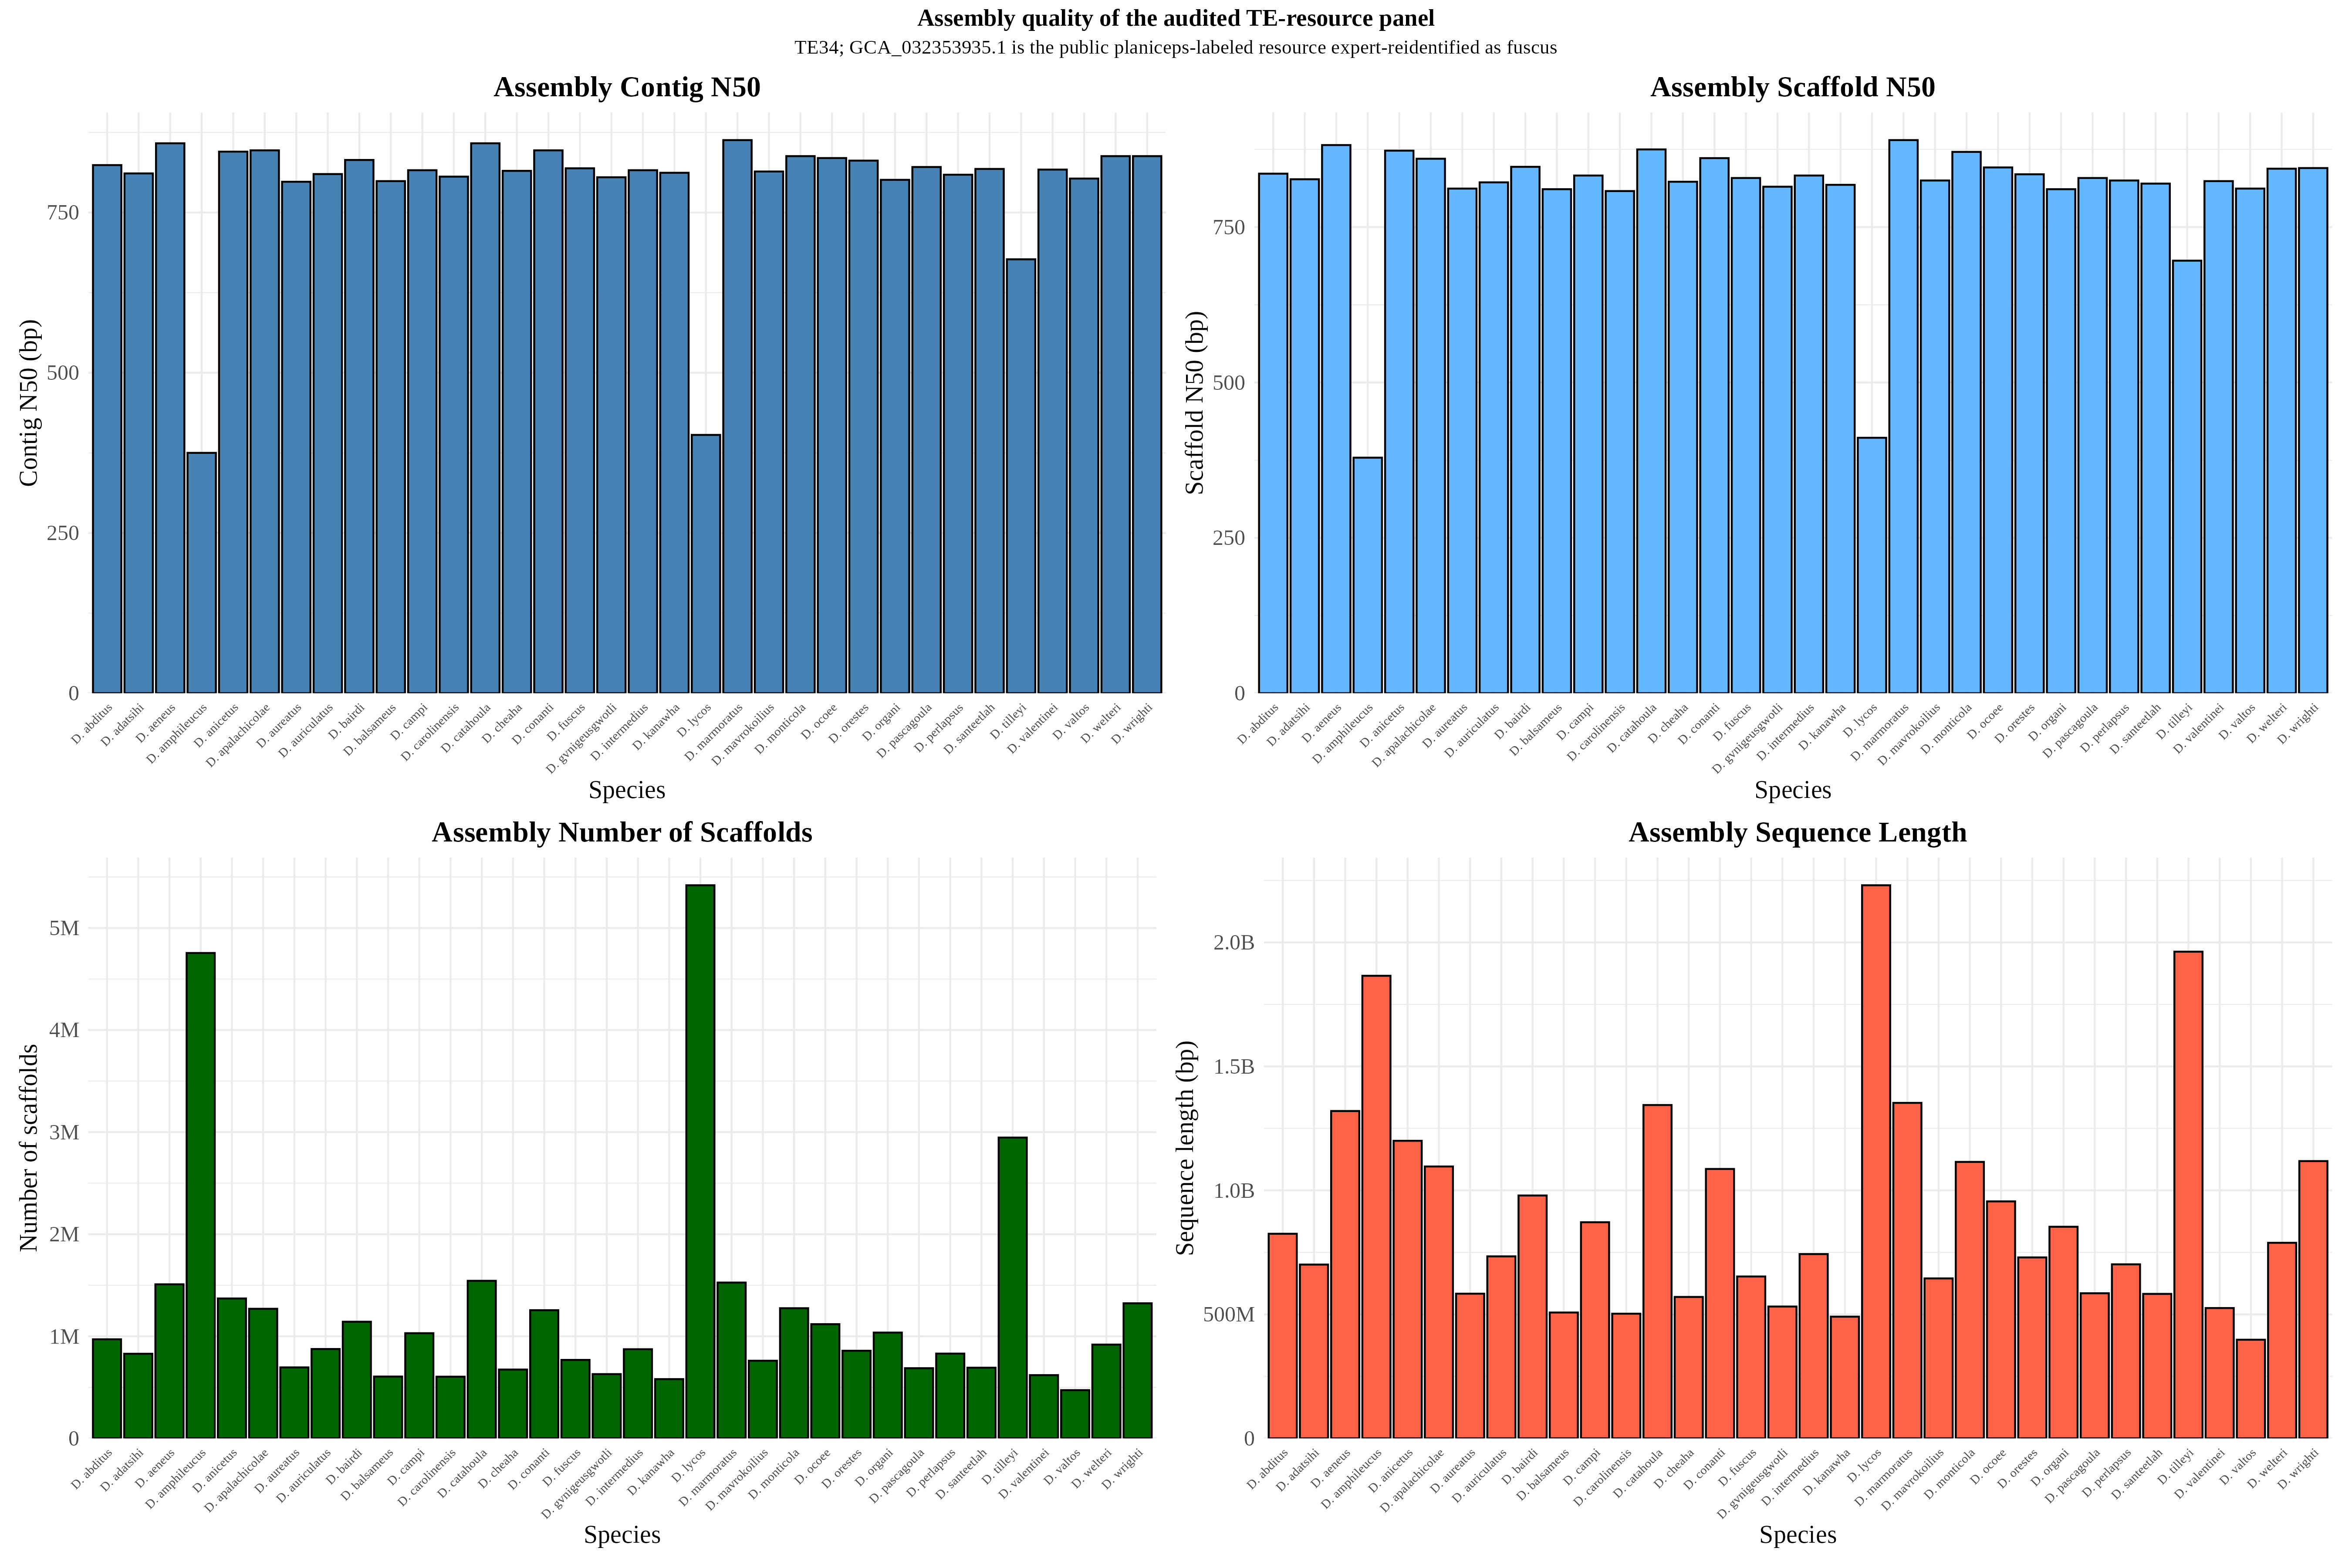

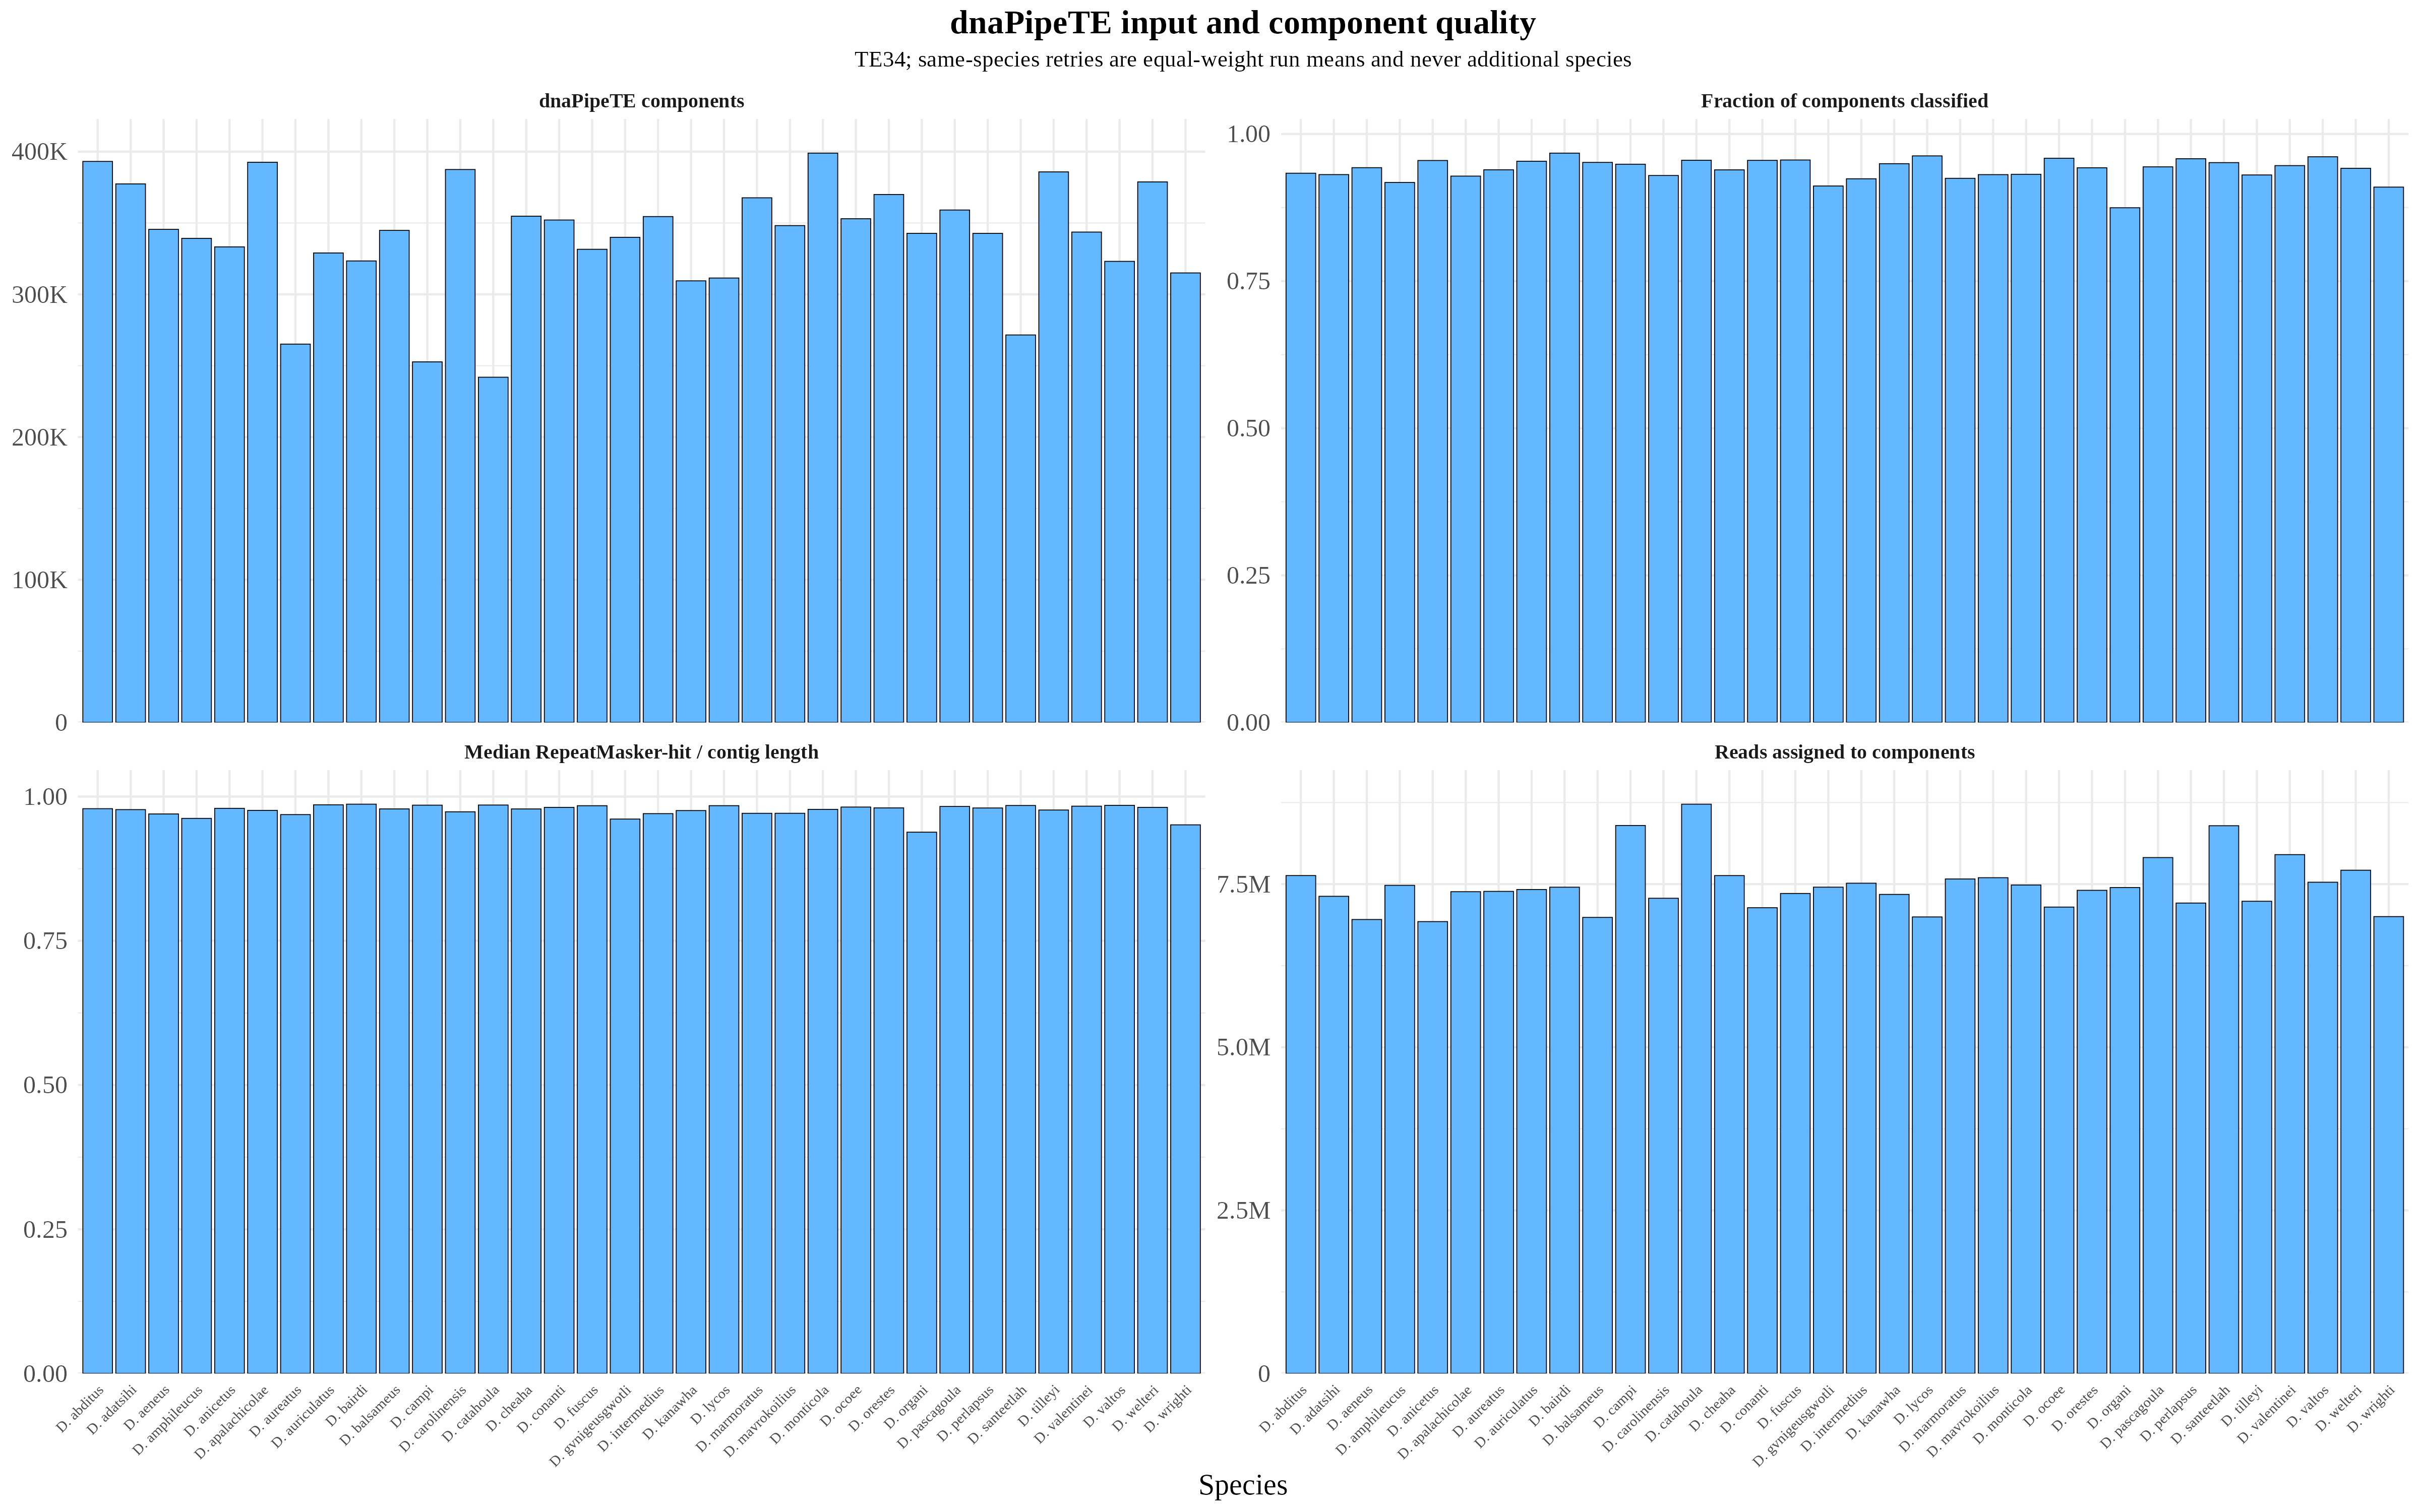

In [4]:
assembly_qc = read_csv("results/data/research_review/assembly_quality_te34_v1.csv")
run_qc = read_csv("results/data/research_review/dnapipete_quality_te34_v1.csv")
assert assembly_qc.species.nunique() == 34
assert run_qc.species.nunique() == 34
display(assembly_qc)
display(run_qc)
show_figure("results/figures/research_review/assembly_quality_te34_v1.png")
show_figure("results/figures/research_review/dnapipete_quality_te34_v1.png")

## 2. Mass accounting and mean TE composition

,species,n_dnapipete_runs,dnapipete_source_labels,run_aggregation
24,orestes,2,"[""SRX19952890"", ""SRX19952890R2""]",equal_weight_mean_of_run_level_estimates


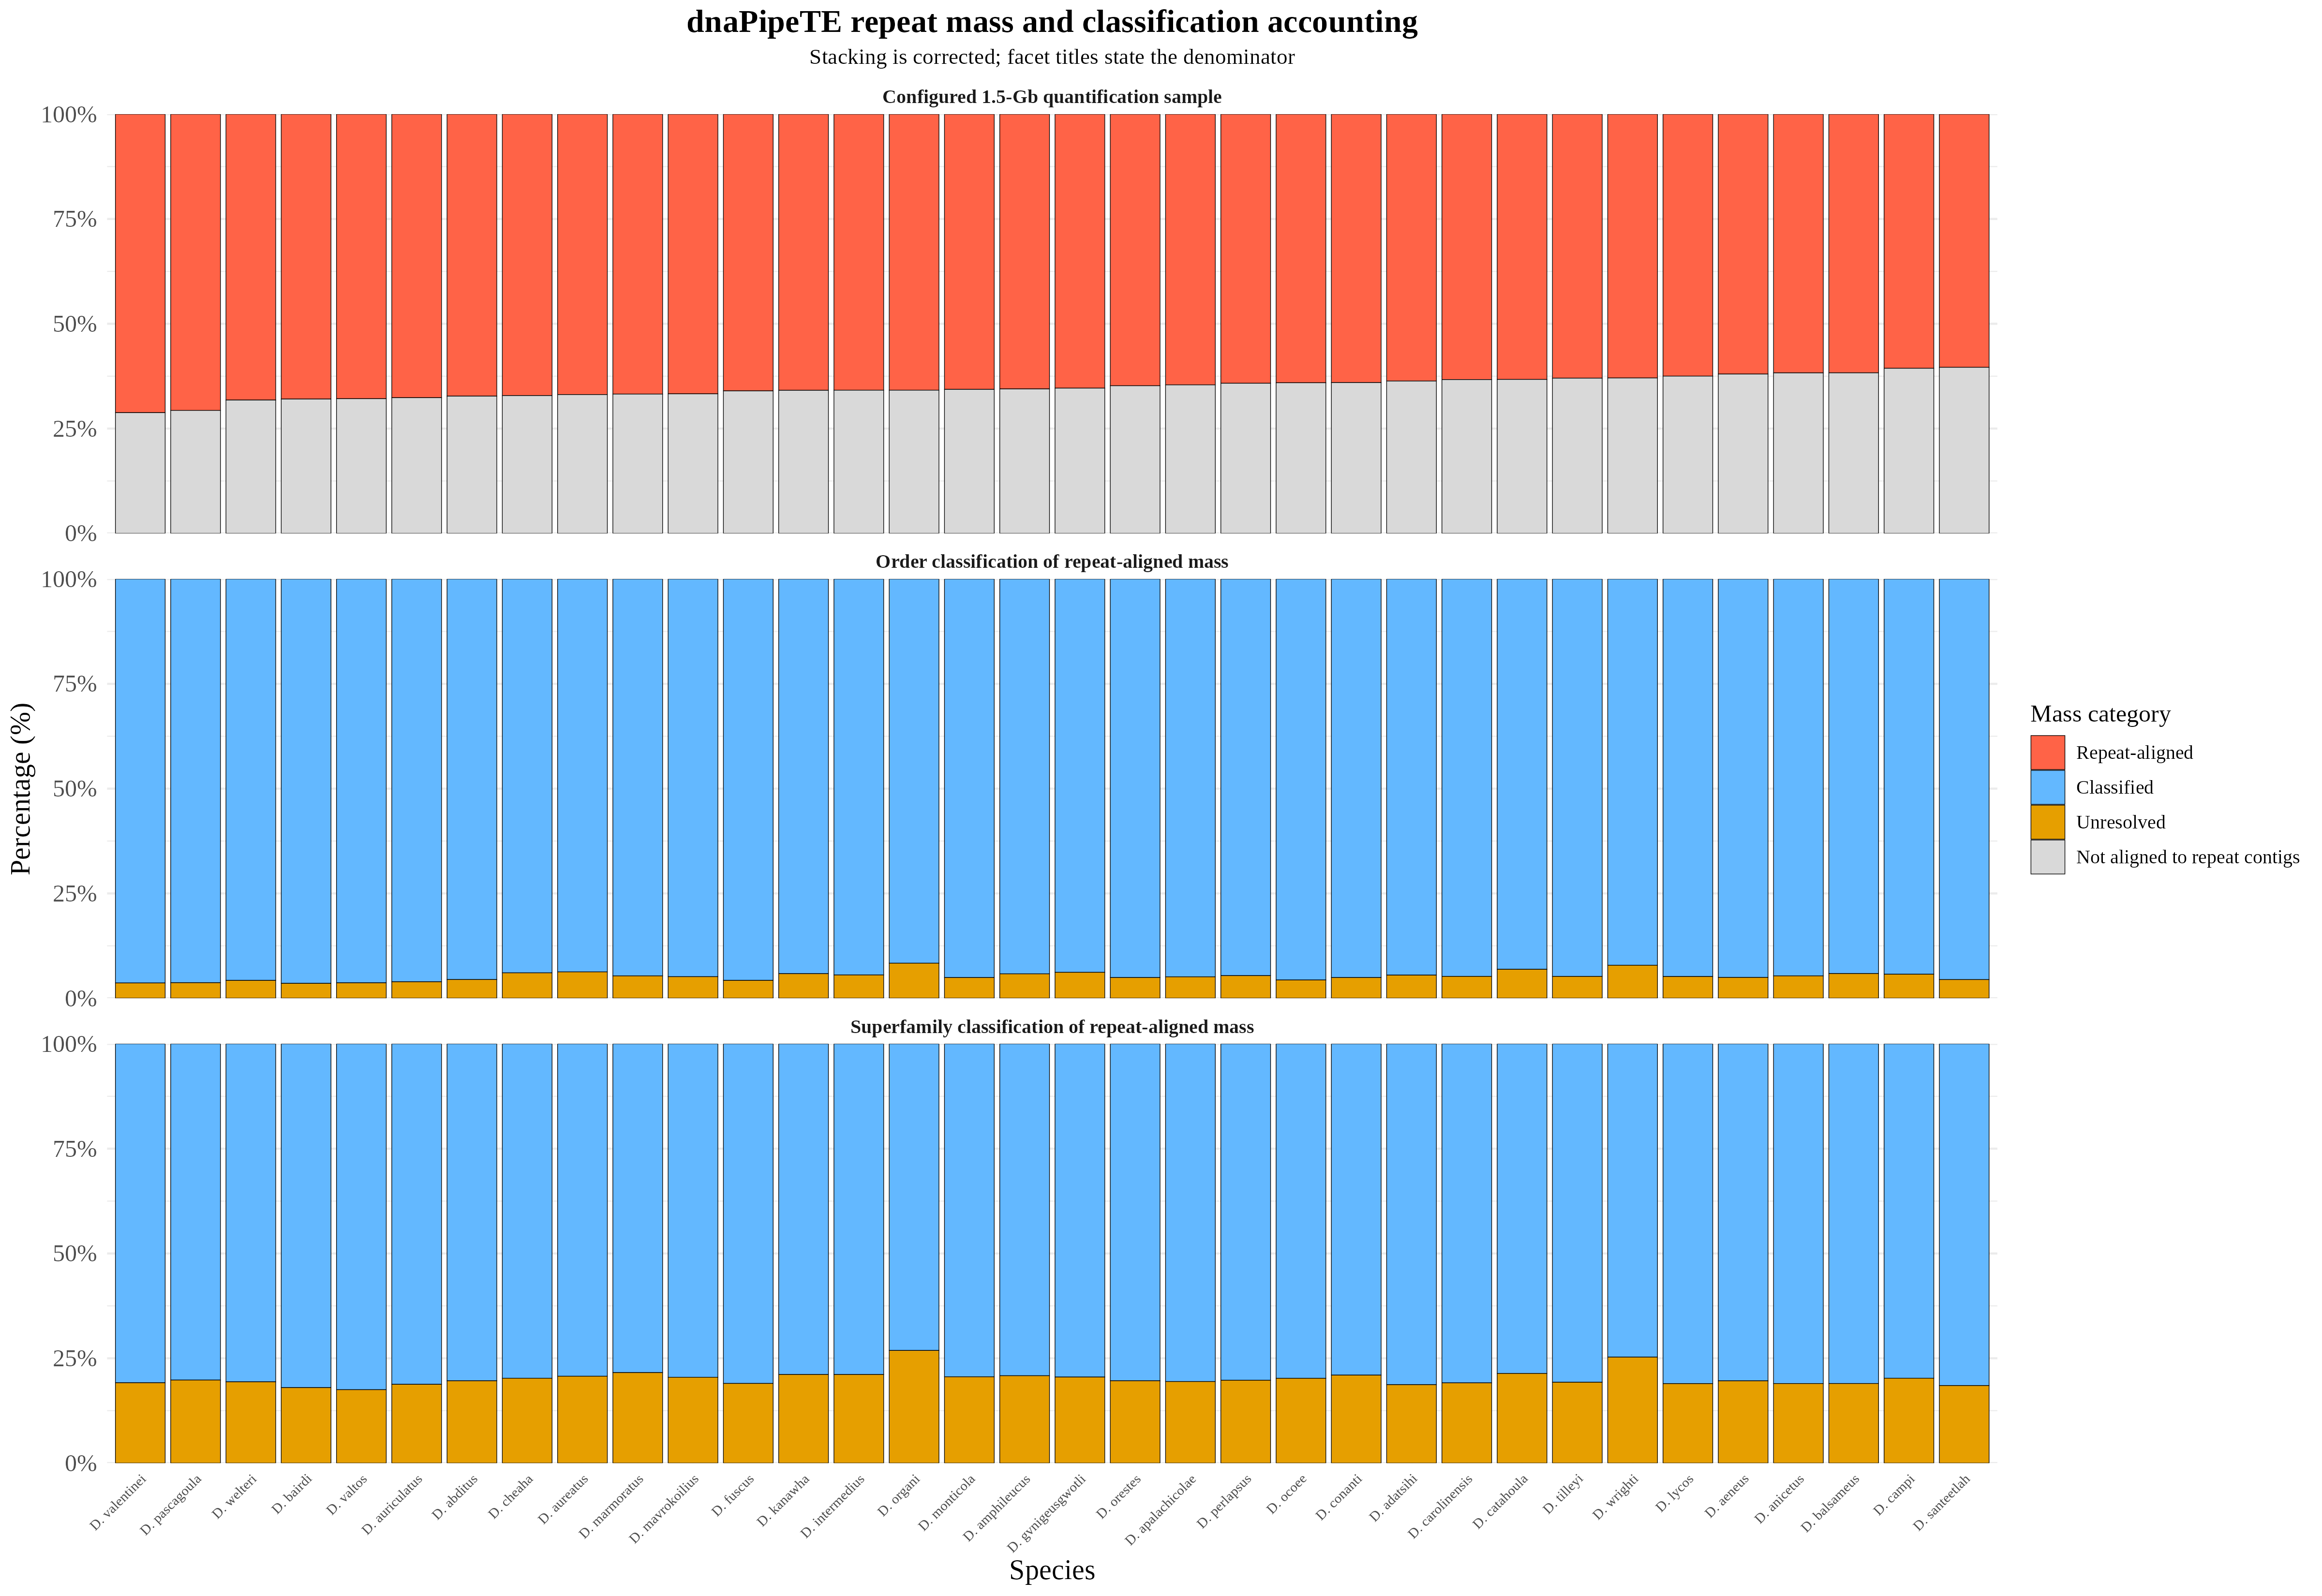

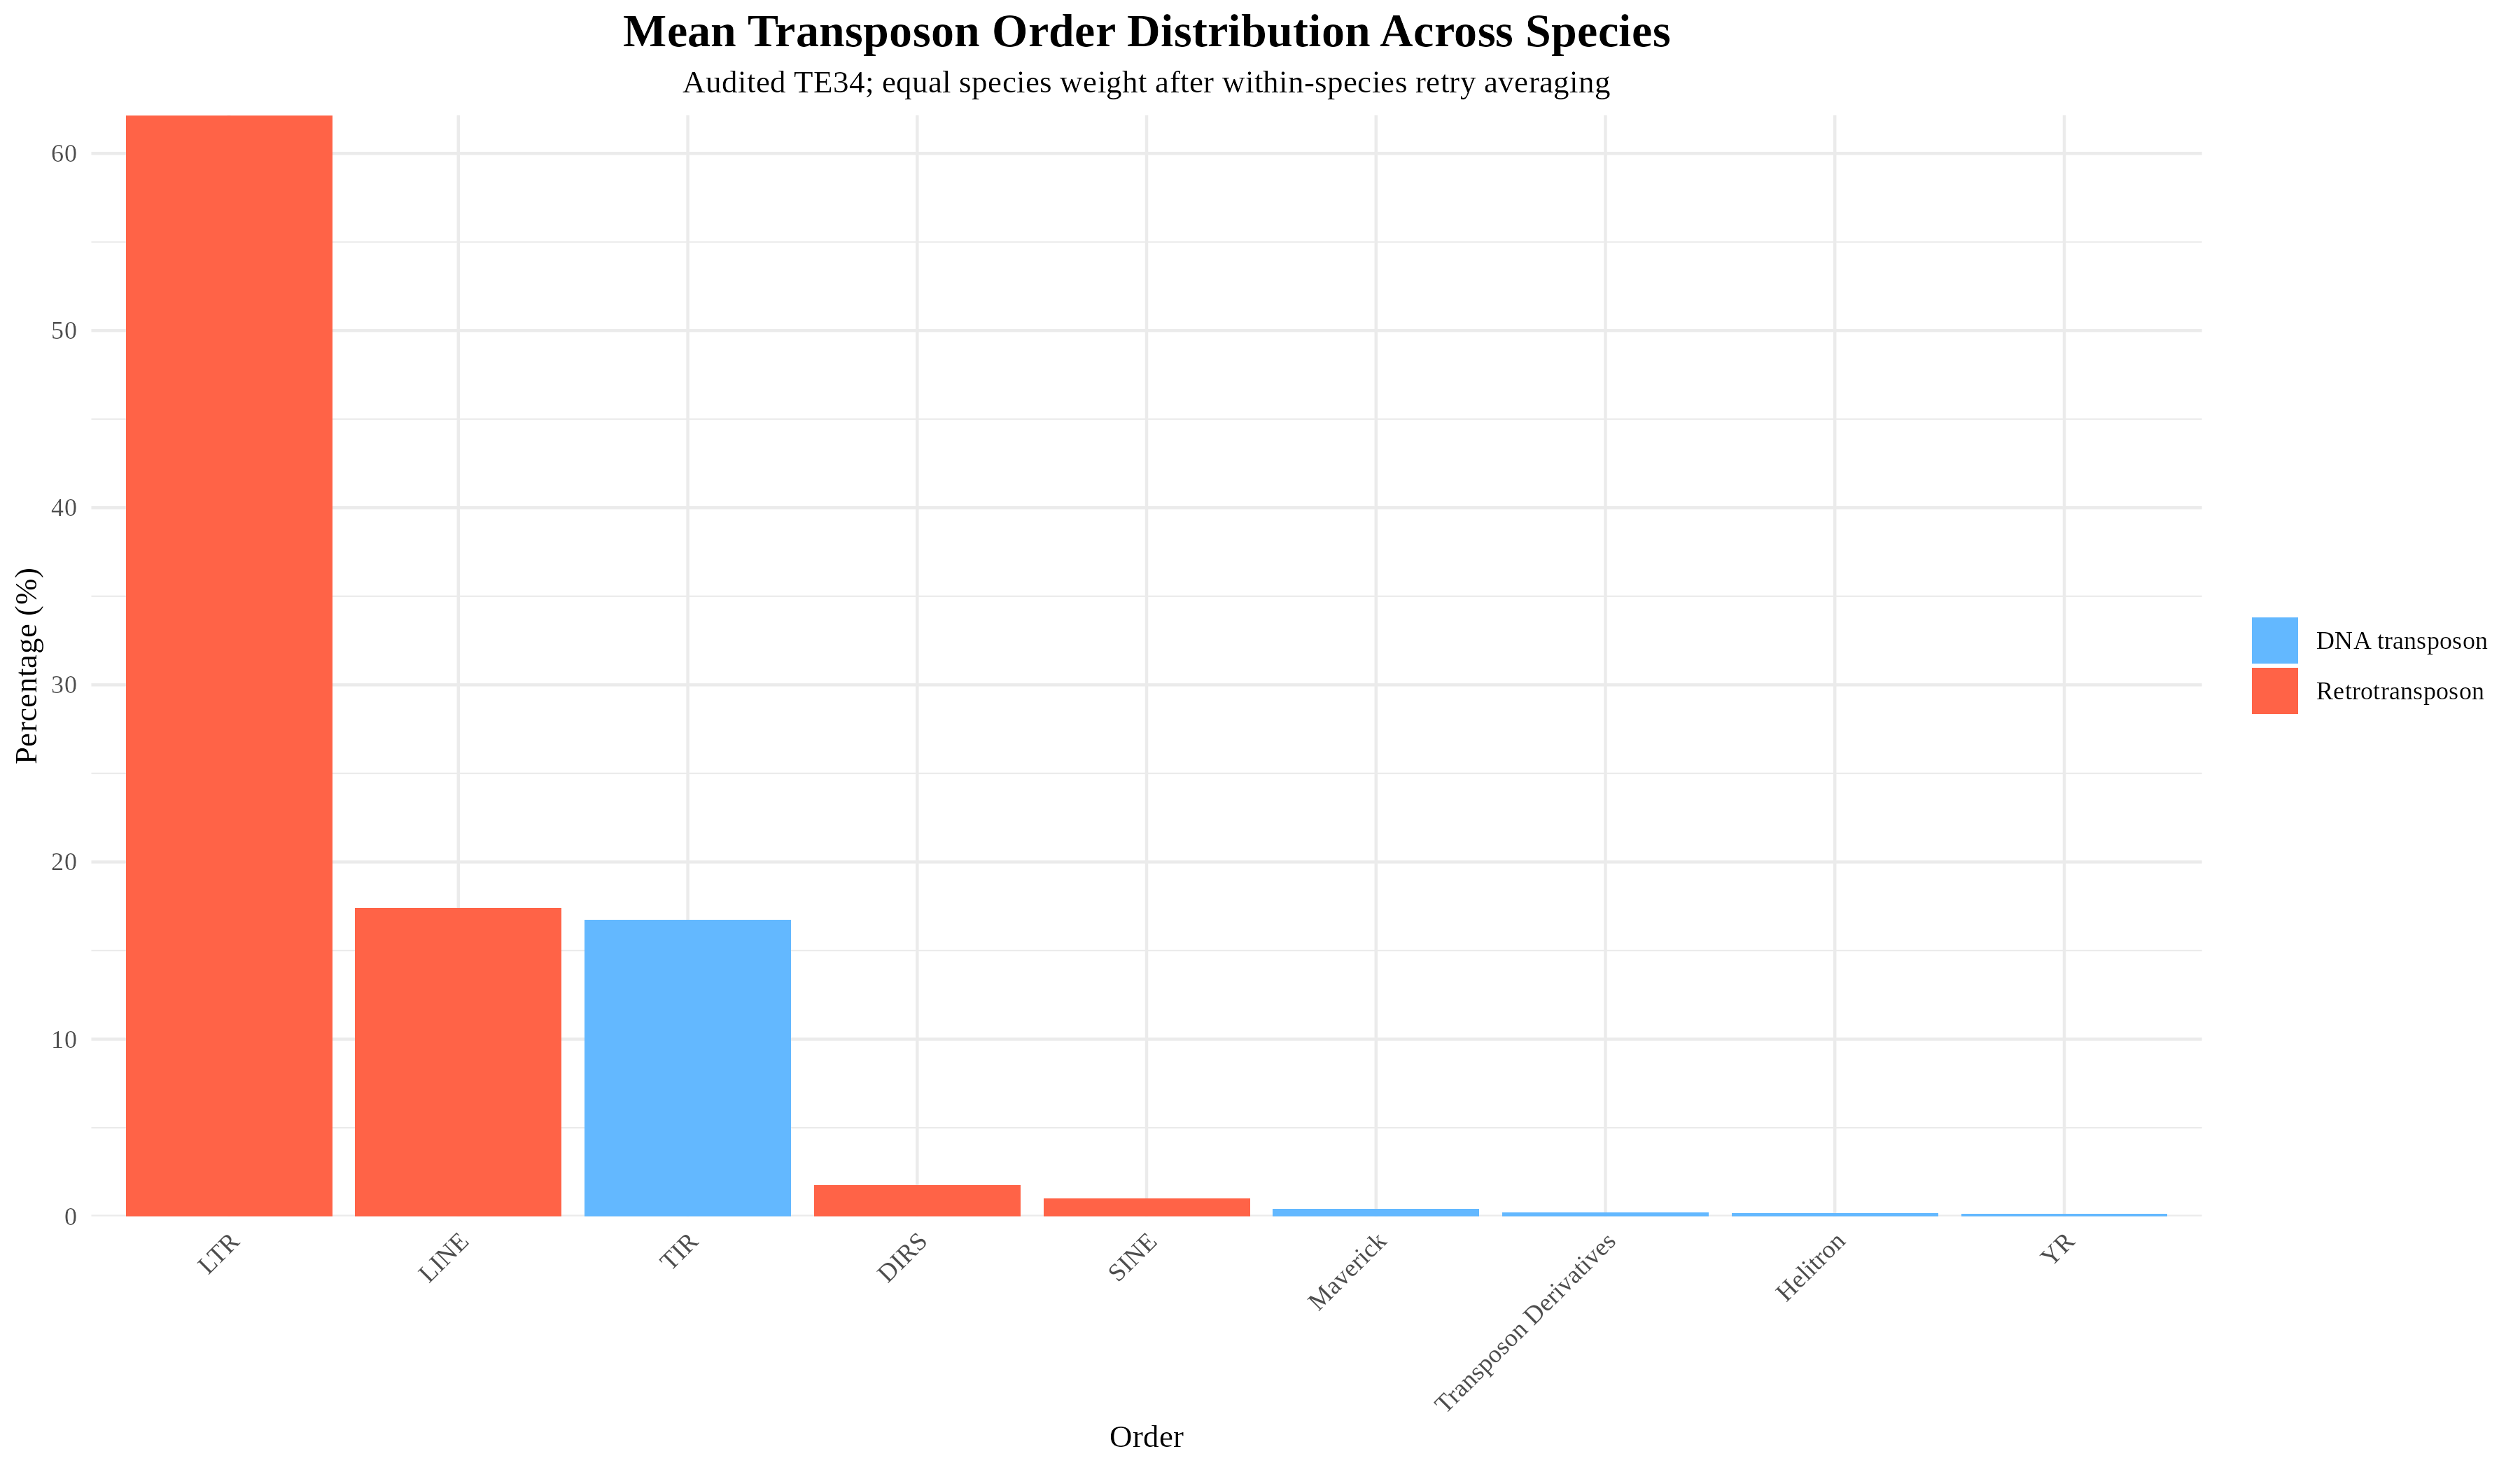

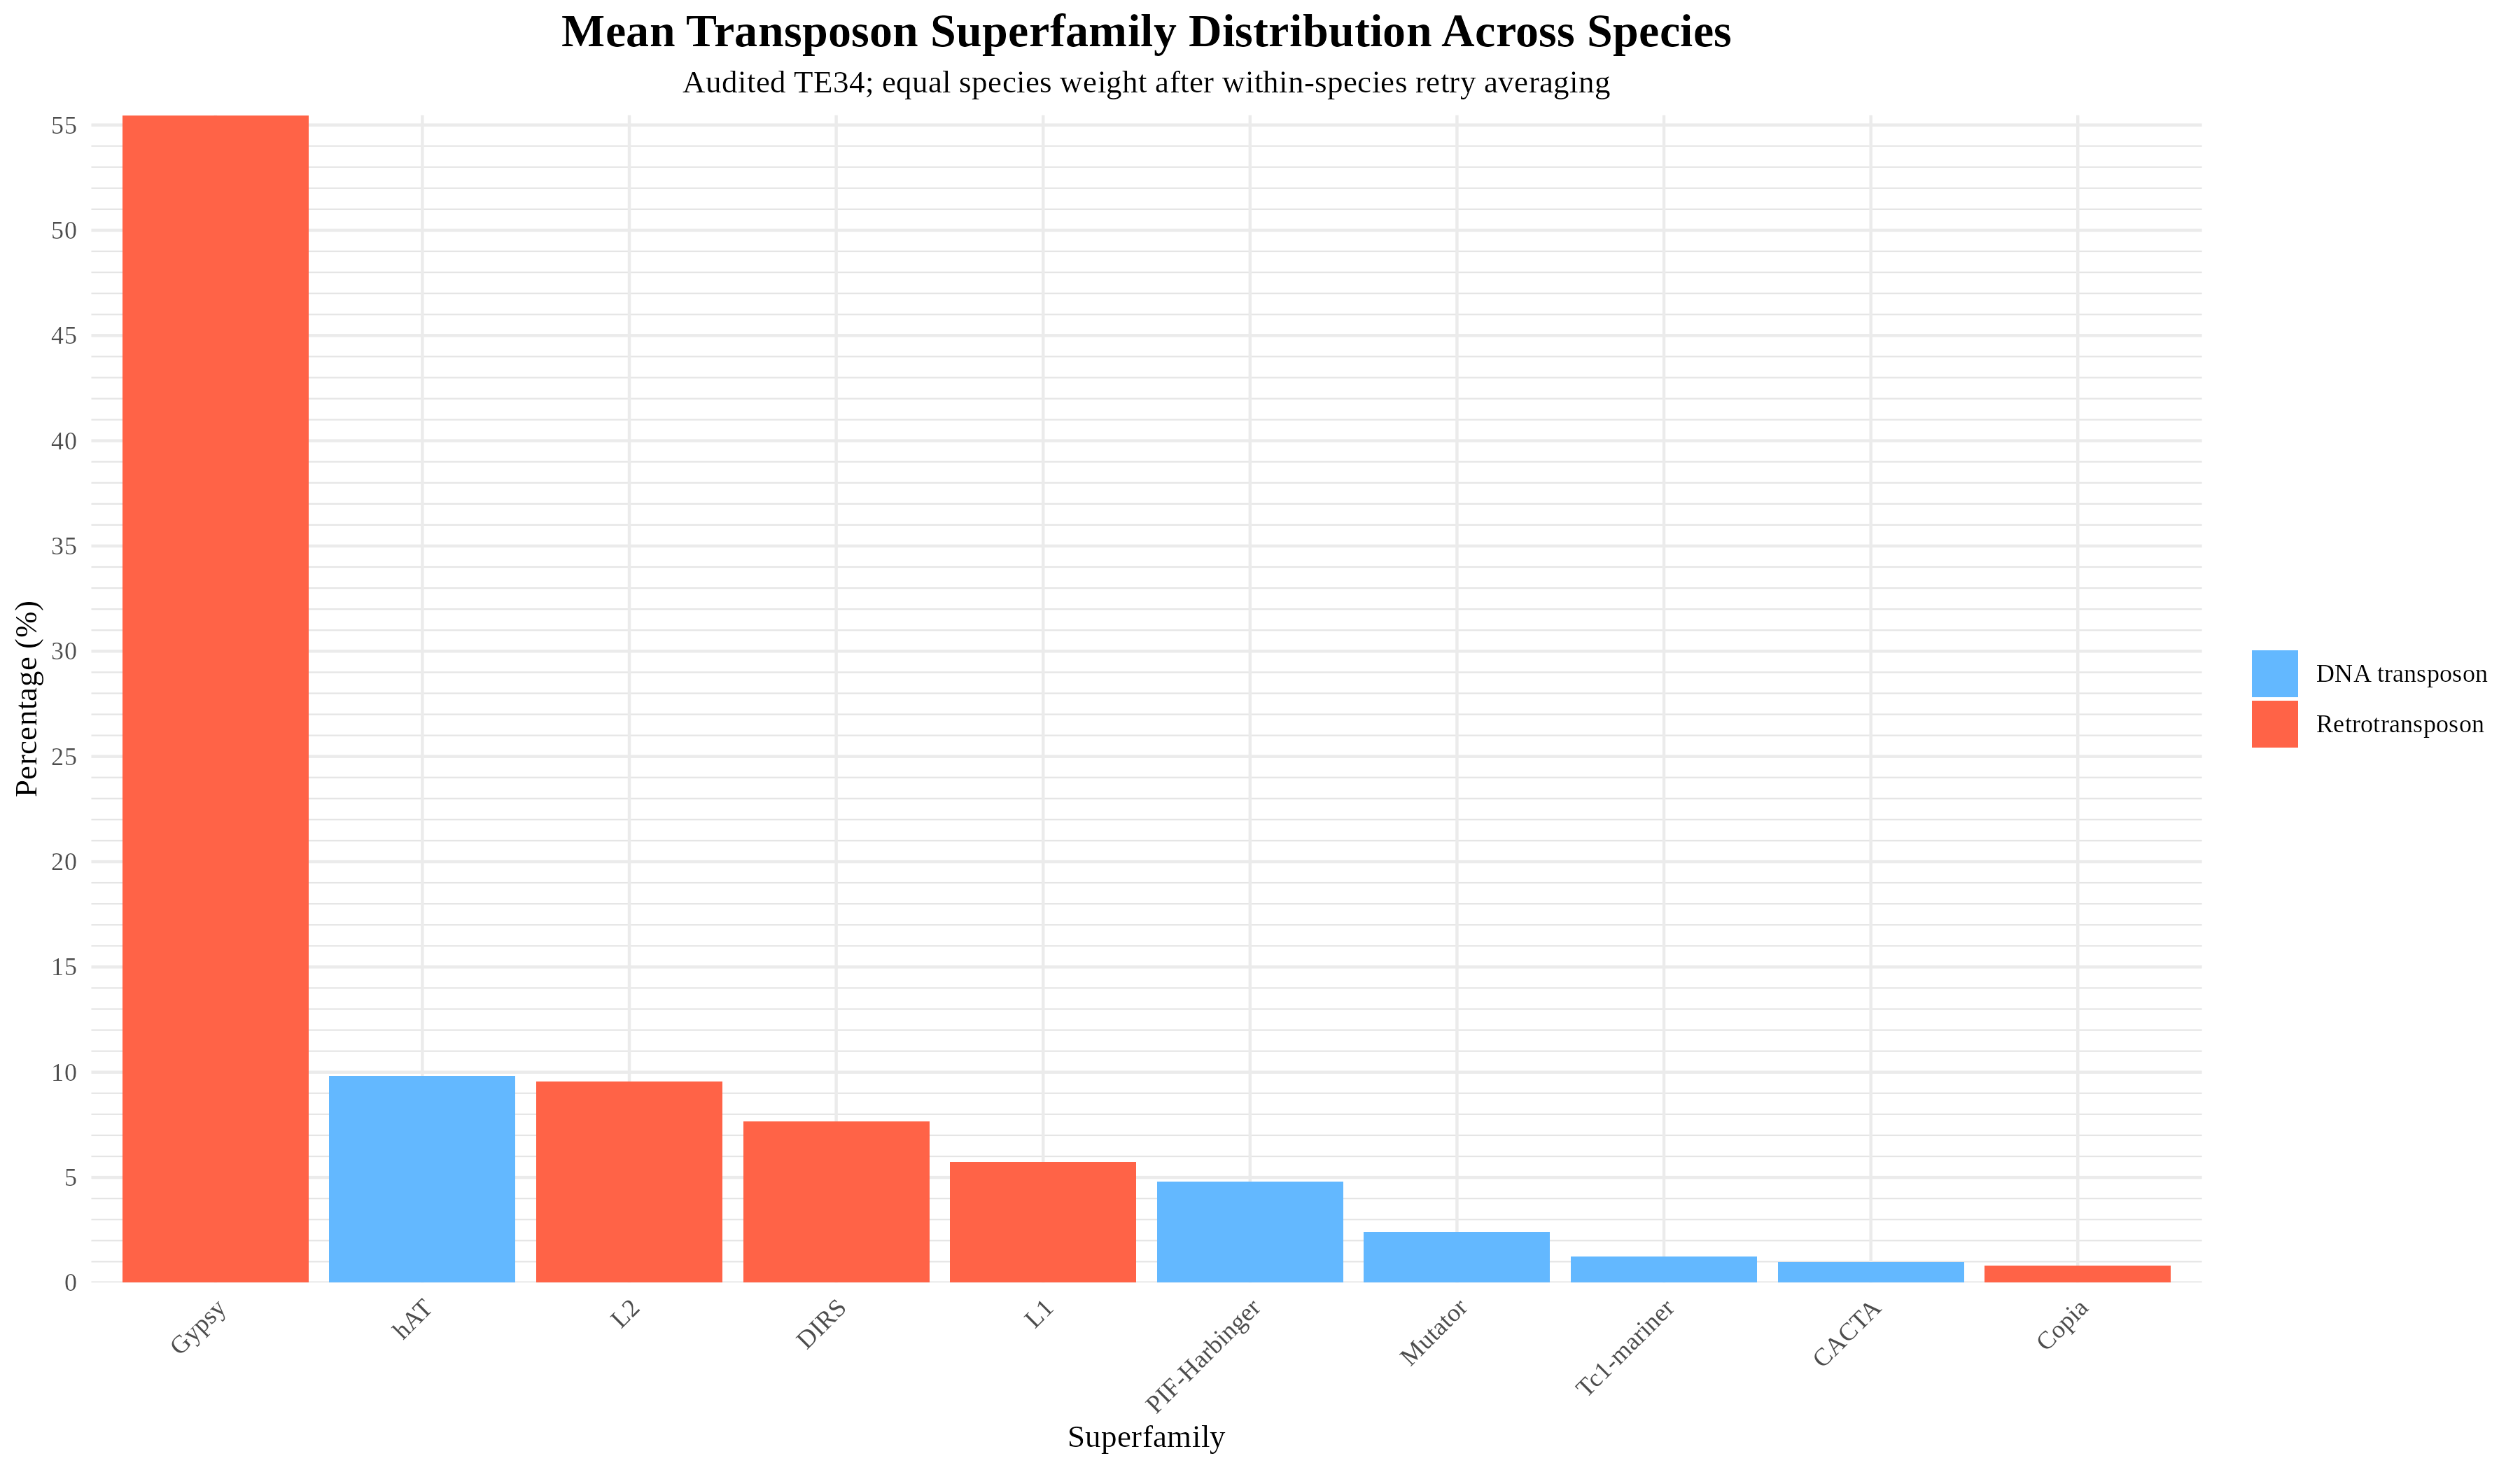

In [5]:
mass = read_csv("results/data/corrected/te34_replicate_averaged/dnapipete_mass_accounting_te34_replicate_averaged_v1.csv")
assert len(mass) == 34 and mass.species.is_unique
orestes = mass.query("species == 'orestes'")
assert len(orestes) == 1
assert "SRX19952890" in orestes.dnapipete_source_labels.iloc[0]
assert "SRX19952890R2" in orestes.dnapipete_source_labels.iloc[0]
assert orestes.n_dnapipete_runs.iloc[0] == 2
display(orestes[["species", "n_dnapipete_runs", "dnapipete_source_labels", "run_aggregation"]])
for figure in [
    "results/figures/research_review/te_mass_composition_te34_v1.png",
    "results/figures/research_review/te_mean_order_te34_v1.png",
    "results/figures/research_review/te_mean_superfamily_te34_v1.png",
]:
    show_figure(figure)

## 3. Restored cross-taxon Shannon context and genome-size scatter

This boxplot restores the literal historical `Master_shannon_diversity_vis.R`
grammar using the current audited TE34 top-10-superfamily Shannon values and the
cleaned 87-row published vertebrate composite. The metric is natural-log Shannon
entropy after renormalizing each species' ten most abundant superfamilies to one.

This is **descriptive cross-study context**, not a homogeneous comparative test:
repeat libraries, sequencing depth, genome assemblies versus skims, annotation
protocols, and group sample sizes differ. Source context: [Wang et al. 2025,
*Communications Biology*, DOI 10.1038/s42003-025-08127-3](https://doi.org/10.1038/s42003-025-08127-3)
and [Dryad DOI 10.5061/dryad.zpc866tkv](https://doi.org/10.5061/dryad.zpc866tkv).
The local 87-row historical composite is not an exact export of Wang et al.'s
84-species 2025 analysis—it contains four caecilians and ten salamanders—so it
restores prior project context only.

The historical genome-size scatter is now restored from real, variable values:
the exact 18-species intersection between audited TE34 Shannon and the current
21-species genome-estimate table. The original `GS = 16` placeholder is gone.
Current Desmognathus x values are **fuscus-anchored image-IOD genome-size
estimates**, converted with `1 pg = 0.978 Gb` and shown with their conditional
95% bootstrap intervals. They are estimates, **not direct C-values**, and the
16.36-pg *D. fuscus* anchor does not by itself validate between-slide absolute
calibration. The ten historical salamander points remain descriptive context;
no pooled 28-point inferential test is reported because assay and TE-annotation
workflows differ. Pearson, Spearman, OLS, and Brownian PGLS summaries are
reported only for the 18 current Desmognathus rows and remain exploratory.
Those tests use species point estimates and the single frozen processed time tree;
they do not propagate genome-estimate, Shannon-estimate, or tree uncertainty.

,group,source,n_species
0,Birds,Historical published-vertebrate composite used by prior project code,14
1,Bony Fishes,Historical published-vertebrate composite used by prior project code,13
2,Caecilian,Historical published-vertebrate composite used by prior project code,4
3,Cartilaginous fish,Historical published-vertebrate composite used by prior project code,3
4,Desmognathus,Current audited retry-averaged TE34 superfamily composition,34
5,Frogs,Historical published-vertebrate composite used by prior project code,10
6,Lobe-finned fish,Historical published-vertebrate composite used by prior project code,3
7,Mammals,Historical published-vertebrate composite used by prior project code,14
8,Non-avian reptiles,Historical published-vertebrate composite used by prior project code,16
9,Salamanders,Historical published-vertebrate composite used by prior project code,10


,artifact_id,local_source_path,local_source_sha256,local_source_rows,cleaning,context_reference,published_data_repository,published_metric_contract,source_scope_disclosure,article_url
0,wang_ji_2025_shannon_context_v1,/home/jake/Projects/Desmognathus_Results/wang_ji_shannondiversity.csv,4ec3237a6ecd361c7e040b11dccfc9e2ac635cf10b739a4e95920015edccbb0e,87,Whitespace-only header/value cleanup and explicit typed column names; published values unchanged.,"Wang et al. 2025, Communications Biology, DOI 10.1038/s42003-025-08127-3",Dryad DOI 10.5061/dryad.zpc866tkv,Natural-log Shannon entropy over the top 10 most abundant TE superfamilies; TE-superfamily sequence proportions are ...,This 87-row local historical composite is not an exact export of the paper's 84-species comparative analysis; it inc...,https://doi.org/10.1038/s42003-025-08127-3


,species,top10_total,shannon_top10
0,abditus,1.0,1.479938
1,adatsihi,1.0,1.524586
2,aeneus,1.0,1.556026
3,amphileucus,1.0,1.577885
4,anicetus,1.0,1.562456
5,apalachicolae,1.0,1.523237
6,aureatus,1.0,1.481331
7,auriculatus,1.0,1.465478
8,bairdi,1.0,1.420044
9,balsameus,1.0,1.556652


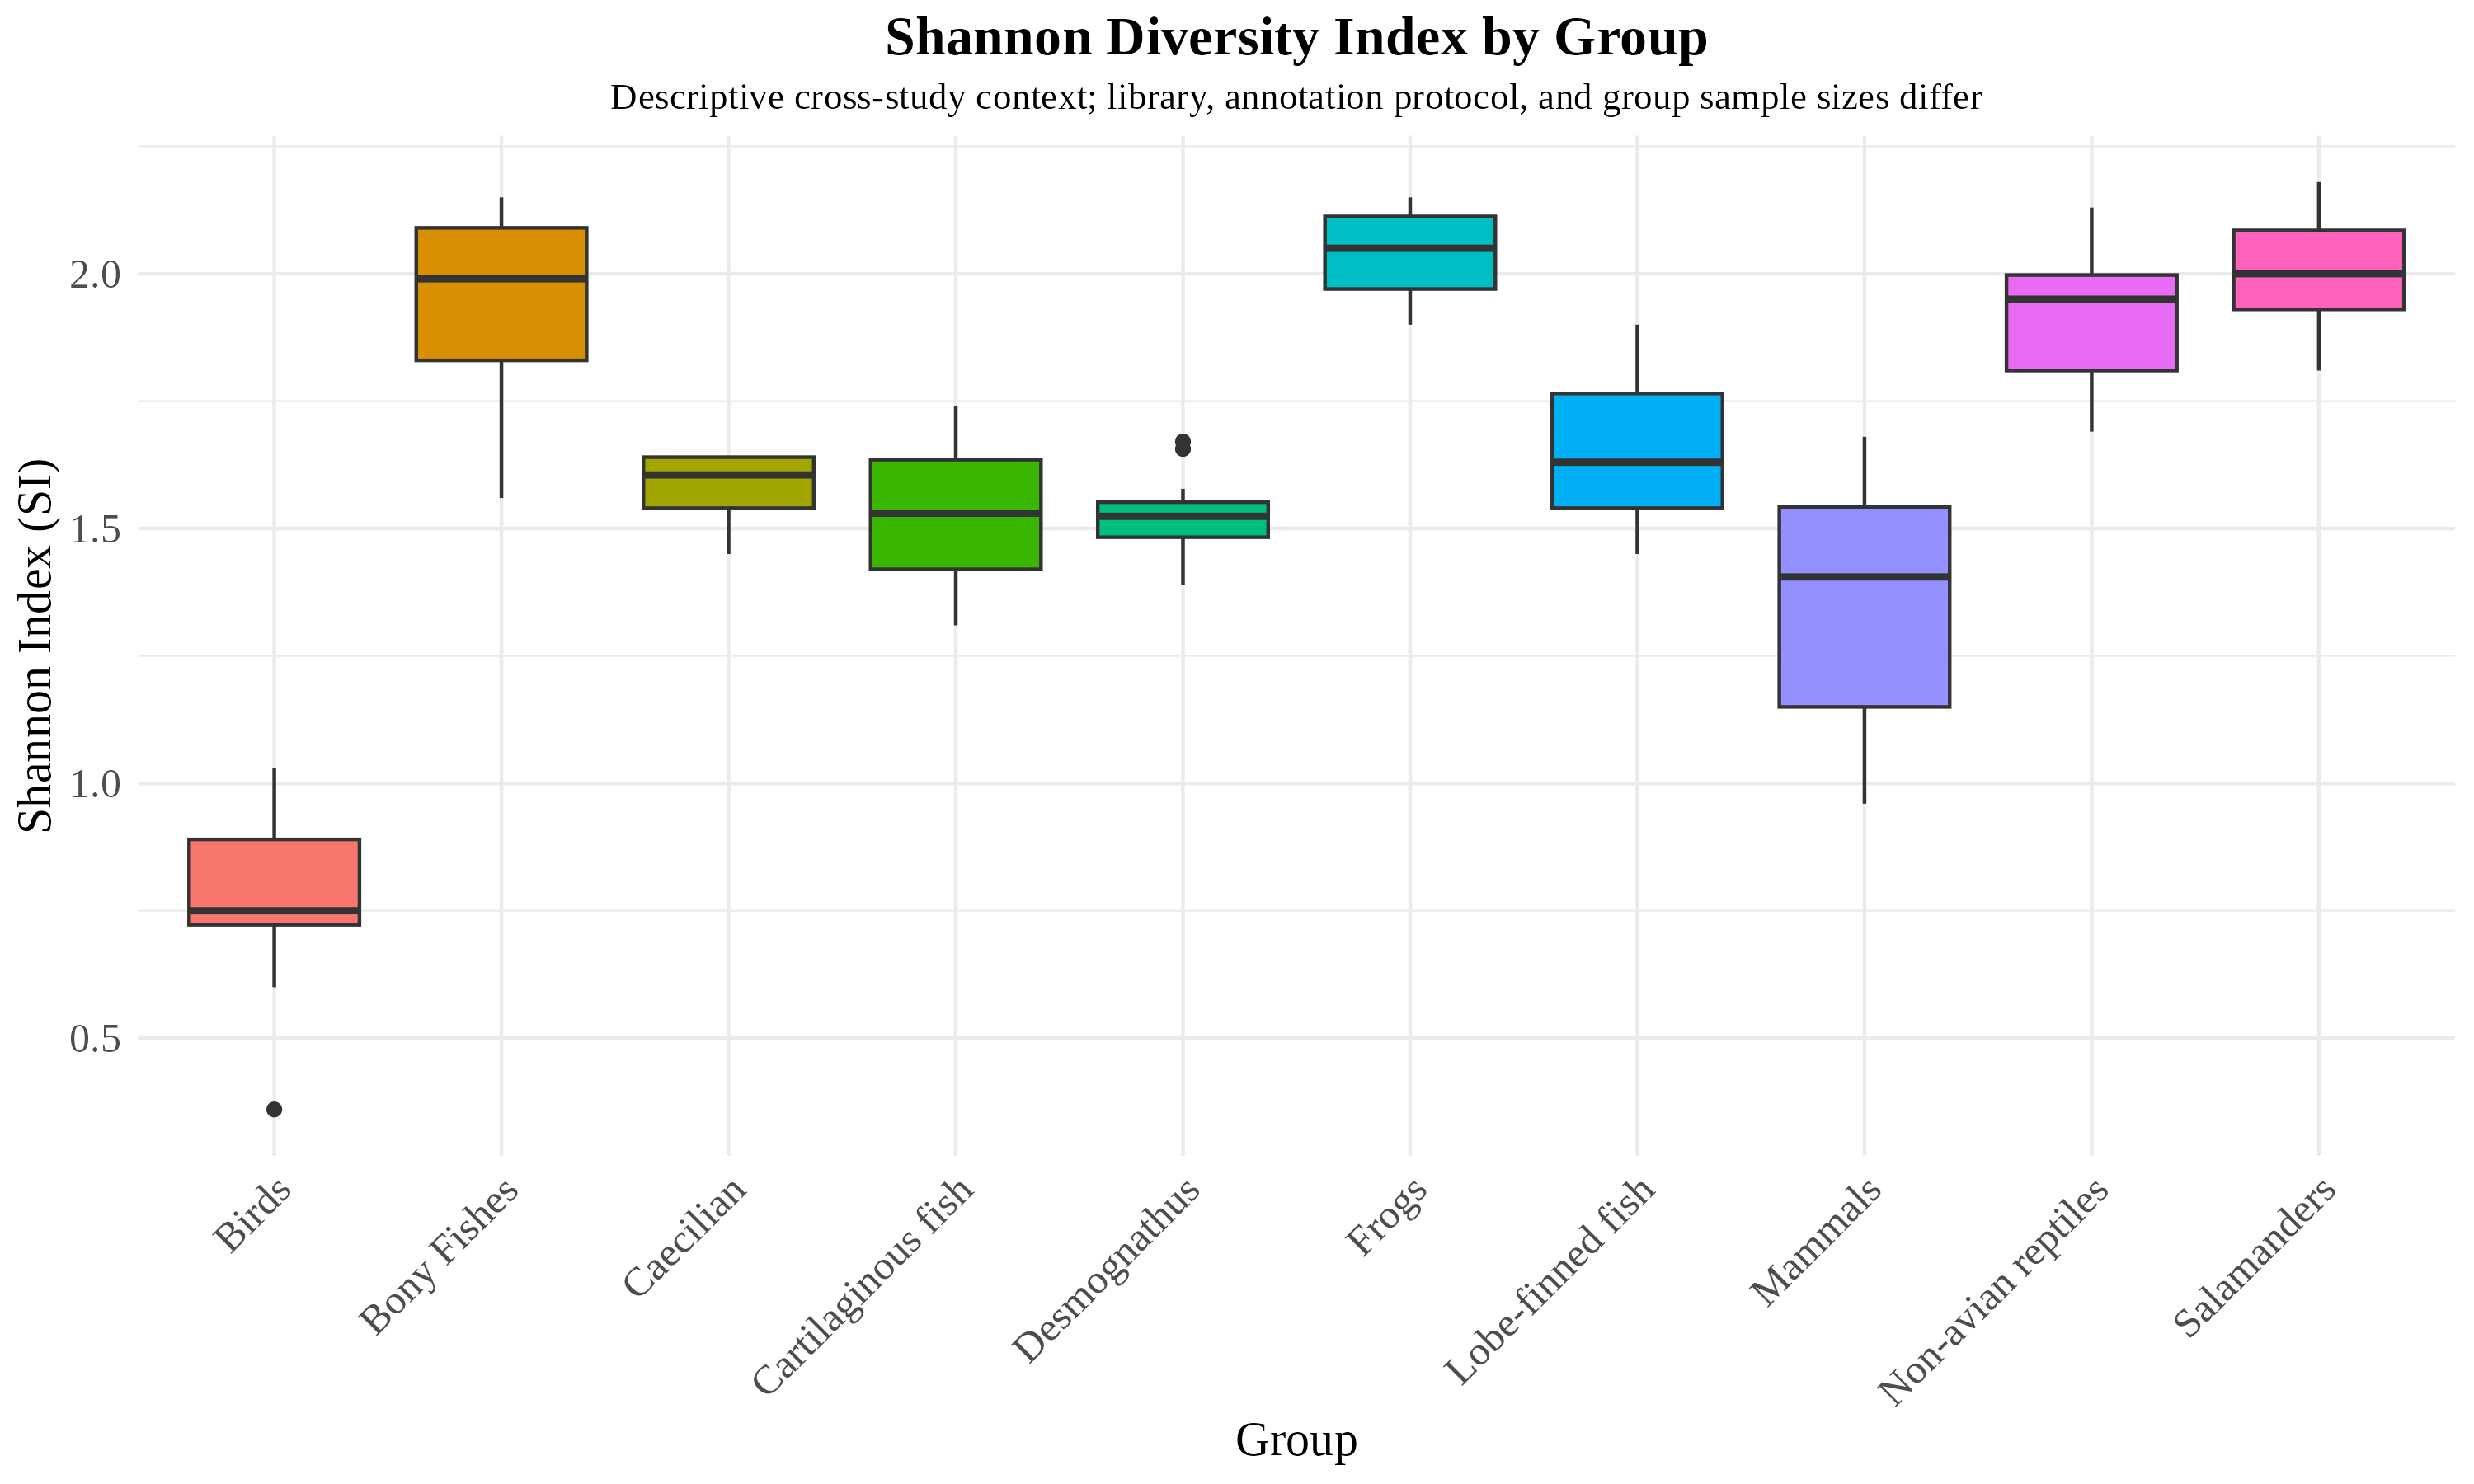

,species,genome_size_gb,genome_size_ci_low_gb,genome_size_ci_high_gb,shannon_top10_superfamilies,genome_support_tier,genome_support_warnings
10,Desmognathus amphileucus,13.977868,13.486864,14.699151,1.577885,limited,low_image_count; low_specimen_count
11,Desmognathus anicetus,12.782358,12.303329,13.460884,1.562456,limited,low_image_count; low_specimen_count
12,Desmognathus apalachicolae,12.407990,11.683624,13.259301,1.523237,low,low_pair_count; low_image_count; low_specimen_count; auto_dominant
13,Desmognathus auriculatus,14.208347,13.565645,14.974578,1.465478,limited,low_image_count; low_specimen_count
14,Desmognathus bairdi,15.927338,15.349867,16.873460,1.420044,limited,low_image_count; low_specimen_count
15,Desmognathus campi,12.512702,11.482956,13.404649,1.528180,medium,NaN
16,Desmognathus fuscus,16.000080,15.194492,16.916520,1.465540,limited,low_pair_count; low_image_count; low_specimen_count
17,Desmognathus gvnigeusgwotli,13.407797,12.698645,14.231396,1.552237,limited,low_image_count; low_specimen_count
18,Desmognathus intermedius,15.927020,14.442991,17.608201,1.532367,medium,auto_dominant
19,Desmognathus kanawha,12.958990,12.458838,13.957648,1.490874,limited,low_image_count; low_specimen_count; auto_dominant


,canonical_species,shannon_top10_superfamilies,primary_genome_pg,primary_support_tier,result_status,has_te_shannon,has_genome_size_estimate,included_in_scatter,exclusion_reason
0,abditus,1.479938,NaN,NaN,NaN,True,False,False,no_current_fuscus_anchored_genome_size_estimate
1,adatsihi,1.524586,NaN,NaN,NaN,True,False,False,no_current_fuscus_anchored_genome_size_estimate
2,aeneus,1.556026,NaN,NaN,NaN,True,False,False,no_current_fuscus_anchored_genome_size_estimate
3,amphileucus,1.577885,14.292299,limited,sensitivity_limited,True,True,True,included_exact_te_genome_overlap
4,anicetus,1.562456,13.069896,limited,sensitivity_limited,True,True,True,included_exact_te_genome_overlap
5,apalachicolae,1.523237,12.687106,low,sensitivity_limited,True,True,True,included_exact_te_genome_overlap
6,aureatus,1.481331,NaN,NaN,NaN,True,False,False,no_current_fuscus_anchored_genome_size_estimate
7,auriculatus,1.465478,14.527962,limited,sensitivity_limited,True,True,True,included_exact_te_genome_overlap
8,bairdi,1.420044,16.285622,limited,sensitivity_limited,True,True,True,included_exact_te_genome_overlap
9,balsameus,1.556652,NaN,NaN,NaN,True,False,False,no_current_fuscus_anchored_genome_size_estimate


Genome-size estimate / Shannon association statistics
Scope: exact 18-species overlap between audited TE34 Shannon and current CellProfiler genome-size estimates
Genome x variable: fuscus-anchored image-IOD-derived estimate converted from pg to Gb with 1 pg = 0.978 Gb
Measurement boundary: these are not direct C-values; uncertainty is conditional on the archived image workflow and D. fuscus = 16.36 pg anchor
Shannon y variable: natural-log entropy of the 10 most abundant TE superfamilies, renormalized within top 10
The 10 historical salamander context points are plotted but excluded from all tests below because study and annotation pipelines differ.
Association tests use species point estimates; they do not propagate genome-estimate or Shannon-estimate uncertainty.
Brownian PGLS uses the single frozen processed TE34 time tree; tree uncertainty is not propagated in this descriptive runner.

Desmognathus Pearson correlation (non-phylogenetic)

	Pearson's product-moment correlation

data:

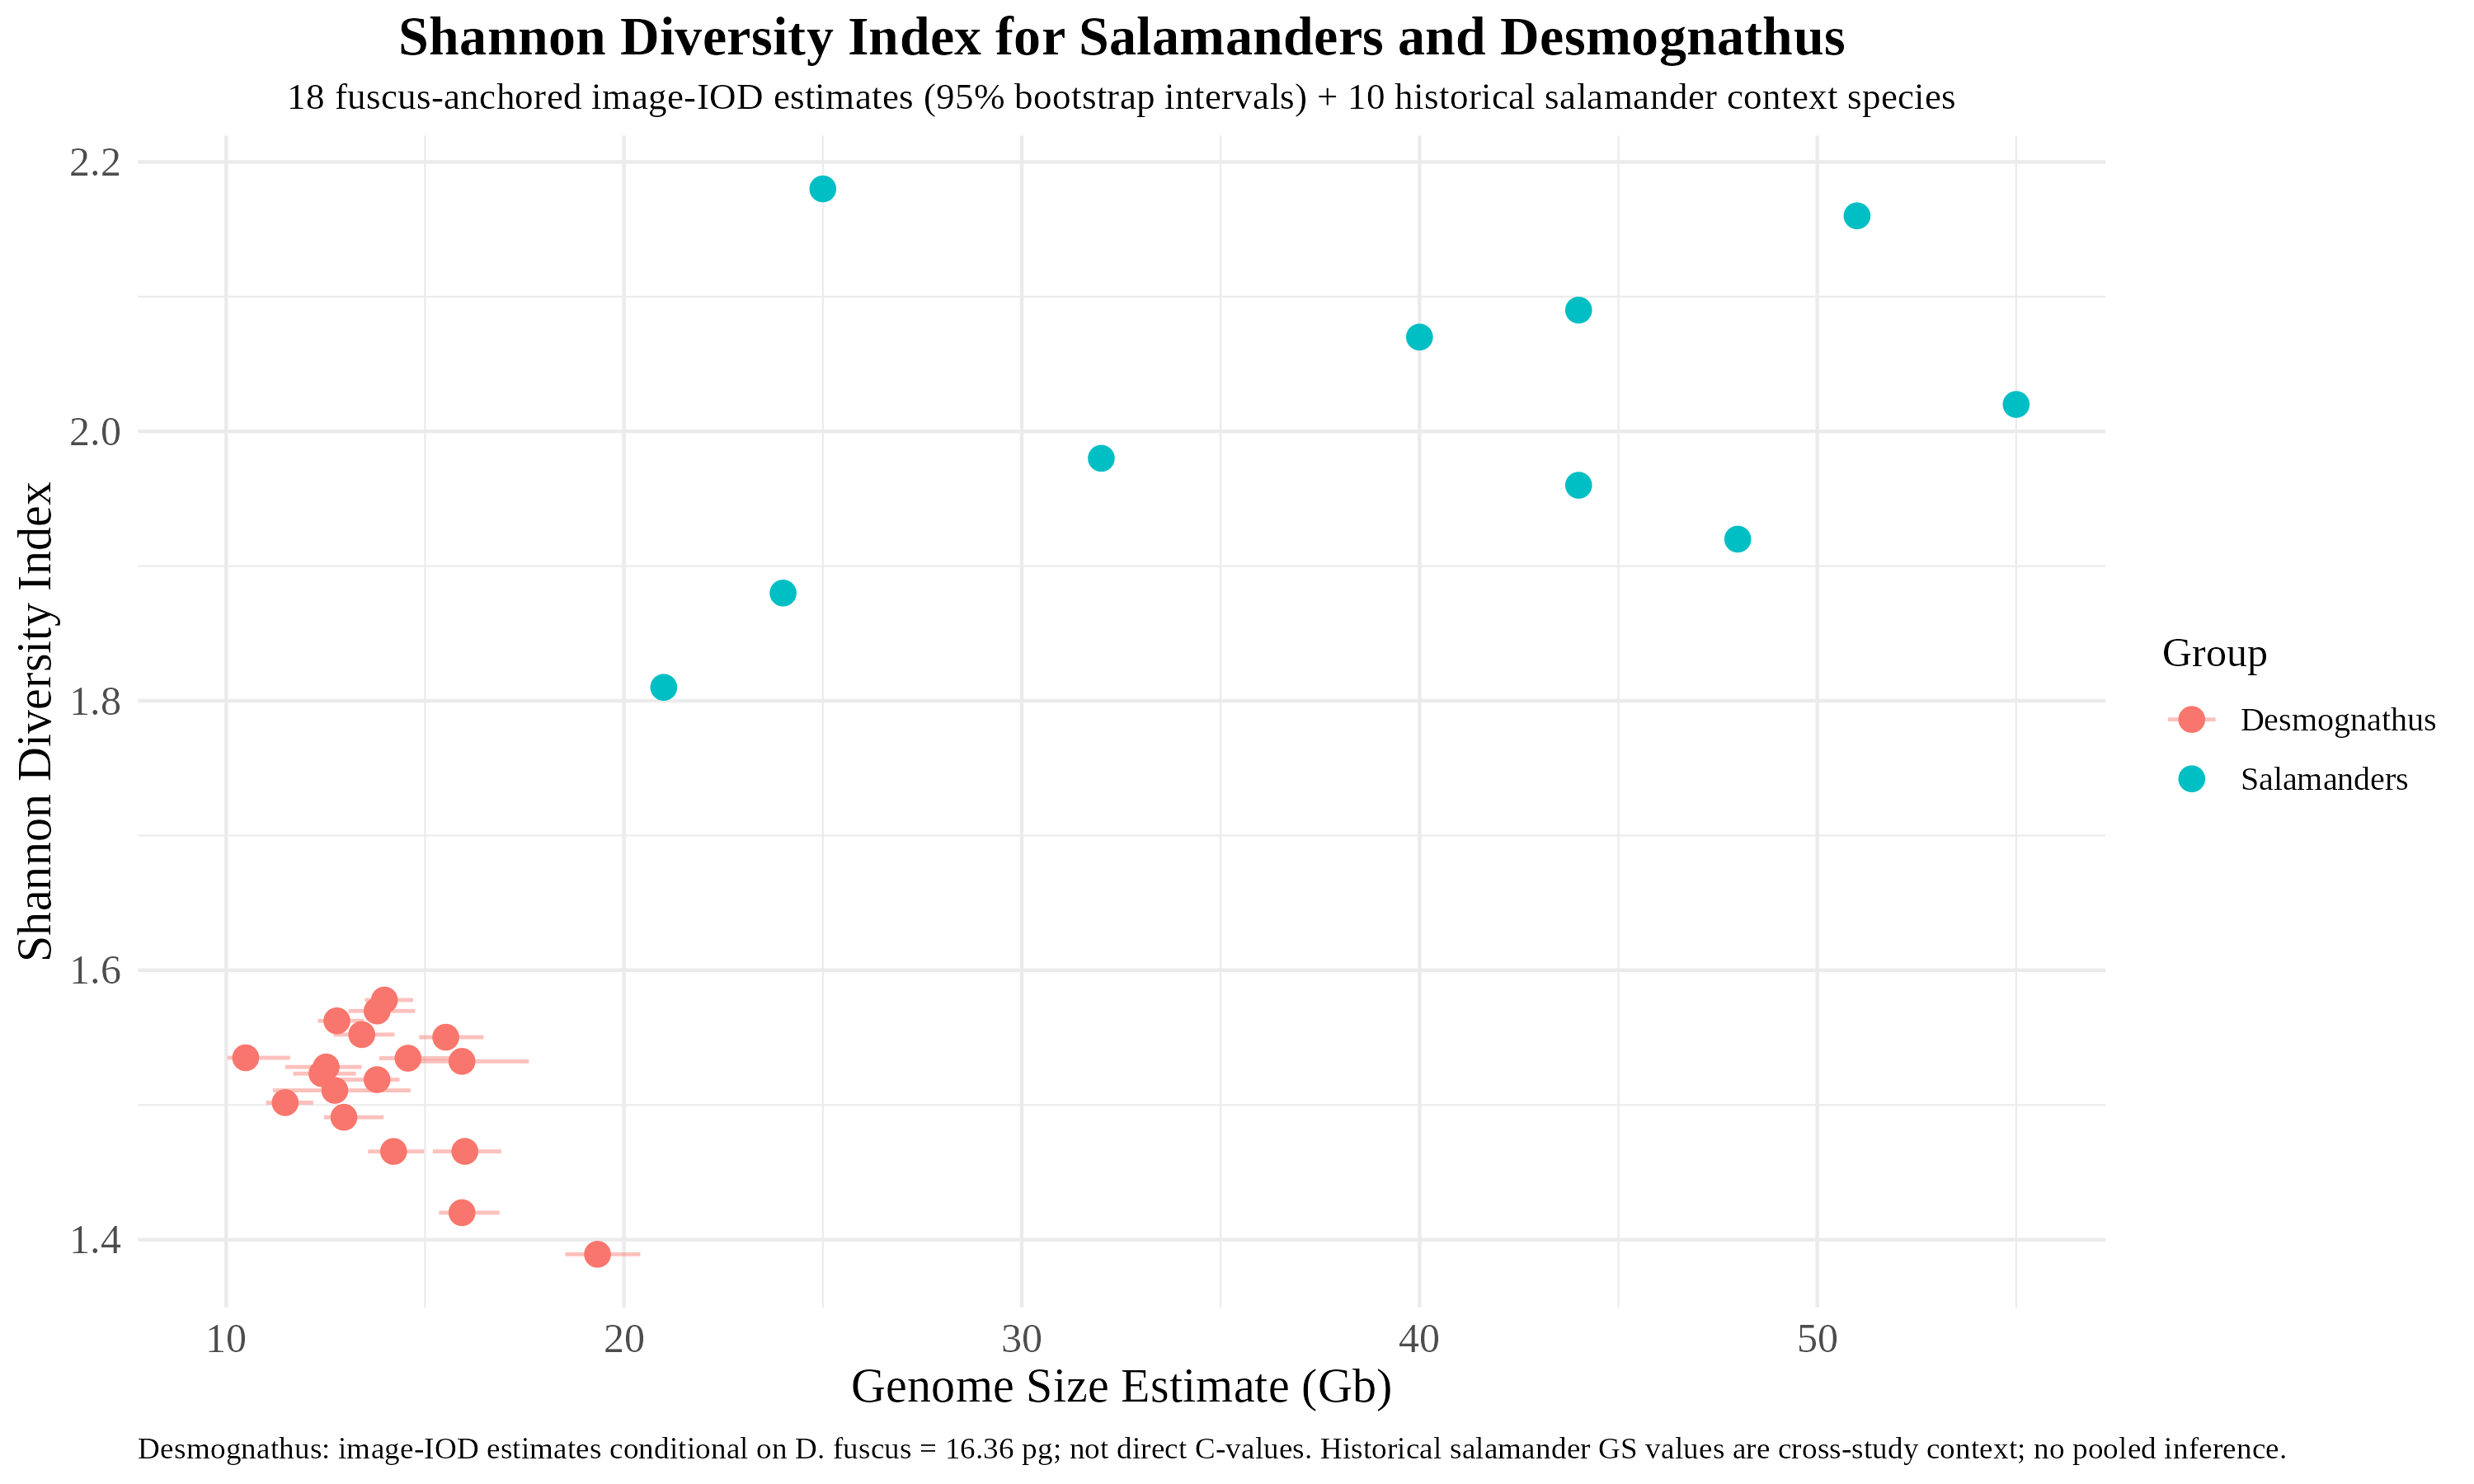

In [6]:
cross_taxon = read_csv("results/data/research_review/te_shannon_cross_taxon_context_te34_v1.csv")
group_counts = read_csv("results/data/research_review/te_shannon_cross_taxon_group_counts_v1.csv")
top10 = read_csv("results/data/research_review/te_top10_superfamily_contributions_te34_v1.csv")
wang_context = read_csv("results/data/research_review/wang_ji_2025_shannon_context_v1.csv")
wang_provenance = json.loads((REVIEW_DATA_DIR / "wang_ji_2025_shannon_context_v1.provenance.json").read_text())
assert len(wang_context) == 87
assert len(cross_taxon) == 121
assert cross_taxon.query("group == 'Desmognathus'").species.nunique() == 34
assert len(top10) == 340 and top10.species.nunique() == 34
display(group_counts)
display(pd.json_normalize(wang_provenance, sep="."))
display(top10.groupby("species", as_index=False).agg(
    top10_total=("top10_renormalized_proportion", "sum"),
    shannon_top10=("shannon_component", "sum"),
))
show_figure("results/figures/research_review/te_shannon_cross_taxon_context_te34_v1.png")

genome_scatter = read_csv("results/data/research_review/te_shannon_genome_size_scatter_te18_v1.csv")
genome_match_audit = read_csv("results/data/research_review/te_shannon_genome_size_match_audit_te34_v1.csv")
genome_stats = (REVIEW_DATA_DIR / "te_shannon_genome_size_stats_te18_v1.txt").read_text()
desmo_scatter = genome_scatter.query("group == 'Desmognathus'").copy()
historical_salamanders = genome_scatter.query("group == 'Salamanders'").copy()
assert len(genome_scatter) == 28
assert len(desmo_scatter) == 18 and desmo_scatter.canonical_species.is_unique
assert len(historical_salamanders) == 10
assert desmo_scatter.genome_size_gb.nunique() > 10
assert set(desmo_scatter.is_direct_c_value.astype(str).str.lower()) == {"false"}
assert len(genome_match_audit) == 37
assert genome_match_audit.included_in_scatter.astype(str).str.lower().eq("true").sum() == 18
display(desmo_scatter[[
    "species", "genome_size_gb", "genome_size_ci_low_gb",
    "genome_size_ci_high_gb", "shannon_top10_superfamilies",
    "genome_support_tier", "genome_support_warnings",
]])
display(genome_match_audit)
print(genome_stats)
show_figure("results/figures/research_review/te_shannon_genome_size_scatter_te18_v1.png")

## 4. Within-TE34 level and denominator sensitivity

,species,te_level,composition_mode,observed_richness,shannon_entropy,gini_simpson,hill_q1,hill_q2,pielou_evenness
0,abditus,order,classified_conditional,10,1.037692,0.538249,2.822696,2.165671,0.450664
1,adatsihi,order,classified_conditional,10,1.087790,0.564232,2.967707,2.294800,0.472421
2,aeneus,order,classified_conditional,10,1.102461,0.572712,3.011570,2.340344,0.478793
3,amphileucus,order,classified_conditional,10,1.127359,0.577731,3.087492,2.368156,0.489606
4,anicetus,order,classified_conditional,10,1.100317,0.572407,3.005117,2.338673,0.477861
...,...,...,...,...,...,...,...,...,...
131,tilleyi,superfamily,mass_aware_unresolved_bin,26,1.818590,0.754283,6.163163,4.069726,0.558176
132,valentinei,superfamily,mass_aware_unresolved_bin,26,1.754618,0.732874,5.781238,3.743548,0.538541
133,valtos,superfamily,mass_aware_unresolved_bin,27,1.675958,0.698883,5.343913,3.320964,0.508508
134,welteri,superfamily,mass_aware_unresolved_bin,27,1.783109,0.737845,5.948321,3.814531,0.541019


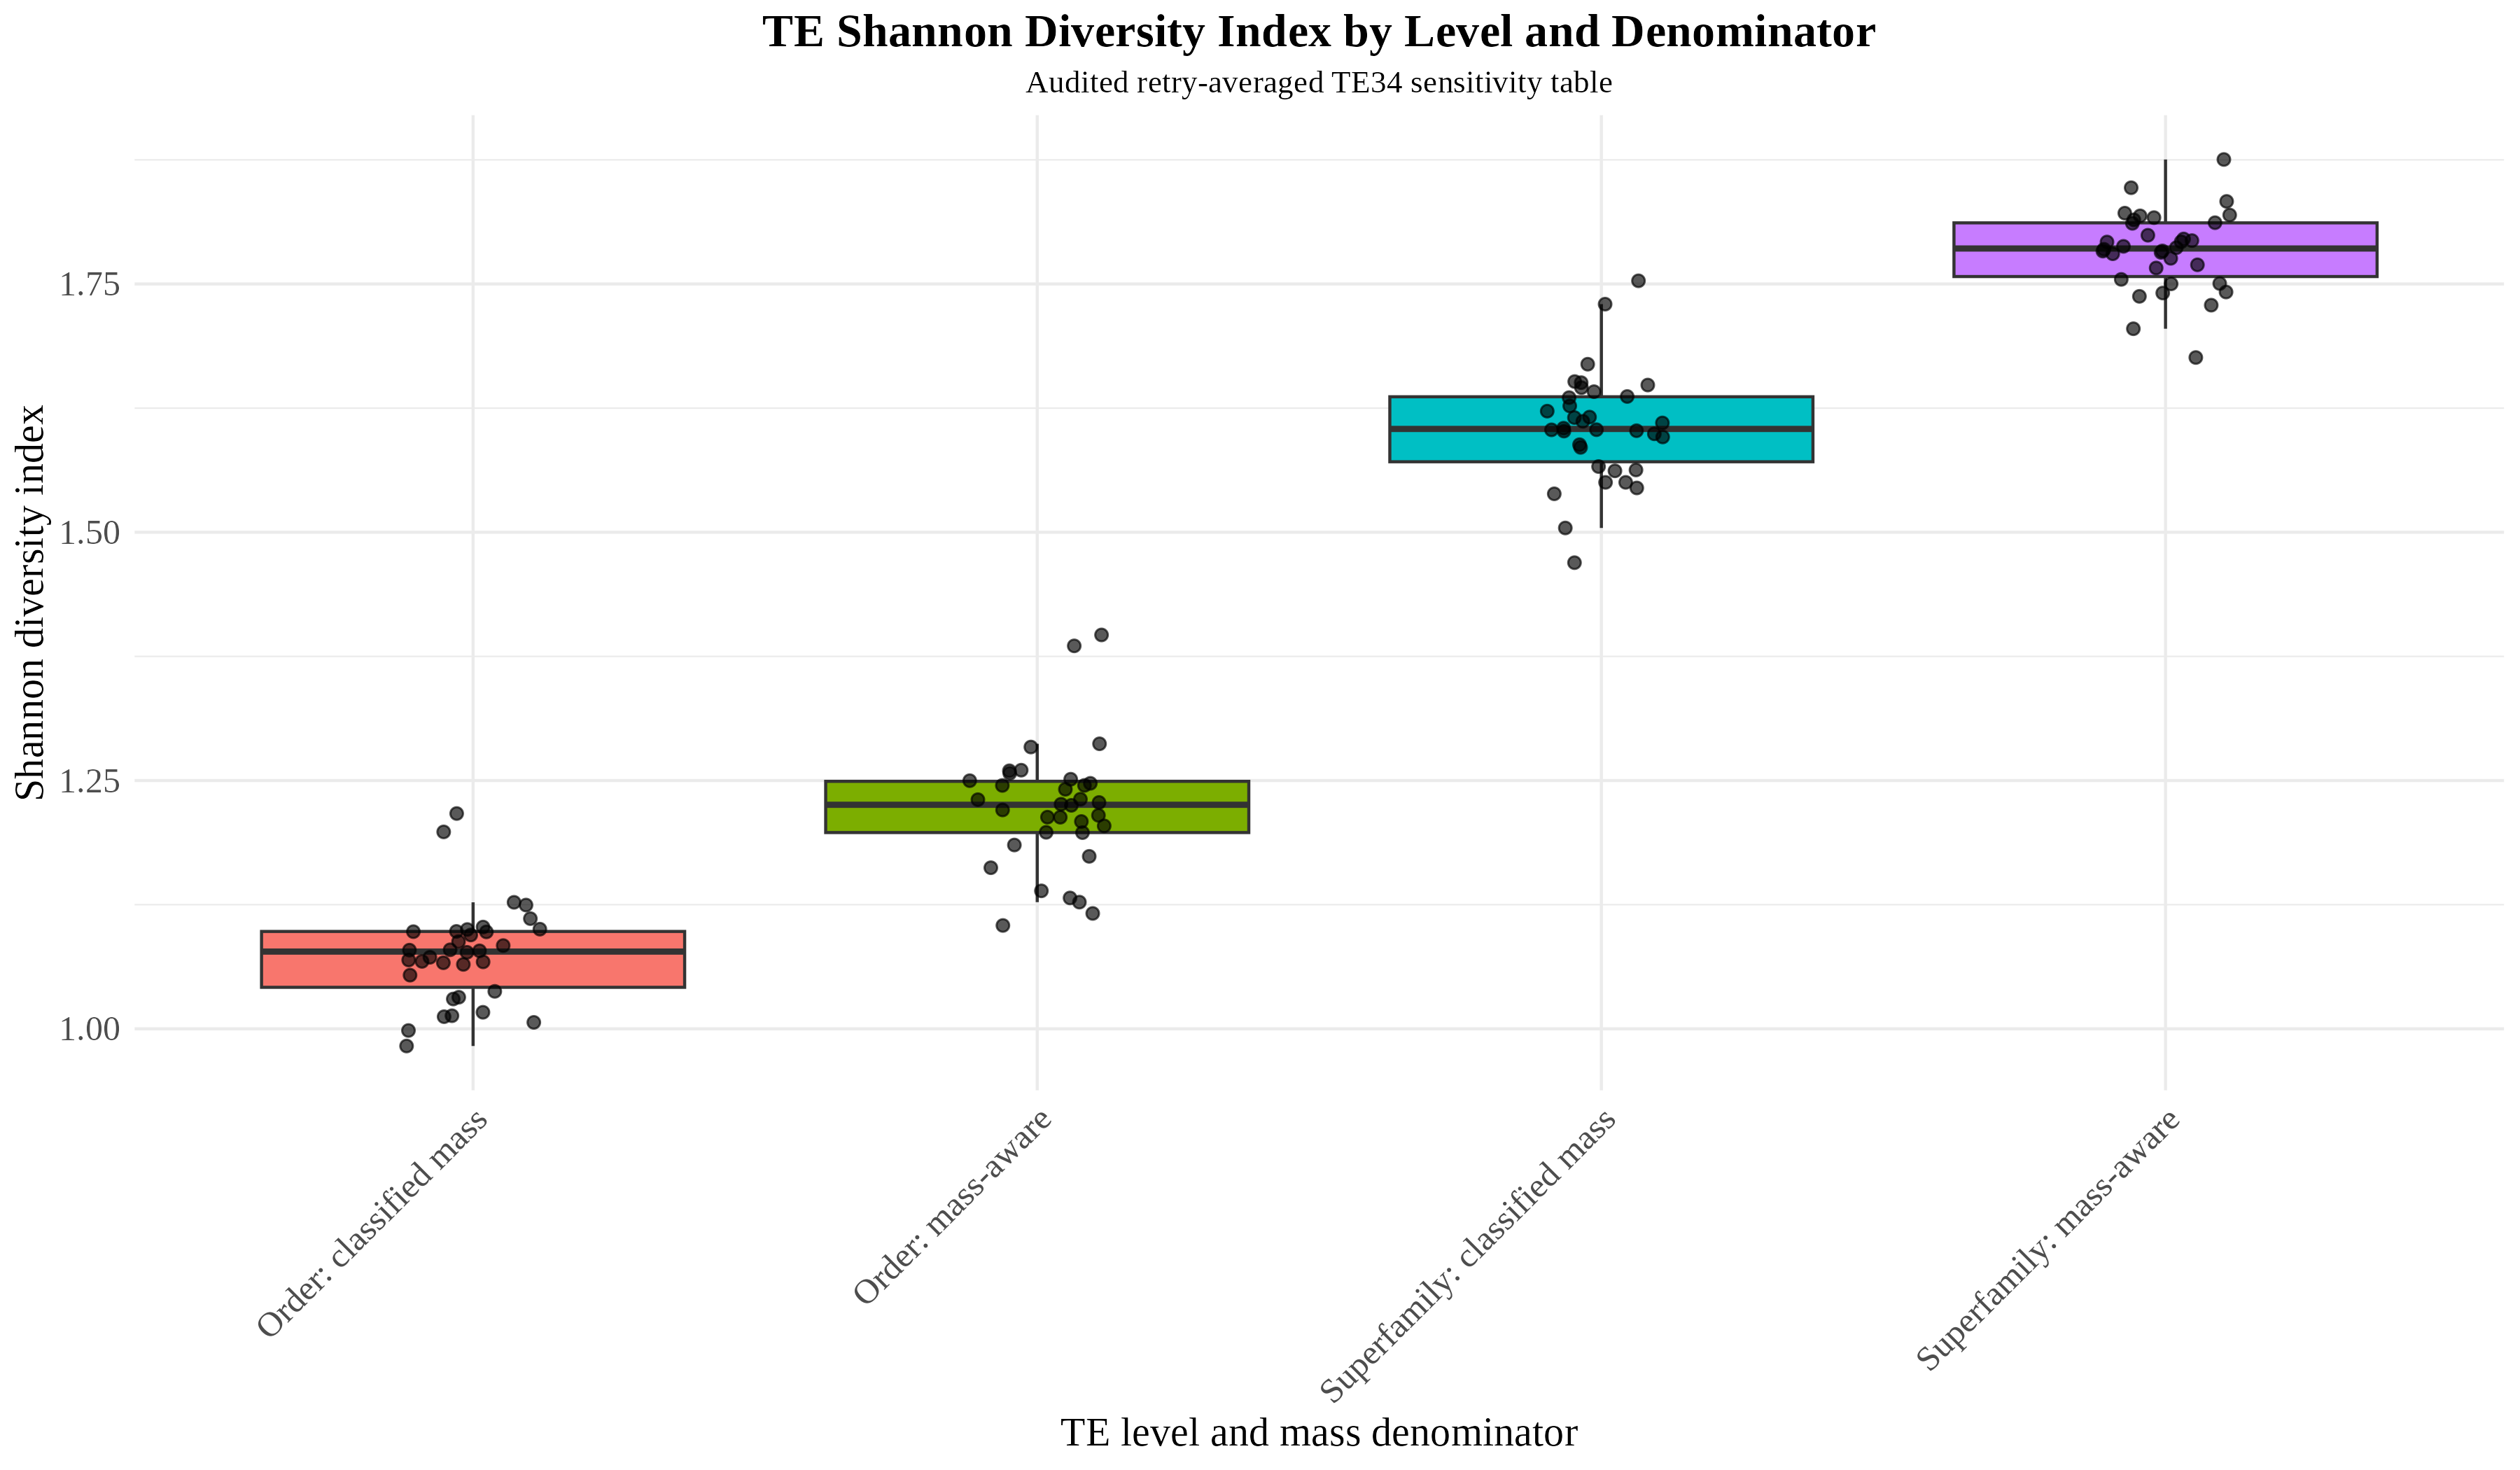

In [7]:
diversity = read_csv("results/data/corrected/te34_replicate_averaged/te_diversity_mass_sensitivity_te34_replicate_averaged_v1.csv")
assert diversity.species.nunique() == 34
display(diversity.sort_values(["te_level", "composition_mode", "species"]))
show_figure("results/figures/research_review/te_diversity_te34_v1.png")

## 5. Superfamily prevalence and the PCA feature contract

The original 35-species review identified three sparse superfamilies: Chapaev
in 14/35 species (40%), Dada in 10/35 (28.57%), and Ginger in 1/35 (2.86%).
The documented decision was to **retain Chapaev and Dada and exclude Ginger**.

The audited panel now contains 34 genomic resources, so those historical counts
must not be silently relabeled as TE34 results. After resource exclusions and
within-species retry averaging, the corresponding current counts are 12/34,
9/34, and 1/34. The decision itself is unchanged. The table and exact wide
matrix below are generated by the same R runner that performs the PCA, making
the filter executable and reviewable rather than a prose-only convention.

In [8]:
prevalence = read_csv("results/data/research_review/te_superfamily_prevalence_te34_v1.csv")
pca_feature_matrix = read_csv("results/data/research_review/te_pca_superfamily_feature_matrix_te34_v1.csv")
pca_loadings = read_csv("results/data/research_review/te_pca_superfamily_loadings_te34_v1.csv")
pca_variance = read_csv("results/data/research_review/te_pca_variance_te34_v1.csv")

policy_features = prevalence.query("superfamily in ['Chapaev', 'Dada', 'Ginger']").copy()
observed_presence = dict(zip(policy_features.superfamily, policy_features.species_present))
observed_decisions = dict(zip(policy_features.superfamily, policy_features.pca_decision))
assert observed_presence == {"Chapaev": 12, "Dada": 9, "Ginger": 1}
assert observed_decisions == {"Chapaev": "retain", "Dada": "retain", "Ginger": "exclude"}
assert policy_features.set_index("superfamily").loc["Ginger", "decision_reason"] == "user_declared_sparse_superfamily"
assert len(pca_feature_matrix) == 34 and pca_feature_matrix.species.is_unique
assert {"Chapaev", "Dada"}.issubset(pca_feature_matrix.columns)
assert "Ginger" not in pca_feature_matrix.columns
assert set(pca_loadings.superfamily) == set(pca_feature_matrix.columns) - {"species"}

display(policy_features[[
    "superfamily", "species_present", "panel_species", "prevalence_percent",
    "pca_decision", "decision_reason",
]])
display(prevalence.sort_values(["pca_decision", "species_present", "superfamily"], ascending=[True, True, True]))
display(Markdown(
    f"**Exact PCA input:** {len(pca_feature_matrix)} species × "
    f"{len(pca_feature_matrix.columns) - 1} retained superfamilies."
))

,superfamily,species_present,panel_species,prevalence_percent,pca_decision,decision_reason
25,Chapaev,12,34,35.294118,retain,user_declared_retained_sparse_superfamily
26,Dada,9,34,26.470588,retain,user_declared_retained_sparse_superfamily
28,Ginger,1,34,2.941176,exclude,user_declared_sparse_superfamily


,superfamily,panel,panel_species,species_present,prevalence_fraction,prevalence_percent,nonzero_variance,pca_decision,decision_reason
28,Ginger,TE34,34,1,0.029412,2.941176,True,exclude,user_declared_sparse_superfamily
27,Merlin,TE34,34,4,0.117647,11.764706,True,retain,retained_nonzero_variance
26,Dada,TE34,34,9,0.264706,26.470588,True,retain,user_declared_retained_sparse_superfamily
25,Chapaev,TE34,34,12,0.352941,35.294118,True,retain,user_declared_retained_sparse_superfamily
24,CR1,TE34,34,18,0.529412,52.941176,True,retain,retained_nonzero_variance
19,Academ,TE34,34,33,0.970588,97.058824,True,retain,retained_nonzero_variance
20,Cyrypton,TE34,34,33,0.970588,97.058824,True,retain,retained_nonzero_variance
21,EnSpm,TE34,34,33,0.970588,97.058824,True,retain,retained_nonzero_variance
22,Kolobok,TE34,34,33,0.970588,97.058824,True,retain,retained_nonzero_variance
23,Tc1-mariner,TE34,34,33,0.970588,97.058824,True,retain,retained_nonzero_variance


**Exact PCA input:** 34 species × 28 retained superfamilies.

## 6. PCA variance and species scores

This section recreates the historical PCA visual analysis on the audited TE34
composition table. It retains the original R plotting grammar while making the
documented current-panel, deterministic-seed, and silhouette-selected-cluster
adaptations. The current-data variance and coordinates are loaded below;
historical slide percentages are not substituted.

,PC,Eigenvalue,VarExplained,CumVarExplained
0,1,7.622141e+00,2.722193e-01,0.272219
1,2,5.181429e+00,1.850510e-01,0.457270
2,3,3.782432e+00,1.350869e-01,0.592357
3,4,2.293996e+00,8.192842e-02,0.674286
4,5,1.520650e+00,5.430893e-02,0.728595
5,6,1.189223e+00,4.247227e-02,0.771067
6,7,1.133500e+00,4.048215e-02,0.811549
7,8,1.080602e+00,3.859295e-02,0.850142
8,9,9.245085e-01,3.301816e-02,0.883160
9,10,7.668951e-01,2.738911e-02,0.910549


,superfamily,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28
0,Academ,0.338992,-0.003557,0.084798,-0.103715,0.064731,-0.035977,0.033795,-0.037236,-0.058707,0.015542,-0.066722,-0.033563,0.062388,-0.006854,-0.042878,-0.224544,0.244658,0.444247,-0.165891,-0.014551,-0.521145,-0.306751,0.146242,0.154184,0.312559,0.012217,0.001446,0.003167
25,Tc1-mariner,0.332040,0.080115,-0.018340,-0.006887,0.013906,0.037034,0.121989,0.147643,-0.122791,-0.037085,0.141389,-0.109697,0.138368,0.152440,-0.191959,0.191247,-0.142229,0.105672,-0.273513,0.375820,0.177223,0.080561,-0.541938,-0.120155,0.257687,-0.114769,0.004166,0.085722
5,Cyrypton,0.306175,0.128632,0.115835,-0.154068,0.132567,0.016038,-0.066193,0.041149,0.006307,-0.018438,-0.166479,0.040398,0.011756,-0.192462,-0.135677,-0.168382,-0.054036,0.255097,0.202896,-0.383290,-0.057118,0.511224,-0.141452,-0.376880,-0.172006,-0.049735,0.005698,0.012562
12,Jockey,0.292972,0.113824,-0.083604,0.175906,0.207606,0.084776,0.033085,0.178269,-0.055519,0.015230,-0.025231,0.041741,-0.015047,-0.129037,0.015605,-0.048101,0.416842,-0.533383,-0.309345,-0.295767,-0.008711,-0.085065,-0.180571,0.036258,-0.082912,0.255765,0.000386,0.006393
22,PIF-Harbinger,0.288755,0.184663,-0.040943,0.017469,-0.212941,-0.013597,-0.054899,-0.121052,-0.005372,-0.243320,0.083983,-0.094234,0.045988,0.051600,0.199095,0.305983,0.036708,-0.186786,0.146446,0.125999,-0.101789,0.007503,0.396670,-0.488882,0.200718,0.223974,0.024531,0.180971
9,Gypsy,-0.256025,0.156150,-0.271628,0.091039,0.100104,0.072775,-0.050120,0.100888,0.045333,0.124749,0.111803,0.046300,-0.102260,0.178059,0.029173,-0.014165,0.053669,0.217330,-0.036539,-0.156343,-0.056642,0.048337,-0.052534,0.013442,0.019352,0.090720,0.033655,0.793979
2,CR1,-0.253959,-0.292748,0.073419,-0.056537,-0.000616,0.055975,0.013604,0.008396,0.106124,-0.024010,0.013869,0.080124,0.006528,-0.173576,0.079033,-0.138287,0.082015,-0.079791,-0.068789,0.176218,-0.230736,0.038358,-0.209693,-0.290042,0.086417,0.098467,0.717617,0.003801
23,Penelope,-0.251694,-0.295243,0.072329,-0.059128,0.001788,0.053841,0.012678,0.004803,0.109968,-0.023201,0.013282,0.080967,-0.002664,-0.180791,0.080144,-0.138147,0.073833,-0.077229,-0.062501,0.178090,-0.230522,0.038977,-0.209180,-0.313735,0.107950,0.136212,-0.694450,0.061259
26,hAT,0.232764,-0.241319,0.036380,0.118584,-0.238277,0.085714,0.018378,-0.118687,0.114189,-0.213890,0.044069,0.163825,0.240953,-0.153481,0.450591,-0.029033,-0.121237,-0.113496,0.066961,-0.182429,-0.029645,0.205362,-0.139908,0.372653,0.190948,-0.261630,-0.000610,0.221002
10,Helitron,0.213124,-0.295518,-0.175929,0.047631,0.040813,0.017787,0.022612,-0.044337,0.027369,0.144779,-0.044181,-0.085469,-0.020560,0.077889,0.414638,0.030268,0.126803,0.224457,-0.169710,0.009000,0.172000,-0.289018,0.001580,-0.332657,-0.450801,-0.310570,-0.008710,0.019961


,species,display_species,cluster,selected_k,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28
0,abditus,D. abditus,2,2,-0.599675,1.309519,-0.003074,-1.021697,3.119741,1.039166,-1.396316,-2.171406,0.507693,0.524959,1.961656,-0.533054,0.526803,0.204716,0.197324,0.196004,0.379535,-0.307668,-0.040500,0.050893,0.029990,-0.040142,0.109939,0.111622,0.024682,0.003552,-0.003425,-3.205282e-06
1,adatsihi,D. adatsihi,2,2,0.548208,1.034790,0.124115,-2.186370,2.350221,1.103308,-0.768475,-1.514539,0.685634,0.079310,0.162078,-0.233124,0.029422,-0.461921,-0.255233,0.097957,-0.772971,0.176018,0.130705,-0.032456,0.031703,0.134848,-0.160877,-0.208807,-0.075839,0.014993,0.003327,4.869776e-06
2,aeneus,D. aeneus,2,2,-0.428121,1.555481,3.920306,1.092998,1.924269,-1.558630,-0.867978,-0.393275,-0.024941,0.592301,-2.433664,-0.527436,0.631154,-0.544187,-0.024977,-0.659159,0.294485,0.018042,0.057102,-0.254597,0.089402,0.176807,0.053065,0.009828,0.106192,-0.002044,0.000546,-2.843632e-06
3,amphileucus,D. amphileucus,2,2,3.678837,-3.583788,-2.347762,-0.551963,-1.123264,0.091776,-0.315039,-0.831234,1.285085,0.302425,-0.757762,-0.556162,0.019783,0.609631,0.085691,0.699140,0.243682,-0.437188,-0.167031,-0.428991,-0.037904,0.028723,0.060810,0.018570,0.152989,-0.081449,0.005870,4.123415e-06
4,anicetus,D. anicetus,2,2,0.917151,0.073003,0.727053,-1.923948,-0.138688,0.700230,0.627826,1.883884,-1.123240,-0.621810,0.089022,-0.655591,1.378274,-0.336770,0.064819,0.408950,0.222760,0.410476,0.167071,-0.004319,-0.074993,-0.114451,0.134150,-0.110546,0.087540,0.010600,-0.006790,5.872987e-06
5,apalachicolae,D. apalachicolae,2,2,0.515084,0.361014,0.110367,-0.997611,0.478110,-0.081881,0.410627,-0.229275,-0.190730,-0.831099,0.085809,0.920866,-0.435507,0.630766,-0.075727,-0.351024,0.471406,0.306385,0.257244,-0.068593,0.195772,0.214553,-0.341317,0.136752,0.135914,0.044442,-0.003454,5.844374e-06
6,aureatus,D. aureatus,2,2,0.334145,-2.170687,-5.202288,0.107935,0.220398,-1.470328,0.793160,-1.572870,-3.291556,1.684282,-0.245210,0.537503,0.700177,-0.306738,-0.024108,0.065923,0.013184,-0.106013,0.033464,0.140599,-0.005012,0.037394,-0.051349,-0.002618,0.017985,0.018937,0.001102,-3.203280e-07
7,auriculatus,D. auriculatus,2,2,-2.301637,2.278894,-1.746008,1.569966,-1.355588,-0.127194,-0.413886,-1.326071,-0.113280,-1.859506,0.199538,-0.936878,-0.427674,0.420622,-0.167175,-0.700150,0.308881,-0.295830,0.035648,0.252507,-0.322903,0.161181,0.039577,-0.017606,0.065213,0.039656,0.001693,2.843839e-06
8,bairdi,D. bairdi,2,2,-2.820653,2.460365,0.325974,1.379089,0.020921,0.654945,-0.506023,1.444028,-0.491393,1.518600,0.291276,-0.397596,-0.130446,0.672203,0.019223,0.033572,0.193300,-0.110337,0.351723,-0.047269,-0.131097,-0.130664,-0.109094,-0.140678,0.089774,-0.073906,-0.005037,2.759191e-06
9,balsameus,D. balsameus,2,2,1.007763,0.391370,0.282596,-1.997502,0.013991,-0.178458,-0.171175,0.624112,0.383795,0.269893,-1.116383,-0.027669,-0.779335,-0.225739,0.019653,0.615891,-0.403834,-0.547454,-0.173842,0.229616,-0.294583,0.003874,-0.100142,0.153640,0.091180,0.049049,-0.012677,-4.037703e-06


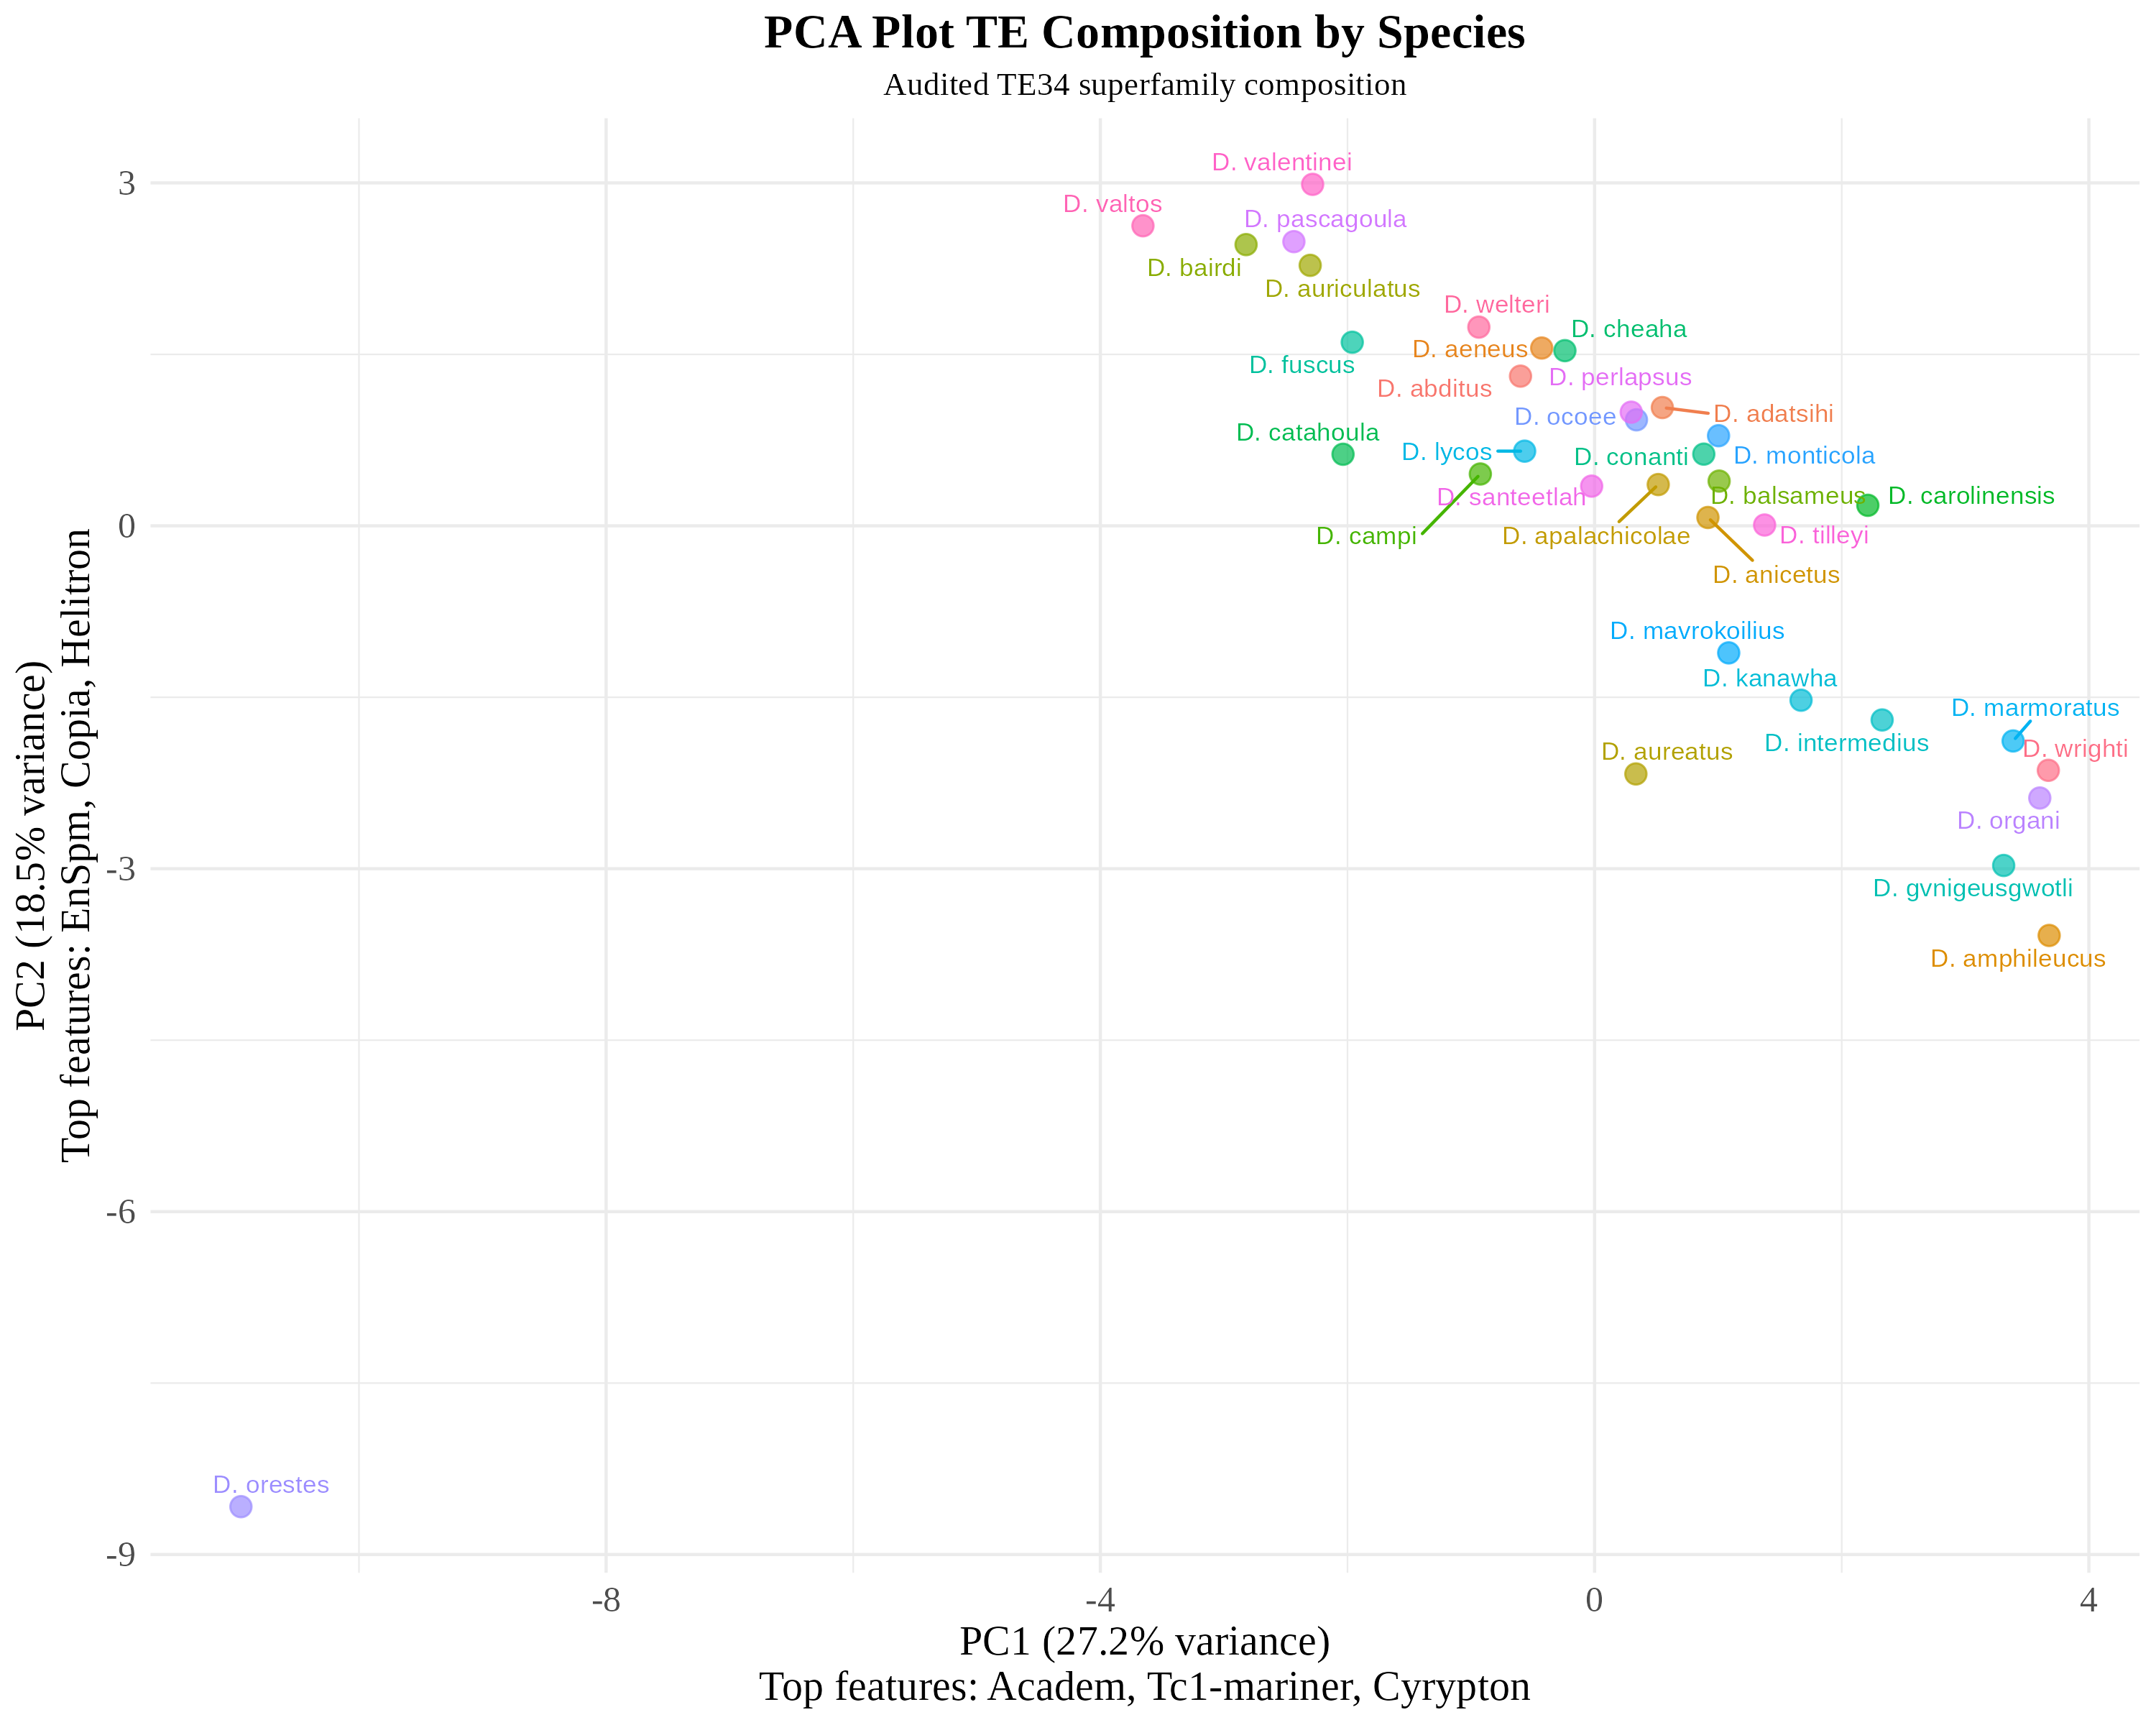

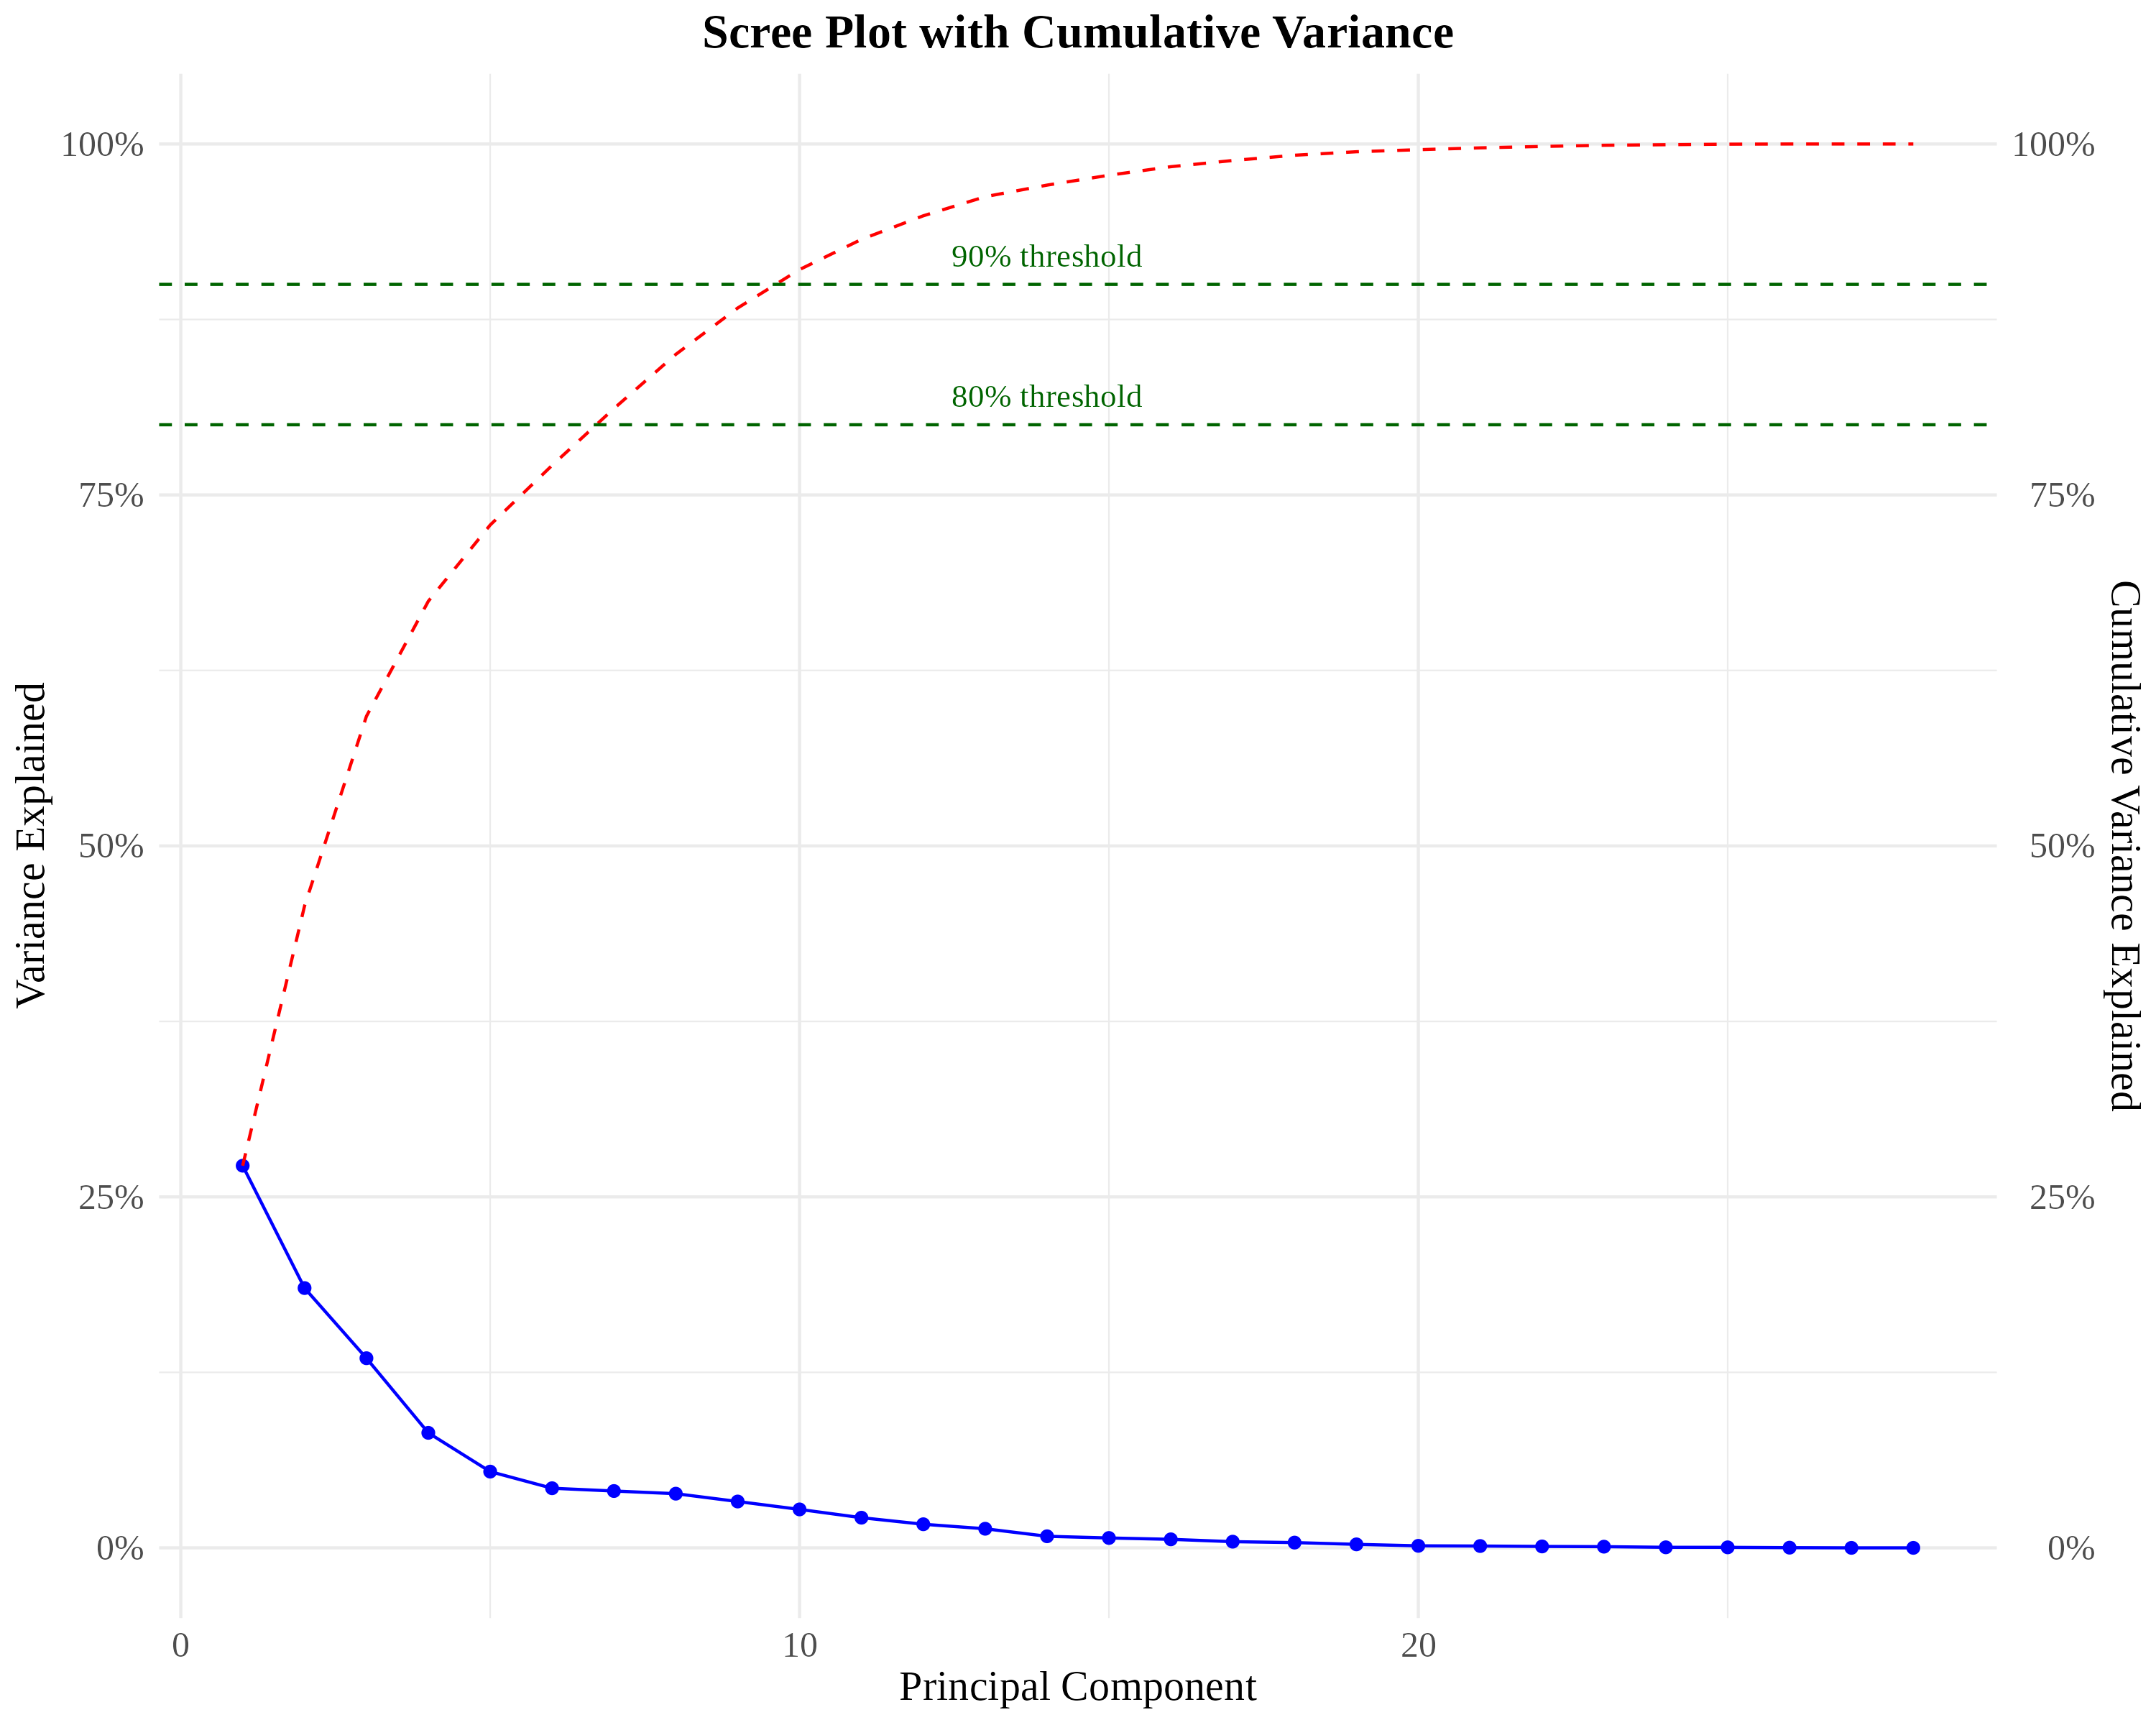

In [9]:
scores = read_csv("results/data/research_review/te_pca_scores_clusters_te34_v1.csv")
assert len(scores) == 34 and scores.species.is_unique
display(pca_variance)
display(pca_loadings.sort_values("PC1", key=lambda values: values.abs(), ascending=False).head(10))
display(scores)
show_figure("results/figures/research_review/te_pca_species_te34_v1.png")
show_figure("results/figures/research_review/te_pca_scree_te34_v1.png")

## 7. Cluster-number diagnostics and the historical k-means view

,k,wss,mean_silhouette,silhouette_defined,selected
0,1,712.465774,0.000000,False,False
1,2,509.711162,0.631439,True,True
2,3,355.367052,0.332386,True,False
3,4,273.118619,0.278948,True,False
4,5,194.277172,0.355061,True,False
5,6,162.992645,0.366997,True,False
6,7,134.350624,0.312047,True,False
7,8,114.818974,0.322986,True,False
8,9,98.254148,0.335480,True,False
9,10,84.339049,0.332910,True,False


,cluster,n_species,species
0,1,1,orestes
1,2,33,"abditus, adatsihi, aeneus, amphileucus, anicetus, apalachicolae, aureatus, auriculatus, bairdi, balsameus, campi, ca..."


**Current-data result:** maximum silhouette selects a singleton `orestes` outlier versus the remaining species. Treat this as outlier structure, not evidence for two broad biological TE-composition groups.

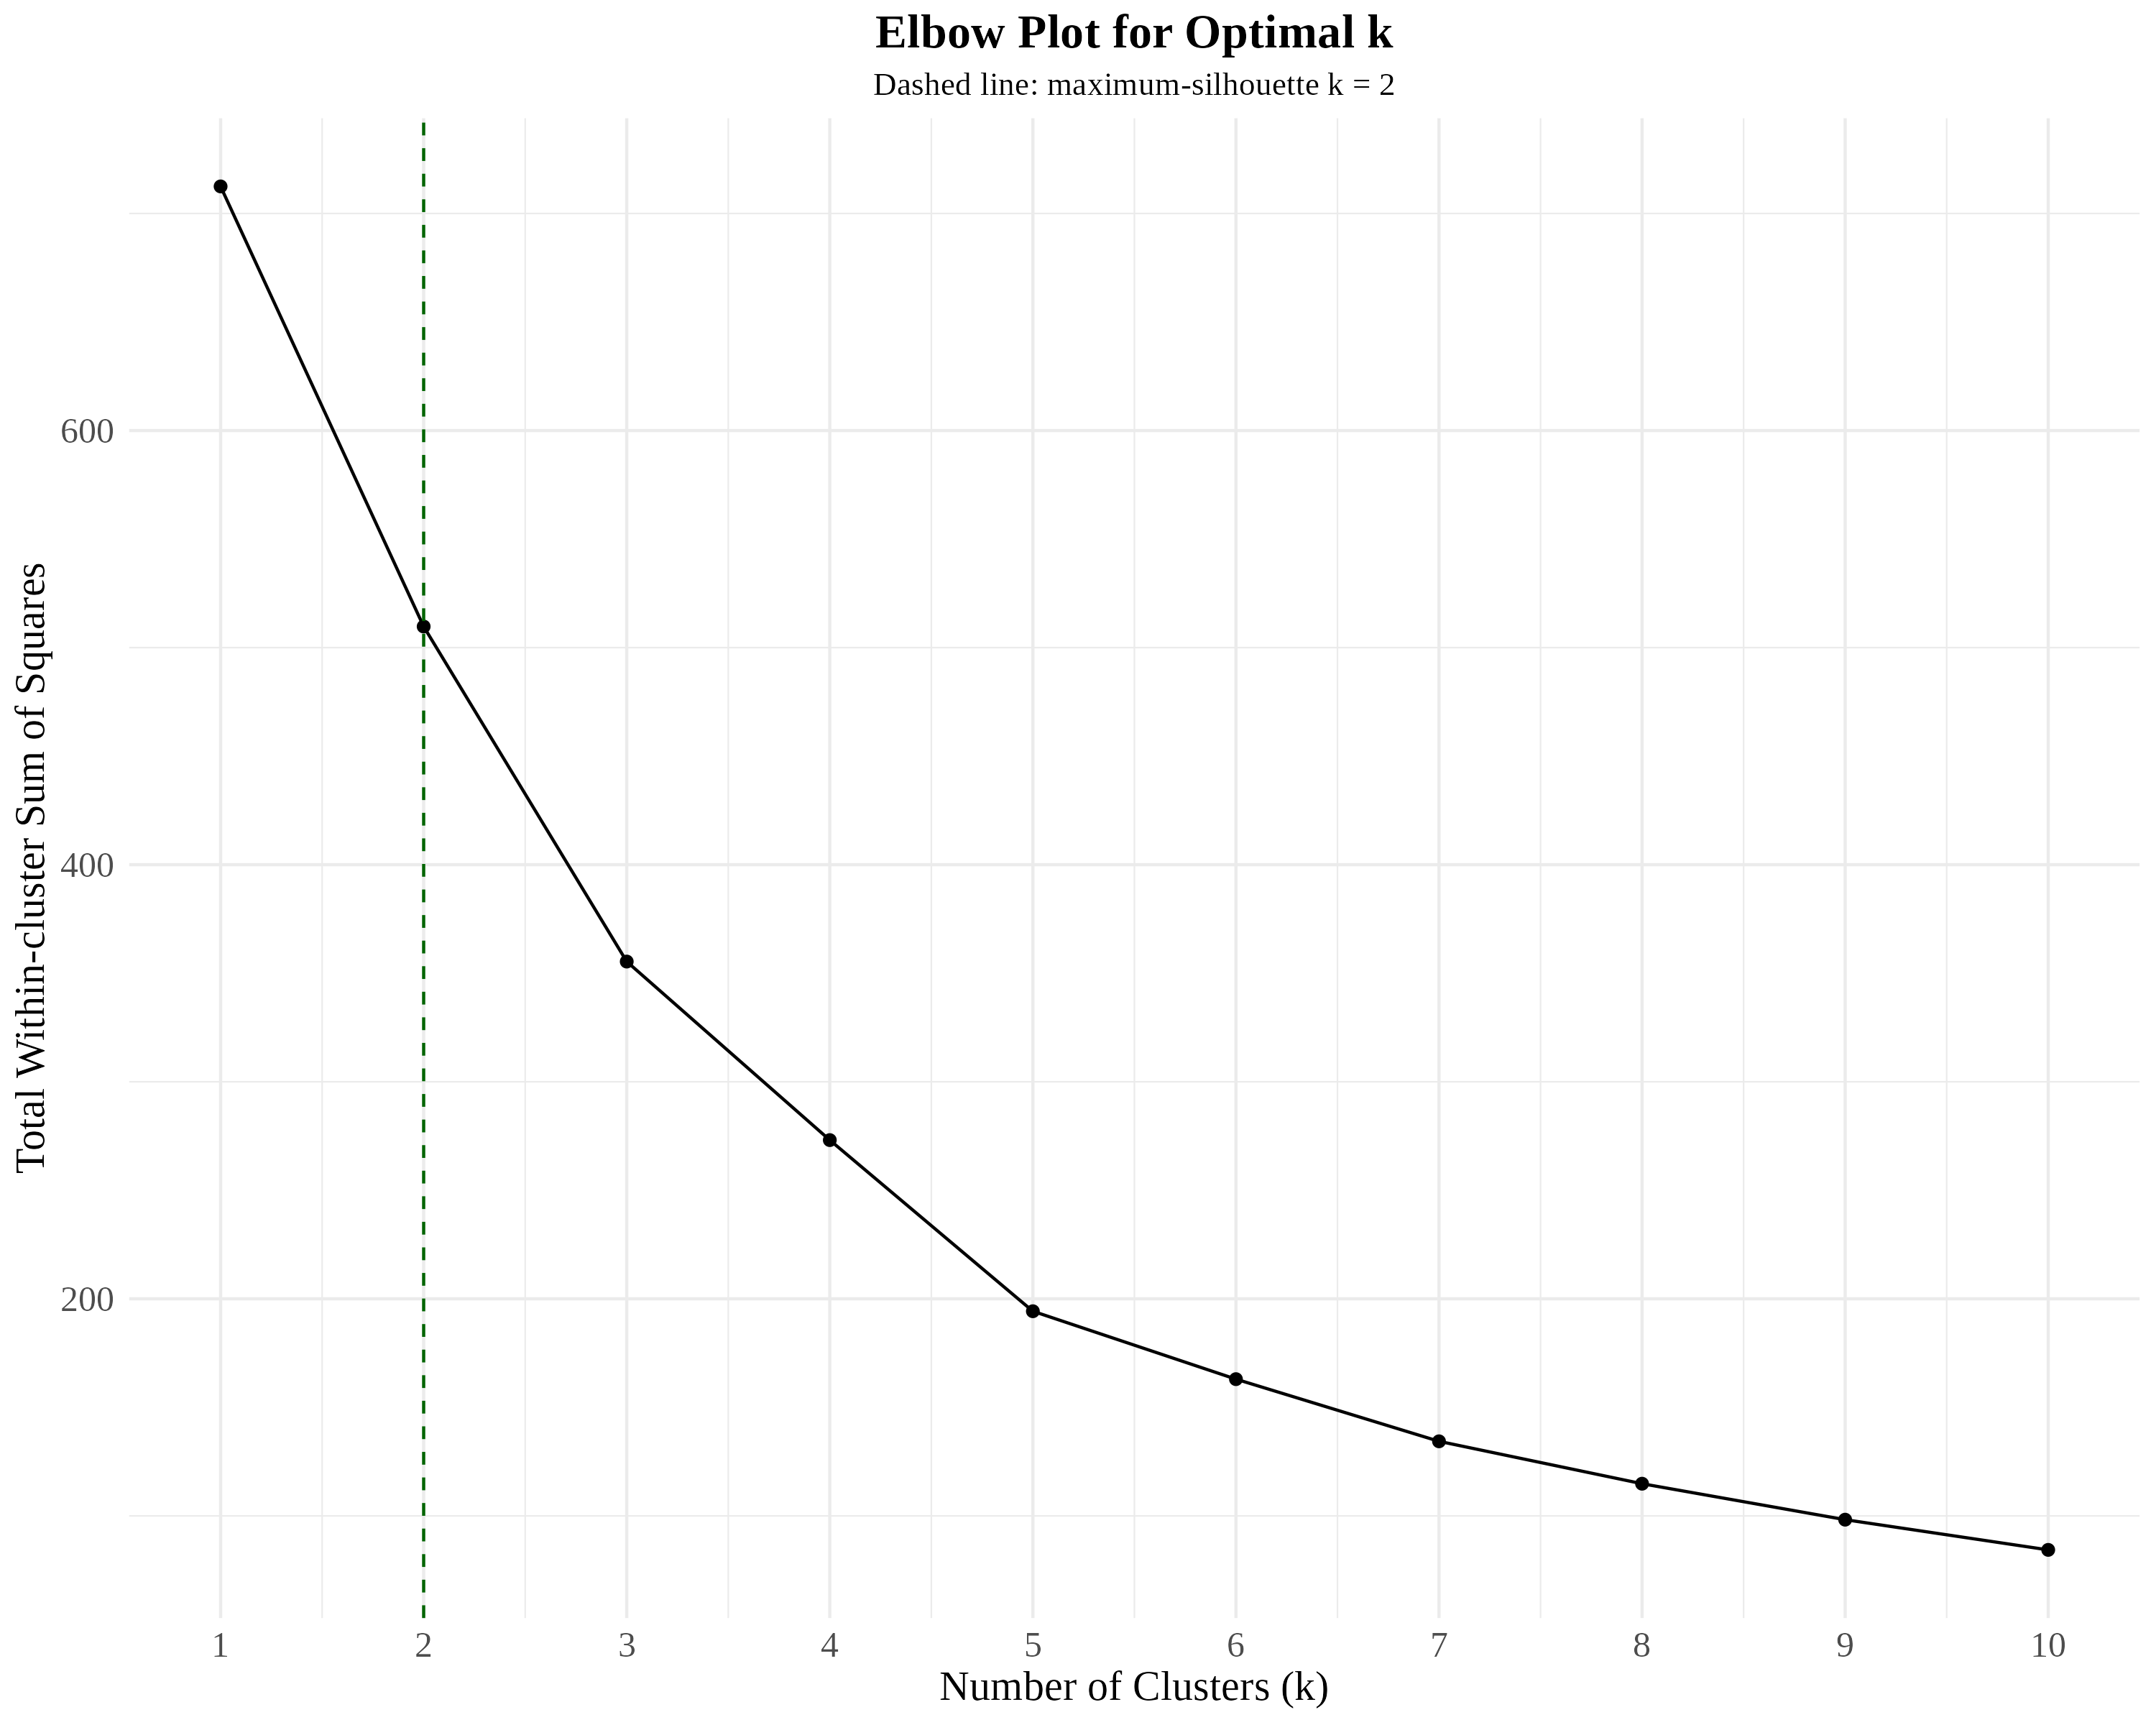

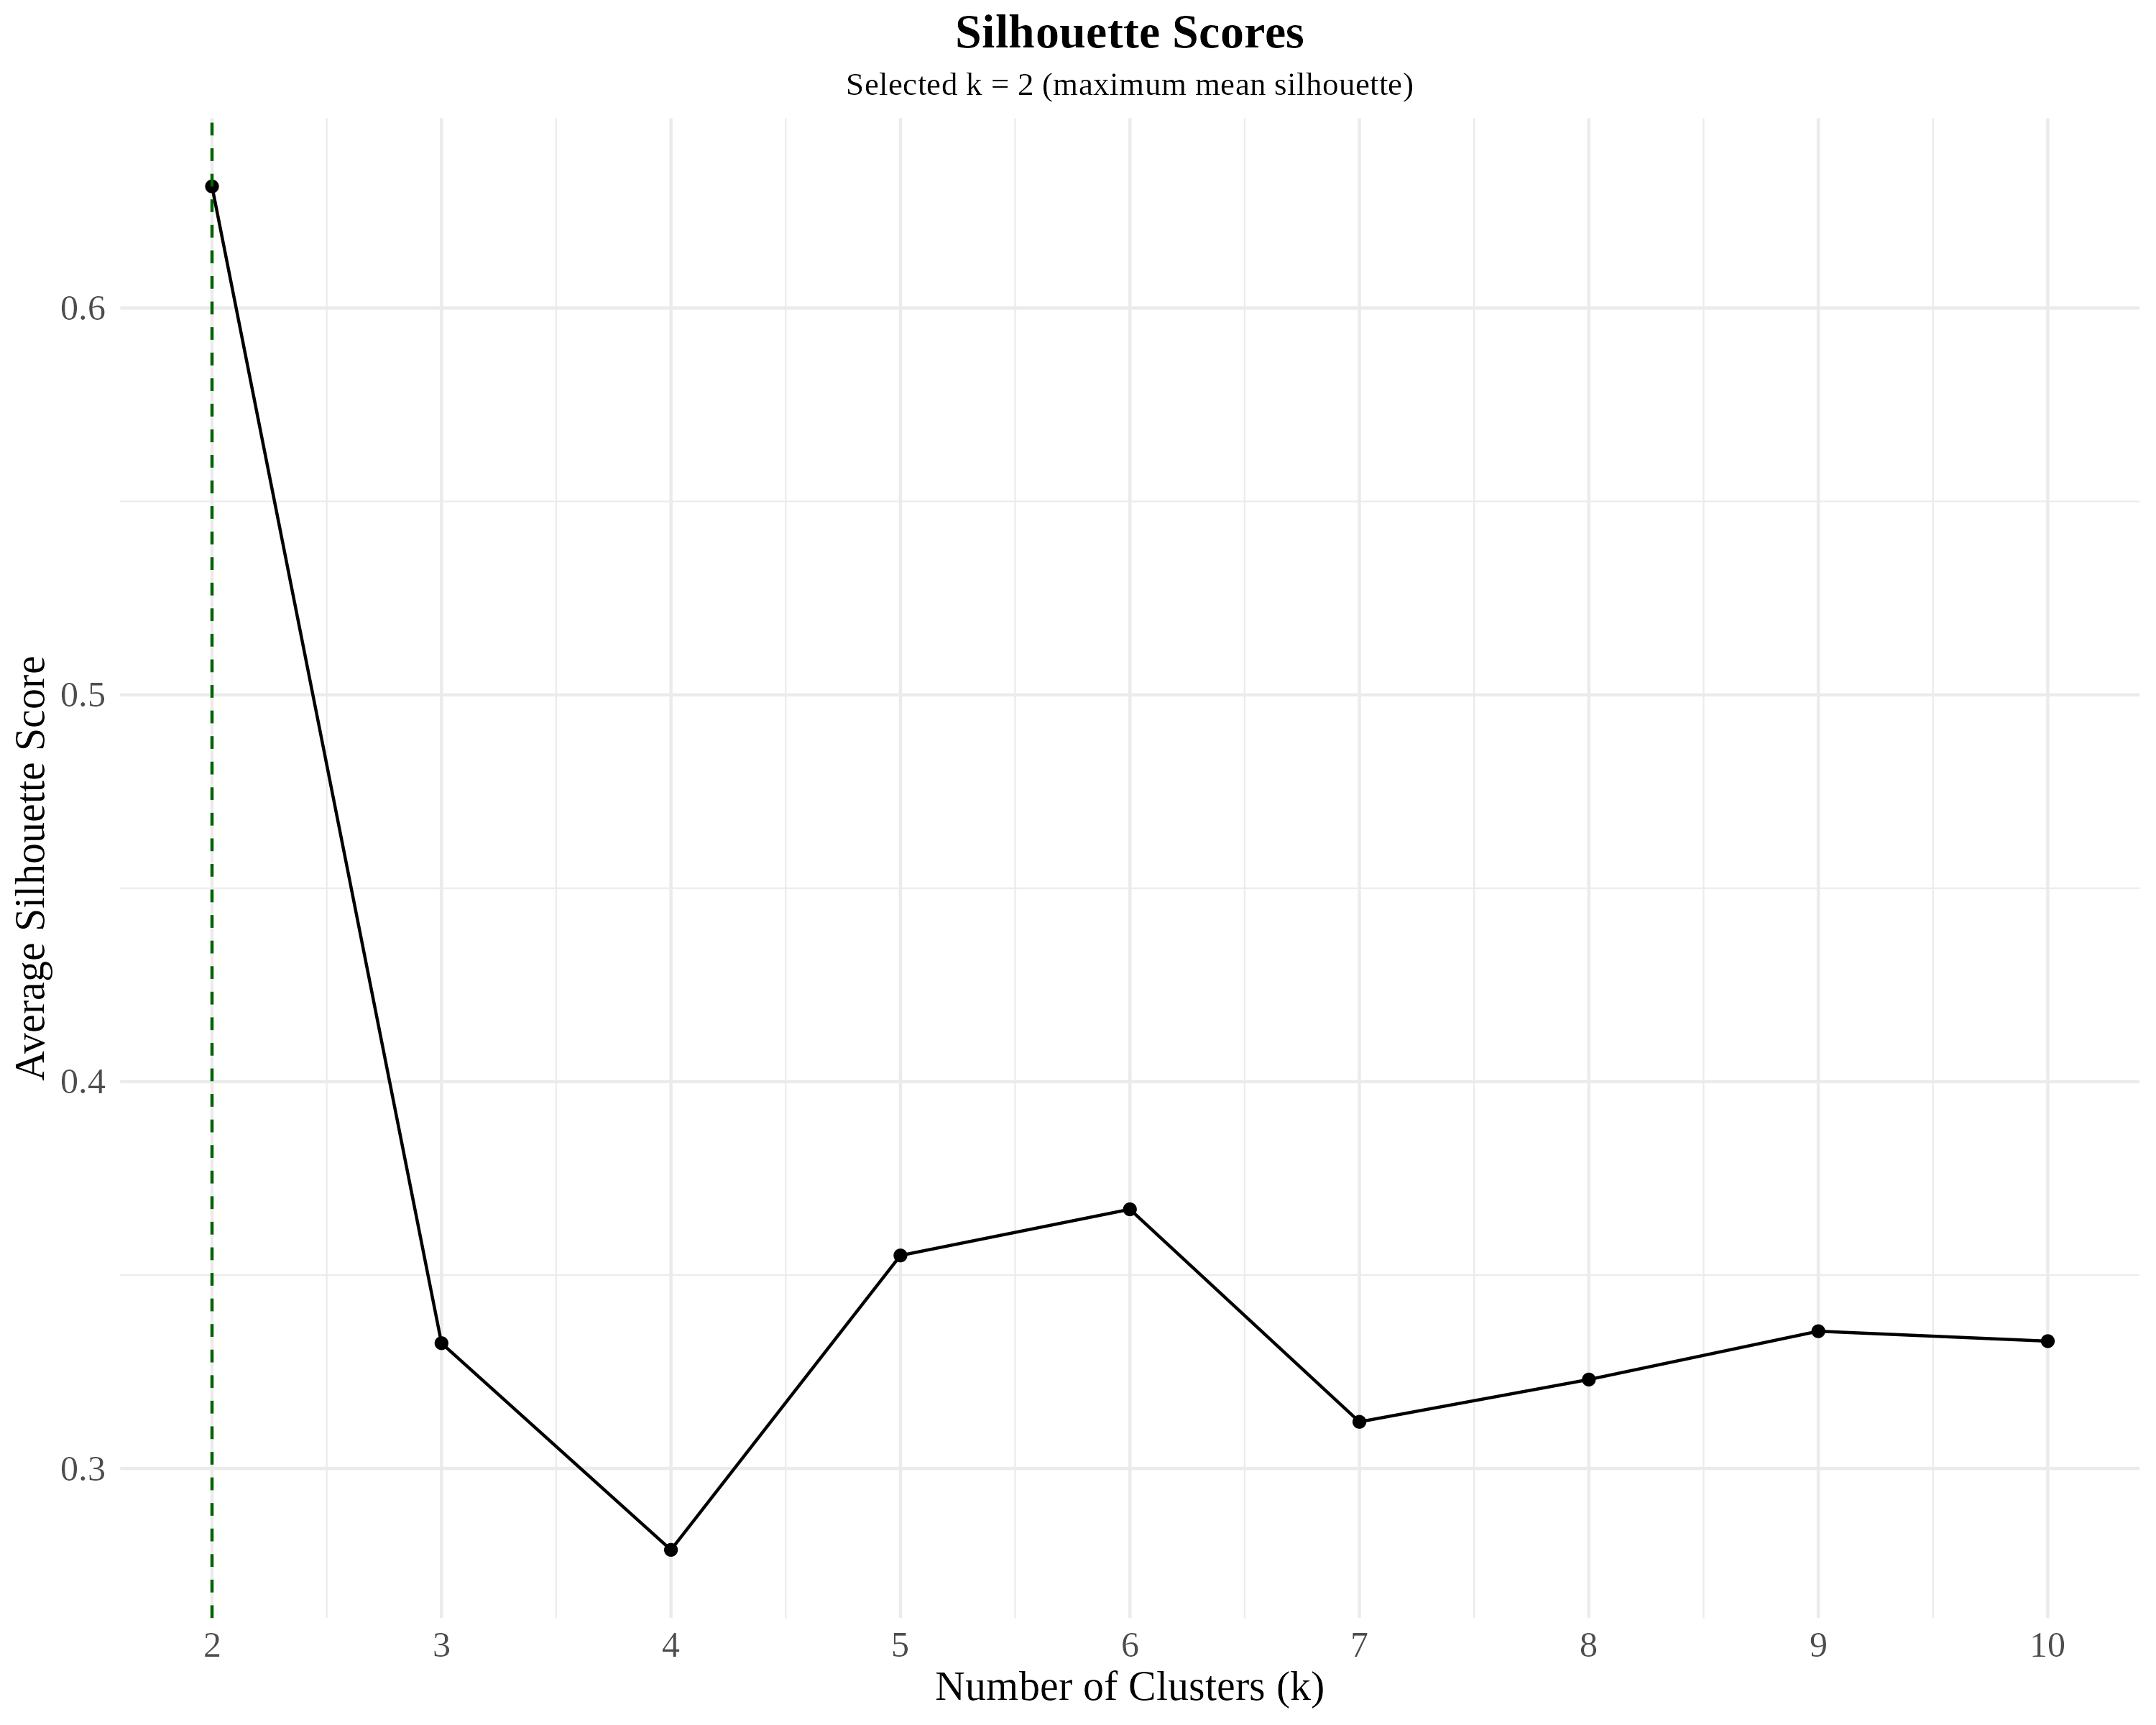

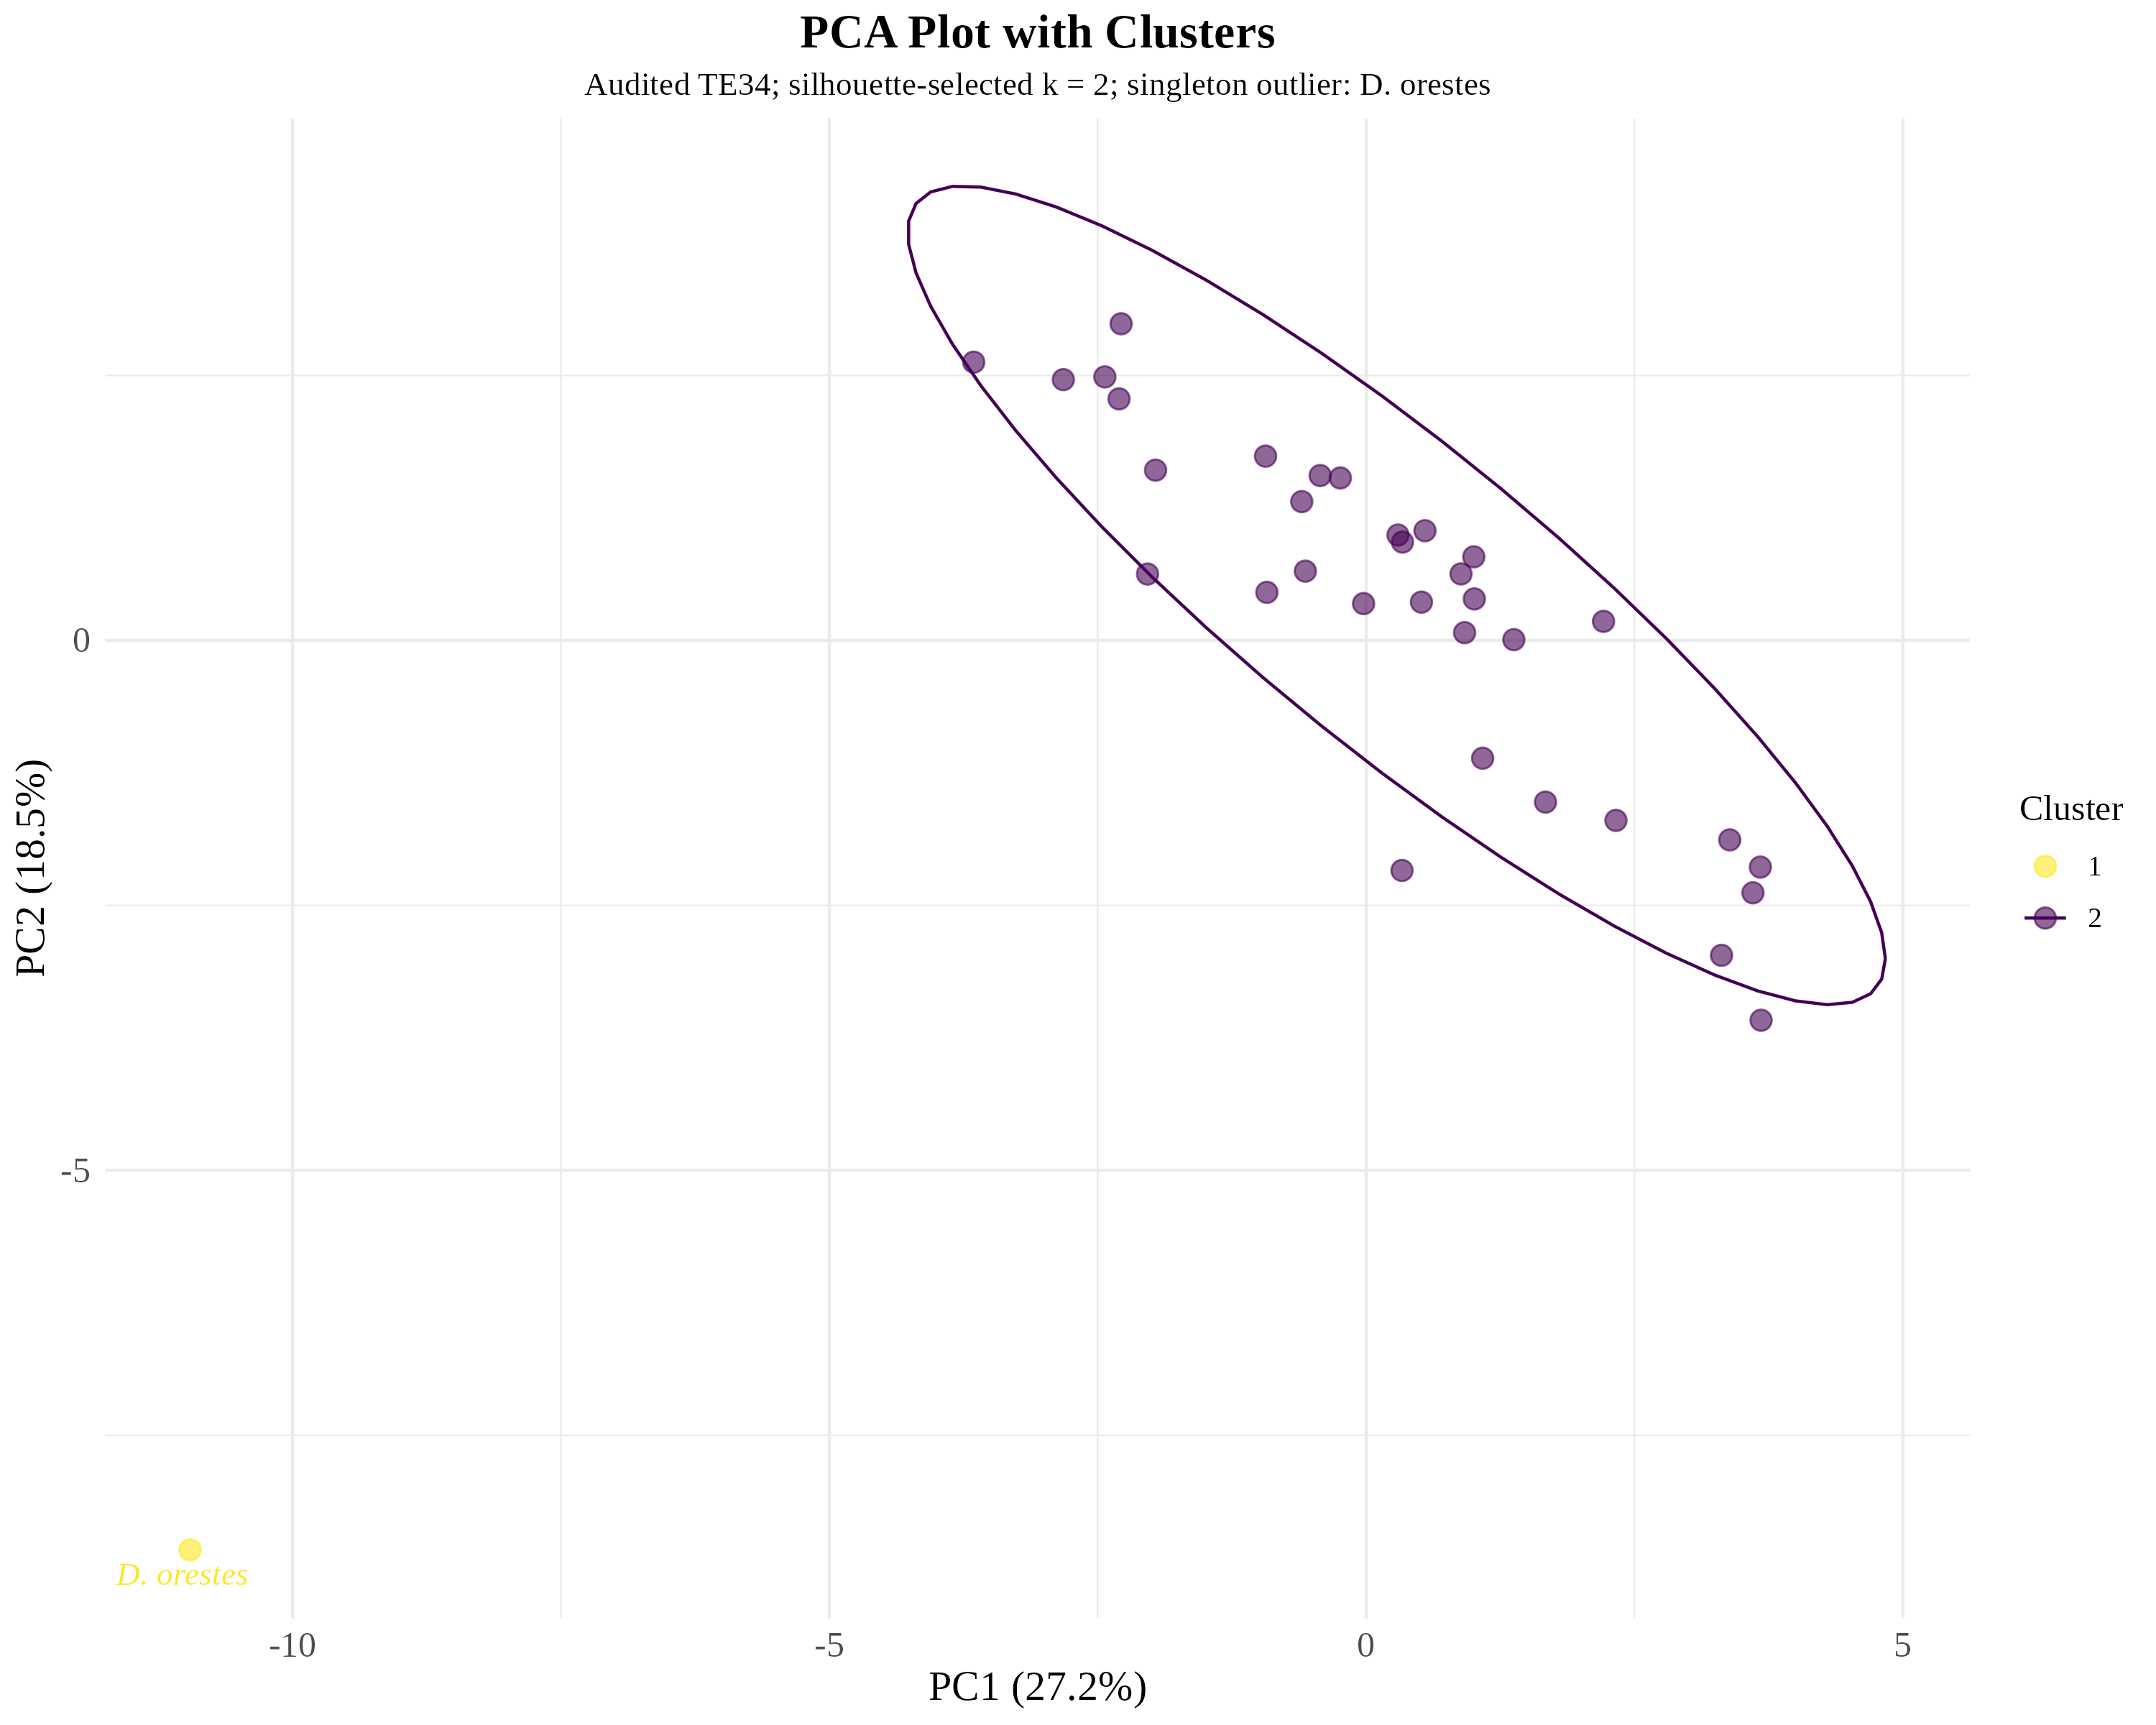

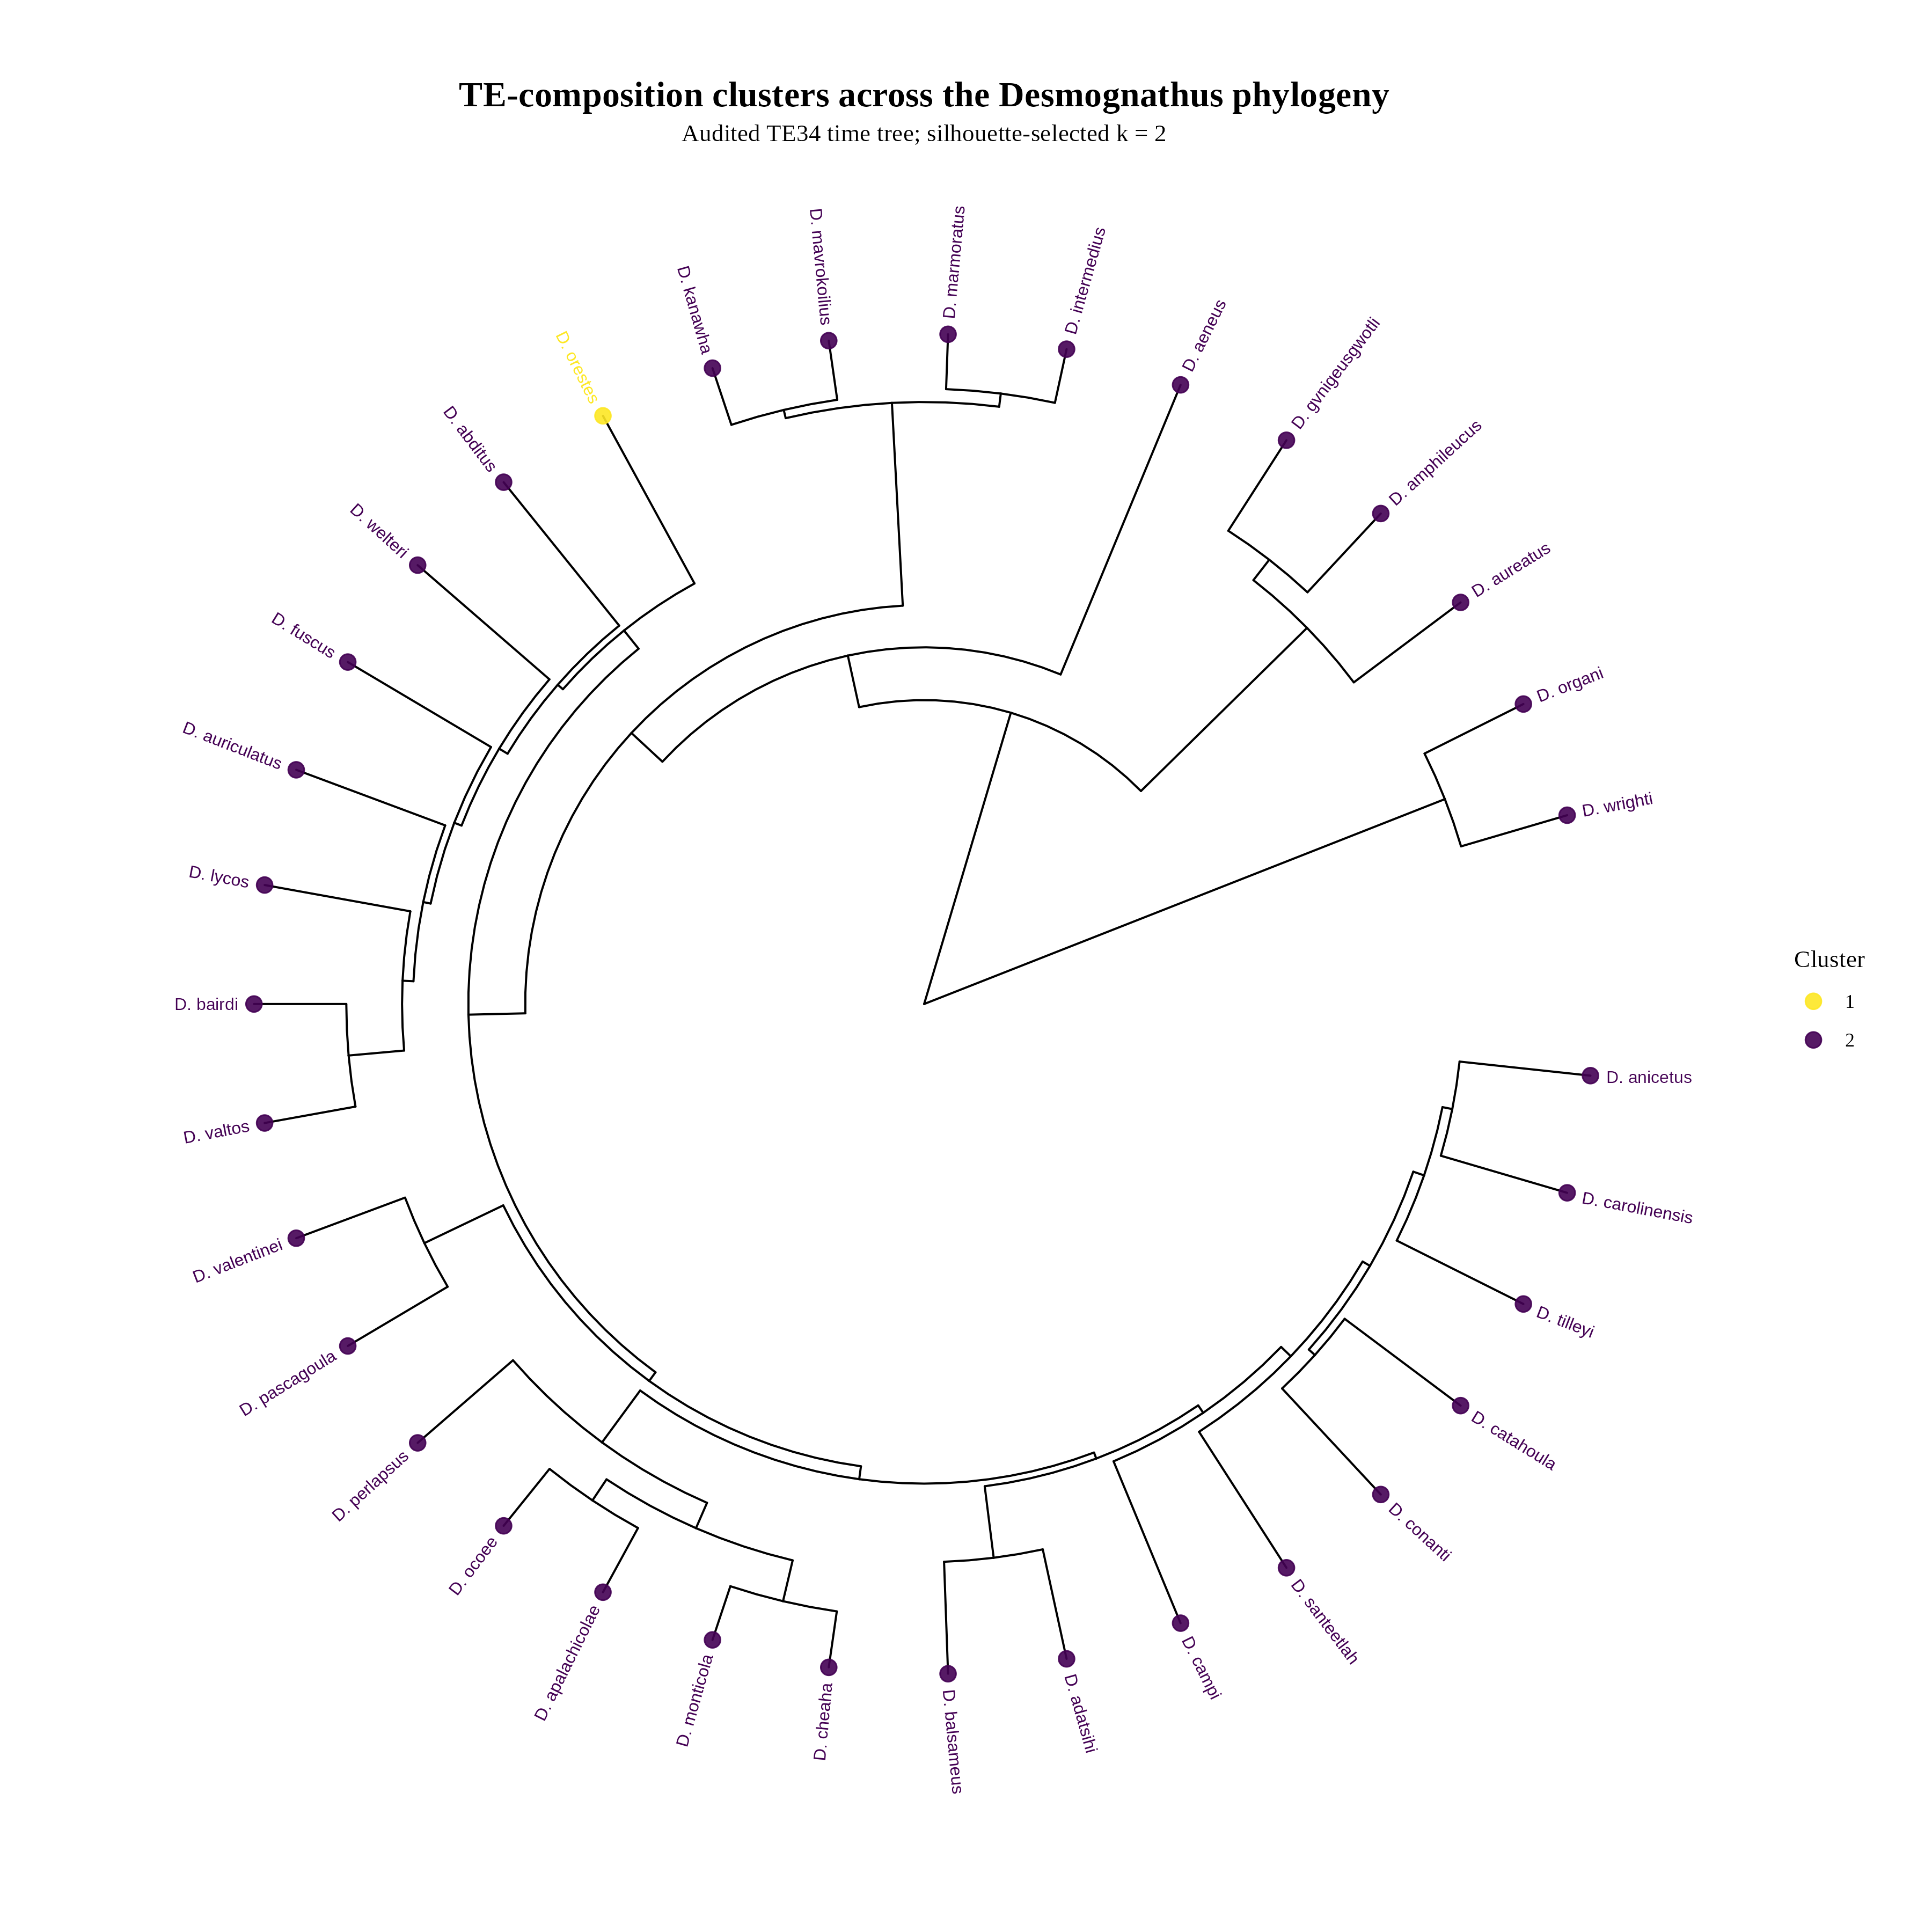

In [10]:
cluster_metrics = read_csv("results/data/research_review/te_pca_cluster_metrics_te34_v1.csv")
display(cluster_metrics)
cluster_sizes = scores.groupby("cluster", as_index=False).agg(
    n_species=("species", "size"),
    species=("species", lambda values: ", ".join(sorted(values))),
)
display(cluster_sizes)
if cluster_sizes.n_species.min() == 1:
    singleton = cluster_sizes.loc[cluster_sizes.n_species == 1, "species"].iloc[0]
    display(Markdown(
        f"**Current-data result:** maximum silhouette selects a singleton `{singleton}` "
        "outlier versus the remaining species. Treat this as outlier structure, not "
        "evidence for two broad biological TE-composition groups."
    ))
show_figure("results/figures/research_review/te_pca_elbow_te34_v1.png")
show_figure("results/figures/research_review/te_pca_silhouette_te34_v1.png")
show_figure("results/figures/research_review/te_pca_clusters_te34_v1.png")
show_figure("results/figures/research_review/te_pca_clusters_phylogeny_te34_v1.png")

## Interpretation and review boundary

- These are current TE34 results regenerated with historical R code/style.
- The PCA feature contract is explicit: Chapaev and Dada are retained; Ginger
  is excluded. Historical 35-species prevalence and current TE34 prevalence are
  reported separately.
- PCA clusters are descriptive. Elbow and silhouette diagnostics must be shown
  beside any selected `k`; the selected partition is not a discovered taxonomy.
- On the current raw-proportion superfamily PCA, maximum silhouette separates
  *D. orestes* as a singleton from the other 33 species. That is an outlier
  diagnostic, not support for two broadly replicated clades. Scaled raw-proportion
  PCA also gives rare categories equal variance, so compositional/phylogenetic PCA
  remains necessary sensitivity analysis.
- Composition is closed and unresolved mass is explicit. Corrected CLR and
  phylogenetic-PCA results remain sensitivity analyses, not replacements for this
  requested historical visual layer.
- Historical presentation rasters are visual references only and are deliberately
  not displayed as current results in this notebook.